<a href="https://colab.research.google.com/github/DavidALutz/bird-vocalization-networks/blob/main/BirdNetworkAnalysis_9_30_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Bird Vocalization Network Analysis
# September 28, 2026
# David Lutz and Ava Bixby, Colby-Sawyer College
#
# Analysis of temporal relationships among annotated bird
# vocalizations across northeastern U.S. national parks.
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/Bioacoustics_Project")

print(PROJECT_DIR.exists())

True


In [ ]:
# ============================================================
# 2. Define Project Paths
# ============================================================

from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/Bioacoustics_Project")

DATA_DIR = PROJECT_DIR / "data"
ANNOTATION_DIR = DATA_DIR / "annotations"
METADATA_DIR = DATA_DIR / "metadata"

print("Project directory:", PROJECT_DIR)
print("Annotation directory:", ANNOTATION_DIR)
print("Metadata directory:", METADATA_DIR)

print("\nDirectories found:")
print("Project:", PROJECT_DIR.exists())
print("Annotations:", ANNOTATION_DIR.exists())
print("Metadata:", METADATA_DIR.exists())

Project directory: /content/drive/MyDrive/Bioacoustics_Project
Annotation directory: /content/drive/MyDrive/Bioacoustics_Project/data/annotations
Metadata directory: /content/drive/MyDrive/Bioacoustics_Project/data/metadata

Directories found:
Project: True
Annotations: True
Metadata: True


In [ ]:
# ============================================================
# 3. Inventory Annotation Files
# ============================================================

annotation_dirs = {
    "DatasetACAD": ANNOTATION_DIR / "DatasetACAD",
    "DatasetMABI": ANNOTATION_DIR / "DatasetMABI",
    "DatasetSIMR": ANNOTATION_DIR / "DatasetSIMR"
}

total_files = 0

for dataset, dataset_dir in annotation_dirs.items():

    # Look for both CSV and TXT annotation files
    files = list(dataset_dir.rglob("*.csv")) + list(dataset_dir.rglob("*.txt"))

    print(f"{dataset}: {len(files)} annotation files")
    total_files += len(files)

print(f"\nTotal: {total_files} annotation files")

DatasetACAD: 396 annotation files
DatasetMABI: 477 annotation files
DatasetSIMR: 429 annotation files

Total: 1302 annotation files


In [ ]:
# ============================================================
# 4. Inspect Example Annotation Files
# ============================================================

import pandas as pd

for dataset, dataset_dir in annotation_dirs.items():

    files = sorted(
        list(dataset_dir.rglob("*.csv")) +
        list(dataset_dir.rglob("*.txt"))
    )

    example_file = files[0]

    print("=" * 70)
    print(f"Dataset: {dataset}")
    print(f"File: {example_file.name}")

    # sep=None asks pandas to infer the delimiter
    example = pd.read_csv(
        example_file,
        sep=None,
        engine="python"
    )

    print(f"Rows: {len(example)}")
    print(f"Columns: {len(example.columns)}")
    print("\nColumn names:")
    print(example.columns.tolist())

    print("\nFirst 3 rows:")
    display(example.head(3))

Dataset: DatasetACAD
File: 6001.41.01x.ACAD3002_20220519_050000.txt
Rows: 173
Columns: 10

Column names:
['Selection', 'View', 'Channel', 'Begin Time (s)', 'End Time (s)', 'Low Freq (Hz)', 'High Freq (Hz)', 'Begin File', 'Species', 'Background']

First 3 rows:


,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),Begin File,Species,Background
0,147,Spectrogram 1,1,349.910775,351.757508,115.446,2193.474,6001.41.01x.ACAD3002_20220519_050000.flac,AMCR,NaN
1,148,Spectrogram 1,1,324.838552,326.685285,0.000,2308.920,6001.41.01x.ACAD3002_20220519_050000.flac,AMCR,NaN
2,149,Spectrogram 1,1,340.347338,342.137538,0.000,1962.582,6001.41.01x.ACAD3002_20220519_050000.flac,AMCR,NaN


Dataset: DatasetMABI
File: 5001.01.01x.MABI1001_20220520_060000.txt
Rows: 74
Columns: 10

Column names:
['Selection', 'View', 'Channel', 'Begin Time (s)', 'End Time (s)', 'Low Freq (Hz)', 'High Freq (Hz)', 'Begin File', 'Species', 'Background']

First 3 rows:


,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),Begin File,Species,Background
0,1,Spectrogram 1,1,12.698013,15.089101,1347.400,9768.400,5001.01.01x.MABI1001_20220520_060000.flac,OVEN,NaN
1,2,Spectrogram 1,1,32.091692,34.560284,2078.028,9928.356,5001.01.01x.MABI1001_20220520_060000.flac,OVEN,NaN
2,3,Spectrogram 1,1,50.483642,52.989922,2021.100,9928.356,5001.01.01x.MABI1001_20220520_060000.flac,OVEN,NaN


Dataset: DatasetSIMR
File: 1701.15.01x.HBEFV180_20220523_050000.Table.1.selections.txt
Rows: 68
Columns: 10

Column names:
['Selection', 'View', 'Channel', 'Begin Time (s)', 'End Time (s)', 'Low Freq (Hz)', 'High Freq (Hz)', 'Begin File', 'Species', 'Background']

First 3 rows:


,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),Begin File,Species,Background
0,50,Spectrogram 1,1,235.360354,236.292610,2078.028,5079.624,1701.15.01x.HBEFV180_20220523_050000.flac,BCCH,NaN
1,49,Spectrogram 1,1,195.077591,196.037814,2078.028,5425.962,1701.15.01x.HBEFV180_20220523_050000.flac,BCCH,NaN
2,55,Spectrogram 1,1,93.974003,95.036774,2539.812,6003.192,1701.15.01x.HBEFV180_20220523_050000.flac,BCCH,NaN


In [ ]:
# ============================================================
# 5. Define Annotation Import Function
# ============================================================

def read_annotation_file(file_path, dataset_id):
    """
    Read one Raven annotation file and standardize its columns.

    Parameters
    ----------
    file_path : Path
        Path to the Raven annotation file.
    dataset_id : str
        Dataset source: DatasetACAD, DatasetMABI, or DatasetSIMR.

    Returns
    -------
    pandas.DataFrame
        Standardized annotation events.
    """

    # Read Raven table
    df = pd.read_csv(
        file_path,
        sep=None,
        engine="python"
    )

    # Rename columns
    df = df.rename(columns={
        "Selection": "selection",
        "View": "view",
        "Channel": "channel",
        "Begin Time (s)": "begin_time_s",
        "End Time (s)": "end_time_s",
        "Low Freq (Hz)": "low_freq_hz",
        "High Freq (Hz)": "high_freq_hz",
        "Begin File": "recording_filename",
        "Species": "species_code",
        "Background": "background"
    })

    # Preserve provenance
    df["dataset_ID"] = dataset_id
    df["annotation_filename"] = file_path.name

    # Derived event-level variables
    df["duration_s"] = df["end_time_s"] - df["begin_time_s"]
    df["bandwidth_hz"] = df["high_freq_hz"] - df["low_freq_hz"]

    return df

In [ ]:
# Test standardized import on one file from each dataset

test_dfs = []

for dataset, dataset_dir in annotation_dirs.items():

    files = sorted(
        list(dataset_dir.rglob("*.csv")) +
        list(dataset_dir.rglob("*.txt"))
    )

    test_df = read_annotation_file(files[0], dataset)

    test_dfs.append(test_df)

    print(
        f"{dataset}: "
        f"{len(test_df)} events, "
        f"{test_df['species_code'].nunique()} species"
    )

display(test_dfs[0].head())

DatasetACAD: 173 events, 12 species
DatasetMABI: 74 events, 6 species
DatasetSIMR: 68 events, 6 species


,selection,view,channel,begin_time_s,end_time_s,low_freq_hz,high_freq_hz,recording_filename,species_code,background,dataset_ID,annotation_filename,duration_s,bandwidth_hz
0,147,Spectrogram 1,1,349.910775,351.757508,115.446,2193.474,6001.41.01x.ACAD3002_20220519_050000.flac,AMCR,NaN,DatasetACAD,6001.41.01x.ACAD3002_20220519_050000.txt,1.846733,2078.028
1,148,Spectrogram 1,1,324.838552,326.685285,0.000,2308.920,6001.41.01x.ACAD3002_20220519_050000.flac,AMCR,NaN,DatasetACAD,6001.41.01x.ACAD3002_20220519_050000.txt,1.846733,2308.920
2,149,Spectrogram 1,1,340.347338,342.137538,0.000,1962.582,6001.41.01x.ACAD3002_20220519_050000.flac,AMCR,NaN,DatasetACAD,6001.41.01x.ACAD3002_20220519_050000.txt,1.790200,1962.582
3,151,Spectrogram 1,1,346.245576,348.224218,346.338,2078.028,6001.41.01x.ACAD3002_20220519_050000.flac,AMCR,NaN,DatasetACAD,6001.41.01x.ACAD3002_20220519_050000.txt,1.978642,1731.690
4,172,Spectrogram 1,1,365.962682,367.602128,0.000,2078.028,6001.41.01x.ACAD3002_20220519_050000.flac,AMCR,NaN,DatasetACAD,6001.41.01x.ACAD3002_20220519_050000.txt,1.639446,2078.028


In [ ]:
# ============================================================
# 6. Build Master Event Table
# ============================================================

all_events = []

for dataset, dataset_dir in annotation_dirs.items():

    files = sorted(
        list(dataset_dir.rglob("*.csv")) +
        list(dataset_dir.rglob("*.txt"))
    )

    print(f"Reading {dataset}: {len(files)} files")

    for file_path in files:
        df = read_annotation_file(file_path, dataset)
        all_events.append(df)

# Combine all annotation files into one DataFrame
events = pd.concat(all_events, ignore_index=True)

print("\nImport complete!")
print(f"Total annotation events: {len(events):,}")
print(f"Total annotation files: {events['annotation_filename'].nunique():,}")
print(f"Total recording files: {events['recording_filename'].nunique():,}")
print(f"Total species codes: {events['species_code'].nunique():,}")

Reading DatasetACAD: 396 files
Reading DatasetMABI: 477 files
Reading DatasetSIMR: 429 files

Import complete!
Total annotation events: 184,207
Total annotation files: 1,295
Total recording files: 1,295
Total species codes: 104


/tmp/ipykernel_1167/394205986.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  events = pd.concat(all_events, ignore_index=True)


In [ ]:
# ============================================================
# 7. Initial Dataset Audit
# ============================================================

dataset_summary = (
    events
    .groupby("dataset_ID")
    .agg(
        annotation_files=("annotation_filename", "nunique"),
        recordings=("recording_filename", "nunique"),
        events=("selection", "size"),
        species=("species_code", "nunique")
    )
)

display(dataset_summary)

print("\nMissing values:")
display(events.isna().sum())

print("\nEvent duration summary:")
display(events["duration_s"].describe())

print("\nFrequency bandwidth summary:")
display(events["bandwidth_hz"].describe())

,annotation_files,recordings,events,species
dataset_ID,,,,
DatasetACAD,395,395,43091,67
DatasetMABI,477,477,95205,85
DatasetSIMR,423,423,45911,84



Missing values:


,0
selection,0
view,0
channel,0
begin_time_s,0
end_time_s,0
low_freq_hz,0
high_freq_hz,0
recording_filename,0
species_code,0
background,178317



Event duration summary:


,duration_s
count,184207.000000
mean,3.297960
std,10.390955
min,0.000000
25%,1.149497
50%,1.562500
75%,2.138613
max,598.991835



Frequency bandwidth summary:


,bandwidth_hz
count,184207.000000
mean,4465.948843
std,1781.301249
min,0.000000
25%,3232.488000
50%,4178.937000
75%,5447.300000
max,16000.000000


In [ ]:
# ============================================================
# 8. Annotation QC
# ============================================================

# ------------------------------------------------------------
# A. Identify annotation files with zero events
# ------------------------------------------------------------

all_annotation_files = []

for dataset, dataset_dir in annotation_dirs.items():
    files = (
        list(dataset_dir.rglob("*.csv")) +
        list(dataset_dir.rglob("*.txt"))
    )

    for file_path in files:
        all_annotation_files.append({
            "dataset_ID": dataset,
            "annotation_filename": file_path.name
        })

file_inventory = pd.DataFrame(all_annotation_files)

files_with_events = (
    events[["dataset_ID", "annotation_filename"]]
    .drop_duplicates()
)

empty_files = (
    file_inventory
    .merge(
        files_with_events,
        on=["dataset_ID", "annotation_filename"],
        how="left",
        indicator=True
    )
    .query("_merge == 'left_only'")
    .drop(columns="_merge")
)

print("Annotation files containing zero events:")
display(empty_files)

print(f"Total empty annotation files: {len(empty_files)}")


# ------------------------------------------------------------
# B. Check unusual event durations
# ------------------------------------------------------------

print("\nZero-duration events:")
print((events["duration_s"] == 0).sum())

print("\nEvents longer than 10 seconds:")
print((events["duration_s"] > 10).sum())

print("\nEvents longer than 60 seconds:")
print((events["duration_s"] > 60).sum())

print("\nLongest 20 events:")
display(
    events.nlargest(20, "duration_s")[
        [
            "dataset_ID",
            "annotation_filename",
            "selection",
            "species_code",
            "begin_time_s",
            "end_time_s",
            "duration_s",
            "low_freq_hz",
            "high_freq_hz",
            "background"
        ]
    ]
)


# ------------------------------------------------------------
# C. Check unusual frequency annotations
# ------------------------------------------------------------

print("\nZero-bandwidth events:")
print((events["bandwidth_hz"] == 0).sum())

print("\nFull-spectrum (0–16000 Hz) events:")
print(
    (
        (events["low_freq_hz"] == 0) &
        (events["high_freq_hz"] == 16000)
    ).sum()
)


# ------------------------------------------------------------
# D. Species codes associated with long events
# ------------------------------------------------------------

print("\nSpecies associated with events > 10 seconds:")

display(
    events.loc[events["duration_s"] > 10, "species_code"]
    .value_counts()
    .head(30)
)

Annotation files containing zero events:


,dataset_ID,annotation_filename
70,DatasetACAD,6531.30.01x.ACAD4004_20230627_050000.txt
876,DatasetSIMR,1704.27.01x.HBEFV108_20220523_060001.Table.1.s...
959,DatasetSIMR,2250.02.01x.KAWW5207_20220620_070001.Table.1.s...
1017,DatasetSIMR,2311.15.01x.KAWW5208_20220722_070000.Table.1.s...
1091,DatasetSIMR,2386.27.01x.KAWW5104_20220720_070001.Table.1.s...
1210,DatasetSIMR,2520.25.01x.HBEFV346_20230618_090001.Table.1.s...
1274,DatasetSIMR,2584.47.01x.HBEFV340_20230607_080001.Table.1.s...


Total empty annotation files: 7

Zero-duration events:
1

Events longer than 10 seconds:
6463

Events longer than 60 seconds:
195

Longest 20 events:


,dataset_ID,annotation_filename,selection,species_code,begin_time_s,end_time_s,duration_s,low_freq_hz,high_freq_hz,background
174559,DatasetSIMR,2525.29.01x.HBEFV308_20230523_050000.Table.1.s...,109,REVI,0.772613,599.764447,598.991835,1729.7,5621.6,NaN
163687,DatasetSIMR,2431.01.01x.KAWW5209_20230612_051312.Table.1.s...,1,REVI,0.991263,599.495937,598.504673,640.0,6054.1,NaN
172943,DatasetSIMR,2514.20.01x.KAWW5005_20230616_060000.Table.1.s...,1,REVI,1.384408,599.260753,597.876345,1225.2,4828.8,NaN
158038,DatasetSIMR,2368.20.01x.MABI1101_20220616_050000.Table.1.s...,111,REVI,2.036290,598.991936,596.955646,1600.0,5546.7,NaN
169261,DatasetSIMR,2481.08.01x.HBEFV009_20230523_090001.Table.1.s...,28,BHVI,6.636423,599.798356,593.161933,2255.0,4939.6,NaN
167216,DatasetSIMR,2465.02.01x.HBEFV340_20230625_070000.Table.1.s...,3,REVI,12.869621,599.059140,586.189519,1225.2,5045.0,NaN
156493,DatasetSIMR,2353.14.01x.MABI1010_20220607_080001.Table.1.s...,8,REVI,0.403226,581.270165,580.866939,1511.1,5600.0,1.0
156463,DatasetSIMR,2352.57.01x.MABI1009_20220607_070001.Table.1.s...,1,RBNU,1.250000,572.318553,571.068553,1619.0,3747.7,1.0
169891,DatasetSIMR,2487.10.01x.HBEFV335_20230717_090001.Table.1.s...,2,REVI,0.285618,529.166650,528.881032,1932.9,4402.7,1.0
158750,DatasetSIMR,2373.44.01x.MABI1106_20220616_070001.Table.1.s...,90,REVI,93.286274,599.596774,506.310500,1706.7,4160.0,NaN



Zero-bandwidth events:
3

Full-spectrum (0–16000 Hz) events:
14

Species associated with events > 10 seconds:


,count
species_code,
REVI,5117
BHVI,610
EACH,97
AMCR,80
UNMA,74
????,59
RBNU,53
AMRO,48
BLJA,37


In [ ]:
# ============================================================
# 9. Examine Annotation Duration Patterns
# ============================================================

# Duration categories
events["duration_class"] = pd.cut(
    events["duration_s"],
    bins=[-0.001, 2, 5, 10, 30, 60, 300, float("inf")],
    labels=[
        "0-2 s",
        "2-5 s",
        "5-10 s",
        "10-30 s",
        "30-60 s",
        "1-5 min",
        ">5 min"
    ]
)

# Overall distribution
duration_table = (
    events["duration_class"]
    .value_counts(sort=False)
    .to_frame("events")
)

duration_table["percent"] = (
    duration_table["events"] / len(events) * 100
)

print("Overall duration distribution:")
display(duration_table)


# Duration patterns by dataset
print("\nDuration distribution by dataset:")

display(
    pd.crosstab(
        events["dataset_ID"],
        events["duration_class"],
        normalize="index"
    ).mul(100).round(2)
)


# Species with the longest typical annotations
species_duration = (
    events.groupby("species_code")
    .agg(
        n_events=("species_code", "size"),
        median_duration_s=("duration_s", "median"),
        mean_duration_s=("duration_s", "mean"),
        max_duration_s=("duration_s", "max"),
        n_over_10s=("duration_s", lambda x: (x > 10).sum()),
        n_over_60s=("duration_s", lambda x: (x > 60).sum())
    )
    .sort_values("n_over_10s", ascending=False)
)

display(species_duration.head(25))

Overall duration distribution:


,events,percent
duration_class,,
0-2 s,130517,70.853442
2-5 s,43255,23.481735
5-10 s,3972,2.156270
10-30 s,1886,1.023848
30-60 s,4382,2.378846
1-5 min,176,0.095545
>5 min,19,0.010314



Duration distribution by dataset:


duration_class,0-2 s,2-5 s,5-10 s,10-30 s,30-60 s,1-5 min,>5 min
dataset_ID,,,,,,,
DatasetACAD,78.56,16.14,2.85,0.93,1.51,0.01,0.00
DatasetMABI,67.57,26.92,1.61,0.83,3.05,0.02,0.00
DatasetSIMR,70.44,23.24,2.64,1.51,1.80,0.33,0.04


,n_events,median_duration_s,mean_duration_s,max_duration_s,n_over_10s,n_over_60s
species_code,,,,,,
REVI,6724,50.610840,38.627706,598.991835,5117,160
BHVI,1885,2.176506,13.139246,593.161933,610,12
EACH,313,3.448491,15.132017,189.511240,97,10
AMCR,4837,1.916872,2.534027,119.220405,80,2
UNMA,263,2.657034,12.898453,112.826851,74,2
????,588,1.281534,4.697979,121.349348,59,4
RBNU,1601,2.410962,3.592277,571.068553,53,1
AMRO,5353,1.997486,2.361497,59.246200,48,0
BLJA,3774,0.983367,1.528304,54.356127,37,0


In [ ]:
# ============================================================
# 10. Inspect Metadata Files
# ============================================================

for item in sorted(METADATA_DIR.iterdir()):
    print(f"{'[DIR]' if item.is_dir() else '[FILE]'} {item.name}")

[FILE] data_dictionary.csv
[FILE] recording_metadata.csv
[FILE] site_metadata.csv
[FILE] species_metadata.csv


In [ ]:
# Preview metadata files

for item in sorted(METADATA_DIR.iterdir()):

    if item.suffix.lower() in [".csv", ".txt"]:

        print("\n" + "=" * 70)
        print(item.name)

        try:
            temp = pd.read_csv(
                item,
                sep=None,
                engine="python"
            )

            print(f"Rows: {len(temp):,}")
            print(f"Columns: {len(temp.columns)}")
            print("Column names:")
            print(temp.columns.tolist())

            display(temp.head(3))

        except Exception as e:
            print(f"Could not read: {e}")


data_dictionary.csv
Could not read: 'utf-8' codec can't decode byte 0x93 in position 4247: invalid start byte

recording_metadata.csv
Rows: 1,302
Columns: 12
Column names:
['Dataset_ID', 'ItemID', 'Recording_FileName', 'Annotation_FileName', 'Year', 'Date', 'Time', 'SiteID', 'ParkID', 'Round1_Annotator', 'Round2_Annotator', 'Round3_Annotator']


,Dataset_ID,ItemID,Recording_FileName,Annotation_FileName,Year,Date,Time,SiteID,ParkID,Round1_Annotator,Round2_Annotator,Round3_Annotator
0,DatasetACAD,6001,6001.41.01x.ACAD3002_20220519_050000.flac,6001.41.01x.ACAD3002_20220519_050000.txt,2022,20220519,541,ACAD3002,ACAD,A13_Amateur,A02_Experienced,A01_Experienced
1,DatasetACAD,6021,6021.41.01x.ACAD3005_20220519_050000.flac,6021.41.01x.ACAD3005_20220519_050000.txt,2022,20220519,541,ACAD3005,ACAD,A13_Amateur,A02_Experienced,A01_Experienced
2,DatasetACAD,6022,6022.41.01x.ACAD3005_20220520_050000.flac,6022.41.01x.ACAD3005_20220520_050000.txt,2022,20220520,541,ACAD3005,ACAD,A13_Amateur,A02_Experienced,A01_Experienced



site_metadata.csv
Rows: 104
Columns: 7
Column names:
['ParkID', 'SiteID', 'Latitude', 'Longitude', 'N_Rec_10min', 'Recorded_in_2022', 'Recorded_in_2023']


,ParkID,SiteID,Latitude,Longitude,N_Rec_10min,Recorded_in_2022,Recorded_in_2023
0,ACAD,ACAD3101,44.350905,-68.292071,24,yes,yes
1,ACAD,ACAD3201,44.403570,-68.248136,24,yes,yes
2,ACAD,ACAD3401,44.282847,-68.345701,24,yes,yes



species_metadata.csv
Rows: 101
Columns: 8
Column names:
['AOU_Code', 'IsBird', 'Common_Name', 'Scientific_Name', 'Family', 'N_DatasetACAD', 'N_DatasetMABI', 'N_DatasetSIMR']


,AOU_Code,IsBird,Common_Name,Scientific_Name,Family,N_DatasetACAD,N_DatasetMABI,N_DatasetSIMR
0,????,Maybe,Unknown,NaN,NaN,99,325,164
1,EACH,No,Eastern Chipmunk,Tamias striatus,NaN,9,170,134
2,RESQ,No,Red Squirrel,Tamiasciurus hudsonicus,NaN,59,153,187


In [ ]:
# ============================================================
# 11. Build Master Recording and Event Tables
# ============================================================

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

recordings = pd.read_csv(
    METADATA_DIR / "recording_metadata.csv"
)

sites = pd.read_csv(
    METADATA_DIR / "site_metadata.csv"
)

species = pd.read_csv(
    METADATA_DIR / "species_metadata.csv"
)


# ------------------------------------------------------------
# Standardize recording metadata column names
# ------------------------------------------------------------

recordings = recordings.rename(columns={
    "Dataset_ID": "dataset_ID",
    "ItemID": "itemID",
    "Recording_FileName": "recording_filename",
    "Annotation_FileName": "annotation_filename",
    "Year": "year",
    "Date": "date",
    "Time": "recording_time",
    "SiteID": "siteID",
    "ParkID": "park_ID",
    "Round1_Annotator": "round1_annotator",
    "Round2_Annotator": "round2_annotator",
    "Round3_Annotator": "round3_annotator"
})

sites = sites.rename(columns={
    "ParkID": "park_ID",
    "SiteID": "siteID",
    "Latitude": "latitude",
    "Longitude": "longitude",
    "N_Rec_10min": "n_recordings_10min",
    "Recorded_in_2022": "recorded_in_2022",
    "Recorded_in_2023": "recorded_in_2023"
})

species = species.rename(columns={
    "AOU_Code": "species_code",
    "IsBird": "is_bird",
    "Common_Name": "common_name",
    "Scientific_Name": "scientific_name",
    "Family": "family"
})


# ------------------------------------------------------------
# Add site information to recording table
# ------------------------------------------------------------

recordings = recordings.merge(
    sites,
    on=["park_ID", "siteID"],
    how="left",
    validate="many_to_one"
)

print(f"Master recording table: {len(recordings):,} recordings")
print(f"Sites: {recordings['siteID'].nunique()}")
print(f"Parks: {recordings['park_ID'].nunique()}")

Master recording table: 1,302 recordings
Sites: 104
Parks: 4


In [ ]:
# ------------------------------------------------------------
# Add recording and species metadata to event table
# ------------------------------------------------------------

events = events.merge(
    recordings[
        [
            "dataset_ID",
            "itemID",
            "recording_filename",
            "year",
            "date",
            "recording_time",
            "siteID",
            "park_ID",
            "latitude",
            "longitude",
            "round1_annotator",
            "round2_annotator",
            "round3_annotator"
        ]
    ],
    on=["dataset_ID", "recording_filename"],
    how="left",
    validate="many_to_one"
)

events = events.merge(
    species[
        [
            "species_code",
            "is_bird",
            "common_name",
            "scientific_name",
            "family"
        ]
    ],
    on="species_code",
    how="left",
    validate="many_to_one"
)

print(f"Events: {len(events):,}")
print(f"Recordings represented: {events['itemID'].nunique():,}")
print(f"Sites represented: {events['siteID'].nunique()}")
print(f"Parks represented: {events['park_ID'].nunique()}")

print("\nBird classification:")
display(events["is_bird"].value_counts(dropna=False))

Events: 184,207
Recordings represented: 1,287
Sites represented: 104
Parks represented: 4

Bird classification:


,count
is_bird,
Yes,182634
No,982
Maybe,588
NaN,3


In [ ]:
# ============================================================
# 12. Species Metadata Match QC
# ============================================================

unmatched_codes = (
    events.loc[events["common_name"].isna(), "species_code"]
    .value_counts()
    .to_frame("n_events")
)

print("Annotation codes not matched to species metadata:")
display(unmatched_codes)

print(
    f"\nEvents without species metadata: "
    f"{events['common_name'].isna().sum():,}"
)

Annotation codes not matched to species metadata:


,n_events
species_code,
HETH,1
WOTH,1
HAWO,1



Events without species metadata: 3


In [ ]:
# ============================================================
# 13. Recording Metadata Match QC
# ============================================================

# Events that failed to match recording metadata
unmatched_recordings = (
    events.loc[events["itemID"].isna()]
    .groupby(
        ["dataset_ID", "recording_filename", "annotation_filename"],
        dropna=False
    )
    .size()
    .reset_index(name="n_events")
)

print(f"Event-bearing annotation files without recording metadata: "
      f"{len(unmatched_recordings)}")

print(f"Events affected: {unmatched_recordings['n_events'].sum():,}")

display(unmatched_recordings)

Event-bearing annotation files without recording metadata: 8
Events affected: 809


,dataset_ID,recording_filename,annotation_filename,n_events
0,DatasetSIMR,2207.01.01x.ACAD3606_20220602_090001.flac,2207.01.01x.ACAD3606_20220602_090001.Table.1.s...,127
1,DatasetSIMR,2252.37.01x.KAWW5104_20220621_090001.flac,2252.37.01x.KAWW5104_20220621_090001.Table.1.s...,1
2,DatasetSIMR,2285.01.01x.HBEFV007_20220715_060000.flac,2285.01.01x.HBEFV007_20220715_060000.Table.1.s...,205
3,DatasetSIMR,2485.01.01x.ACAD3201_20230528_082133.flac,2485.01.01x.ACAD3201_20230528_082133.Table.1.s...,53
4,DatasetSIMR,2506.15.01x.HBEFV111_20230622_060000.flac,2506.15.01x.HBEFV111_20230622_060000.Table.1.s...,42
5,DatasetSIMR,2560.46.01x.KAWW5402_20230527_060000.flac,2560.46.01x.KAWW5402_20230527_060000.Table.1.s...,98
6,DatasetSIMR,2570.50.01x.ACAD3201_20230613_070000.flac,2570.50.01x.ACAD3201_20230613_070000.Table.1.s...,131
7,DatasetSIMR,2610.00.01x.HBEFV007_20230624_060000.flac,2610.00.01x.HBEFV007_20230624_060000.Table.1.s...,152


In [ ]:
# ============================================================
# 14. Species Code Match QC
# ============================================================

annotation_codes = set(events["species_code"].dropna().unique())
metadata_codes = set(species["species_code"].dropna().unique())

codes_missing_from_metadata = sorted(
    annotation_codes - metadata_codes
)

codes_not_observed = sorted(
    metadata_codes - annotation_codes
)

print("Codes in annotations but absent from species metadata:")
print(codes_missing_from_metadata)

print("\nNumber of annotation codes:", len(annotation_codes))
print("Number of metadata codes:", len(metadata_codes))
print("Number of unmatched annotation codes:",
      len(codes_missing_from_metadata))

print("\nMetadata codes not observed in annotations:")
print(codes_not_observed)

Codes in annotations but absent from species metadata:
[' HETH', 'HAWO ', 'WOTH ']

Number of annotation codes: 104
Number of metadata codes: 101
Number of unmatched annotation codes: 3

Metadata codes not observed in annotations:
[]


In [ ]:
# ============================================================
# 15. Diagnose SIMR Recording Filename Mismatches
# ============================================================

# Extract apparent ItemID from unmatched recording filenames
unmatched_recordings["filename_itemID"] = (
    unmatched_recordings["recording_filename"]
    .str.extract(r"^(\d+)")
    .astype(int)
)

problem_itemIDs = unmatched_recordings["filename_itemID"].tolist()

metadata_matches = (
    recordings.loc[
        recordings["itemID"].isin(problem_itemIDs),
        [
            "dataset_ID",
            "itemID",
            "recording_filename",
            "annotation_filename",
            "siteID",
            "park_ID",
            "date",
            "recording_time"
        ]
    ]
    .sort_values("itemID")
)

display(metadata_matches)

print(f"Problem ItemIDs found in metadata: "
      f"{metadata_matches['itemID'].nunique()} of "
      f"{len(problem_itemIDs)}")

,dataset_ID,itemID,recording_filename,annotation_filename,siteID,park_ID,date,recording_time
585,DatasetSIMR,2207,2207.10.01x.ACAD3606_20220602_090001.flac,2207.10.01x.ACAD3606_20220602_090001.Table.1.s...,ACAD3606,ACAD,20220602,910
622,DatasetSIMR,2252,2252.35.01x.KAWW5104_20220621_090001.flac,2252.35.01x.KAWW5104_20220621_090001.Table.1.s...,KAWW5104,KAWW,20220621,935
652,DatasetSIMR,2285,2285.00.01x.HBEFV007_20220715_060000.flac,2285.00.01x.HBEFV007_20220715_060000.Table.1.s...,HBEFV007,HBEF,20220715,600
762,DatasetSIMR,2485,2485.10.01x.ACAD3201_20230528_082133.flac,2485.10.01x.ACAD3201_20230528_082133.Table.1.s...,ACAD3201,ACAD,20230528,832
776,DatasetSIMR,2506,2506.18.01x.HBEFV111_20230622_060000.flac,2506.18.01x.HBEFV111_20230622_060000.Table.1.s...,HBEFV111,HBEF,20230622,618
803,DatasetSIMR,2560,2560.40.01x.KAWW5402_20230527_060000.flac,2560.40.01x.KAWW5402_20230527_060000.Table.1.s...,KAWW5402,KAWW,20230527,640
485,DatasetSIMR,2570,2570.42.01x.ACAD3201_20230613_070000.flac,2570.42.01x.ACAD3201_20230613_070000.Table.1.s...,ACAD3201,ACAD,20230613,742
543,DatasetSIMR,2610,2610.58.01x.HBEFV007_20230624_050000.flac,2610.58.01x.HBEFV007_20230624_050000.Table.1.s...,HBEFV007,HBEF,20230624,558


Problem ItemIDs found in metadata: 8 of 8


In [ ]:
# ============================================================
# 16. Clean Species Codes
# ============================================================

# Remove accidental leading/trailing whitespace
events["species_code"] = events["species_code"].str.strip()
species["species_code"] = species["species_code"].str.strip()

print("Unique annotation codes after cleaning:",
      events["species_code"].nunique())

print(
    "Codes still absent from species metadata:",
    sorted(
        set(events["species_code"].unique()) -
        set(species["species_code"].unique())
    )
)

Unique annotation codes after cleaning: 101
Codes still absent from species metadata: []


In [ ]:
# ============================================================
# 17. Assign Authoritative Recording ID
# ============================================================

events["itemID_from_annotation"] = (
    events["annotation_filename"]
    .str.extract(r"^(\d+)")[0]
    .astype(int)
)

print("Unique ItemIDs represented by events:",
      events["itemID_from_annotation"].nunique())

print("ItemIDs not found in recording metadata:")

missing_itemIDs = sorted(
    set(events["itemID_from_annotation"]) -
    set(recordings["itemID"])
)

print(missing_itemIDs)

# we can say: The dataset contains 1,302 recording units identified by ItemID; 1,295 contain ≥1 annotated event and 7 contain zero annotated events.

Unique ItemIDs represented by events: 1295
ItemIDs not found in recording metadata:
[]


In [ ]:
# ============================================================
# 18. Build Clean Master Event Table
# ============================================================

# Start from the imported annotation events
master_events = events.copy()

# ------------------------------------------------------------
# Clean identifiers
# ------------------------------------------------------------

master_events["species_code"] = (
    master_events["species_code"]
    .astype(str)
    .str.strip()
)

# Preserve the filename recorded inside the Raven annotation
master_events = master_events.rename(columns={
    "recording_filename": "recording_filename_annotation"
})

# Use ItemID parsed from annotation filename as recording key
master_events["itemID"] = (
    master_events["annotation_filename"]
    .str.extract(r"^(\d+)")[0]
    .astype(int)
)

# ------------------------------------------------------------
# Remove metadata columns from our earlier exploratory merge
# so that we can rebuild them cleanly
# ------------------------------------------------------------

metadata_columns = [
    "year",
    "date",
    "recording_time",
    "siteID",
    "park_ID",
    "latitude",
    "longitude",
    "round1_annotator",
    "round2_annotator",
    "round3_annotator",
    "is_bird",
    "common_name",
    "scientific_name",
    "family",
    "itemID_from_annotation"
]

master_events = master_events.drop(
    columns=[c for c in metadata_columns if c in master_events.columns],
    errors="ignore"
)

# ------------------------------------------------------------
# Add authoritative recording metadata using ItemID
# ------------------------------------------------------------

recording_lookup = recordings[
    [
        "itemID",
        "dataset_ID",
        "recording_filename",
        "year",
        "date",
        "recording_time",
        "siteID",
        "park_ID",
        "latitude",
        "longitude",
        "round1_annotator",
        "round2_annotator",
        "round3_annotator"
    ]
].rename(columns={
    "recording_filename": "recording_filename_metadata"
})

# dataset_ID already exists in annotation data, so use ItemID alone
# and verify agreement afterward
master_events = master_events.merge(
    recording_lookup,
    on="itemID",
    how="left",
    validate="many_to_one",
    suffixes=("_annotation_source", "_metadata_source")
)

# Verify dataset provenance agrees
dataset_disagreement = (
    master_events["dataset_ID_annotation_source"] !=
    master_events["dataset_ID_metadata_source"]
).sum()

print("Dataset-ID disagreements:", dataset_disagreement)

# Keep one authoritative dataset ID
master_events["dataset_ID"] = (
    master_events["dataset_ID_metadata_source"]
)

master_events = master_events.drop(columns=[
    "dataset_ID_annotation_source",
    "dataset_ID_metadata_source"
])

# ------------------------------------------------------------
# Add species metadata
# ------------------------------------------------------------

master_events = master_events.merge(
    species[
        [
            "species_code",
            "is_bird",
            "common_name",
            "scientific_name",
            "family"
        ]
    ],
    on="species_code",
    how="left",
    validate="many_to_one"
)

print(f"Master events: {len(master_events):,}")
print(f"Recordings with events: {master_events['itemID'].nunique():,}")
print(f"Species/annotation codes: {master_events['species_code'].nunique()}")
print(f"Missing recording metadata: {master_events['siteID'].isna().sum():,}")
print(f"Missing species metadata: {master_events['is_bird'].isna().sum():,}")

Dataset-ID disagreements: 0
Master events: 184,207
Recordings with events: 1,295
Species/annotation codes: 101
Missing recording metadata: 0
Missing species metadata: 0


In [ ]:
# ============================================================
# 19. Create Event IDs and Sort Chronologically
# ============================================================

master_events = master_events.sort_values(
    ["itemID", "begin_time_s", "end_time_s", "selection"]
).reset_index(drop=True)

# Unique event identifier
master_events["event_id"] = (
    master_events["itemID"].astype(str)
    + "_"
    + master_events["selection"].astype(str)
)

print("Total events:", f"{len(master_events):,}")
print("Unique event IDs:", f"{master_events['event_id'].nunique():,}")

duplicate_event_ids = (
    master_events["event_id"]
    .duplicated()
    .sum()
)

print("Duplicate event IDs:", duplicate_event_ids)

Total events: 184,207
Unique event IDs: 184,086
Duplicate event IDs: 121


In [ ]:
# ============================================================
# 20. Add Event Counts to Recording Table
# ============================================================

event_counts = (
    master_events
    .groupby("itemID")
    .size()
    .rename("n_events")
)

master_recordings = recordings.copy()

master_recordings = master_recordings.merge(
    event_counts,
    on="itemID",
    how="left"
)

master_recordings["n_events"] = (
    master_recordings["n_events"]
    .fillna(0)
    .astype(int)
)

master_recordings["has_events"] = (
    master_recordings["n_events"] > 0
)

print(f"Total recordings: {len(master_recordings):,}")
print(f"Recordings with events: {master_recordings['has_events'].sum():,}")
print(f"Zero-event recordings: {(~master_recordings['has_events']).sum():,}")

display(
    master_recordings.loc[
        ~master_recordings["has_events"],
        [
            "itemID",
            "dataset_ID",
            "park_ID",
            "siteID",
            "date",
            "recording_time",
            "n_events"
        ]
    ]
)

Total recordings: 1,302
Recordings with events: 1,295
Zero-event recordings: 7


,itemID,dataset_ID,park_ID,siteID,date,recording_time,n_events
61,6531,DatasetACAD,ACAD,ACAD4004,20230627,530,0
429,2520,DatasetSIMR,HBEF,HBEFV346,20230618,925,0
537,2584,DatasetSIMR,HBEF,HBEFV340,20230607,847,0
547,1704,DatasetSIMR,HBEF,HBEFV108,20220523,627,0
620,2250,DatasetSIMR,KAWW,KAWW5207,20220620,702,0
674,2311,DatasetSIMR,KAWW,KAWW5208,20220722,815,0
781,2386,DatasetSIMR,KAWW,KAWW5104,20220720,0,0


In [ ]:
# ============================================================
# 21. Investigate Repeated Raven Selection Numbers
# ============================================================

duplicate_mask = master_events.duplicated(
    subset=["itemID", "selection"],
    keep=False
)

repeated_selections = (
    master_events.loc[duplicate_mask]
    .sort_values(
        ["itemID", "selection", "begin_time_s"]
    )
)

print(
    "Events involved in repeated ItemID + Selection combinations:",
    len(repeated_selections)
)

print(
    "Unique repeated ItemID + Selection combinations:",
    repeated_selections[
        ["itemID", "selection"]
    ].drop_duplicates().shape[0]
)

print(
    "Recordings affected:",
    repeated_selections["itemID"].nunique()
)

display(
    repeated_selections[
        [
            "itemID",
            "dataset_ID",
            "park_ID",
            "siteID",
            "annotation_filename",
            "selection",
            "species_code",
            "begin_time_s",
            "end_time_s",
            "low_freq_hz",
            "high_freq_hz"
        ]
    ].head(50)
)

Events involved in repeated ItemID + Selection combinations: 242
Unique repeated ItemID + Selection combinations: 121
Recordings affected: 1


,itemID,dataset_ID,park_ID,siteID,annotation_filename,selection,species_code,begin_time_s,end_time_s,low_freq_hz,high_freq_hz
142605,6017,DatasetACAD,ACAD,ACAD3002,6017.30.01x.ACAD3002_20220625_050000.txt,1,BTNW,9.902633,11.042708,3060.265,5935.06
142606,6017,DatasetACAD,ACAD,ACAD3002,6017.30.01x.ACAD3002_20220625_050000.txt,1,BTNW,9.902633,11.042708,3060.265,5935.06
142771,6017,DatasetACAD,ACAD,ACAD3002,6017.30.01x.ACAD3002_20220625_050000.txt,2,BTNW,306.955395,307.954138,3616.677,6642.90
142772,6017,DatasetACAD,ACAD,ACAD3002,6017.30.01x.ACAD3002_20220625_050000.txt,2,BTNW,306.955395,307.954138,3616.677,6642.90
142785,6017,DatasetACAD,ACAD,ACAD3002,6017.30.01x.ACAD3002_20220625_050000.txt,3,BTNW,331.697845,333.130005,3321.500,6954.30
142786,6017,DatasetACAD,ACAD,ACAD3002,6017.30.01x.ACAD3002_20220625_050000.txt,3,BTNW,331.697845,333.130005,3321.500,6954.30
142781,6017,DatasetACAD,ACAD,ACAD3002,6017.30.01x.ACAD3002_20220625_050000.txt,4,BTNW,323.802120,325.092949,3529.000,6746.70
142782,6017,DatasetACAD,ACAD,ACAD3002,6017.30.01x.ACAD3002_20220625_050000.txt,4,BTNW,323.802120,325.092949,3529.000,6746.70
142819,6017,DatasetACAD,ACAD,ACAD3002,6017.30.01x.ACAD3002_20220625_050000.txt,5,BRCR,465.748841,466.182258,6435.300,8096.00
142820,6017,DatasetACAD,ACAD,ACAD3002,6017.30.01x.ACAD3002_20220625_050000.txt,5,BRCR,465.748841,466.182258,6435.300,8096.00


In [ ]:
# ============================================================
# 22. Check for Exact Duplicate Events
# ============================================================

event_definition = [
    "itemID",
    "selection",
    "species_code",
    "begin_time_s",
    "end_time_s",
    "low_freq_hz",
    "high_freq_hz"
]

exact_duplicate_mask = master_events.duplicated(
    subset=event_definition,
    keep=False
)

exact_duplicates = (
    master_events.loc[exact_duplicate_mask]
    .sort_values(
        ["itemID", "selection", "begin_time_s"]
    )
)

print(
    "Rows involved in exact duplicate annotations:",
    len(exact_duplicates)
)

print(
    "Extra rows beyond unique annotations:",
    master_events.duplicated(
        subset=event_definition
    ).sum()
)

display(
    exact_duplicates[
        event_definition + ["annotation_filename"]
    ].head(50)
)

Rows involved in exact duplicate annotations: 242
Extra rows beyond unique annotations: 121


,itemID,selection,species_code,begin_time_s,end_time_s,low_freq_hz,high_freq_hz,annotation_filename
142605,6017,1,BTNW,9.902633,11.042708,3060.265,5935.06,6017.30.01x.ACAD3002_20220625_050000.txt
142606,6017,1,BTNW,9.902633,11.042708,3060.265,5935.06,6017.30.01x.ACAD3002_20220625_050000.txt
142771,6017,2,BTNW,306.955395,307.954138,3616.677,6642.90,6017.30.01x.ACAD3002_20220625_050000.txt
142772,6017,2,BTNW,306.955395,307.954138,3616.677,6642.90,6017.30.01x.ACAD3002_20220625_050000.txt
142785,6017,3,BTNW,331.697845,333.130005,3321.500,6954.30,6017.30.01x.ACAD3002_20220625_050000.txt
142786,6017,3,BTNW,331.697845,333.130005,3321.500,6954.30,6017.30.01x.ACAD3002_20220625_050000.txt
142781,6017,4,BTNW,323.802120,325.092949,3529.000,6746.70,6017.30.01x.ACAD3002_20220625_050000.txt
142782,6017,4,BTNW,323.802120,325.092949,3529.000,6746.70,6017.30.01x.ACAD3002_20220625_050000.txt
142819,6017,5,BRCR,465.748841,466.182258,6435.300,8096.00,6017.30.01x.ACAD3002_20220625_050000.txt
142820,6017,5,BRCR,465.748841,466.182258,6435.300,8096.00,6017.30.01x.ACAD3002_20220625_050000.txt


In [ ]:
# ============================================================
# 23. Remove Exact Duplicate Annotation Events
# ============================================================

n_before = len(master_events)

# Remove exact duplicate annotations while retaining
# the first occurrence of each event
master_events = (
    master_events
    .drop_duplicates(
        subset=[
            "itemID",
            "selection",
            "species_code",
            "begin_time_s",
            "end_time_s",
            "low_freq_hz",
            "high_freq_hz"
        ],
        keep="first"
    )
    .copy()
)

n_after = len(master_events)

print(f"Events before duplicate removal: {n_before:,}")
print(f"Events after duplicate removal:  {n_after:,}")
print(f"Duplicate rows removed:          {n_before - n_after:,}")

Events before duplicate removal: 184,207
Events after duplicate removal:  184,086
Duplicate rows removed:          121


In [ ]:
# ============================================================
# 24. Create Final Event IDs
# ============================================================

# Sort events chronologically within each recording
master_events = (
    master_events
    .sort_values(
        ["itemID", "begin_time_s", "end_time_s", "selection"]
    )
    .reset_index(drop=True)
)

# Sequential event number within each recording
master_events["event_number"] = (
    master_events.groupby("itemID").cumcount() + 1
)

# Globally unique event identifier
master_events["event_id"] = (
    master_events["itemID"].astype(str)
    + "_E"
    + master_events["event_number"].astype(str).str.zfill(4)
)

print(f"Total events:     {len(master_events):,}")
print(f"Unique event IDs: {master_events['event_id'].nunique():,}")
print(
    "Duplicate event IDs:",
    master_events["event_id"].duplicated().sum()
)

Total events:     184,086
Unique event IDs: 184,086
Duplicate event IDs: 0


In [ ]:
# ============================================================
# 25. Refresh Recording Event Counts
# ============================================================

event_counts = (
    master_events
    .groupby("itemID")
    .size()
    .rename("n_events")
)

master_recordings = (
    recordings
    .drop(columns=["n_events", "has_events"], errors="ignore")
    .merge(
        event_counts,
        on="itemID",
        how="left"
    )
)

master_recordings["n_events"] = (
    master_recordings["n_events"]
    .fillna(0)
    .astype(int)
)

master_recordings["has_events"] = (
    master_recordings["n_events"] > 0
)

print(f"Recordings:             {len(master_recordings):,}")
print(f"Recordings with events: {master_recordings['has_events'].sum():,}")
print(f"Zero-event recordings:  {(~master_recordings['has_events']).sum():,}")
print(f"Total events:           {master_recordings['n_events'].sum():,}")

Recordings:             1,302
Recordings with events: 1,295
Zero-event recordings:  7
Total events:           184,086


In [ ]:
# ============================================================
# 26. Save Canonical Cleaned Tables
# ============================================================

DERIVED_DIR = DATA_DIR / "derived"
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

events_path = DERIVED_DIR / "master_events.csv"
recordings_path = DERIVED_DIR / "master_recordings.csv"

master_events.to_csv(events_path, index=False)
master_recordings.to_csv(recordings_path, index=False)

print(f"Saved events to:\n  {events_path}")
print(f"\nSaved recordings to:\n  {recordings_path}")

print("\nFinal dataset:")
print(f"  Recordings:             {len(master_recordings):,}")
print(f"  Recordings with events: {master_recordings['has_events'].sum():,}")
print(f"  Zero-event recordings:  {(~master_recordings['has_events']).sum():,}")
print(f"  Unique events:          {len(master_events):,}")
print(f"  Annotation codes:       {master_events['species_code'].nunique():,}")

Saved events to:
  /content/drive/MyDrive/Bioacoustics_Project/data/derived/master_events.csv

Saved recordings to:
  /content/drive/MyDrive/Bioacoustics_Project/data/derived/master_recordings.csv

Final dataset:
  Recordings:             1,302
  Recordings with events: 1,295
  Zero-event recordings:  7
  Unique events:          184,086
  Annotation codes:       101


### Data integration and quality-control summary

The three annotation datasets were integrated with recording-, site-, and
species-level metadata using `ItemID` as the authoritative recording identifier.

The complete dataset contains:

- **1,302 recordings**
- **1,295 recordings with ≥1 annotated event**
- **7 recordings with zero annotated events**
- **184,086 unique annotated vocalization events**
- **101 standardized annotation codes**

Quality-control checks identified:

1. **Eight DatasetSIMR filename discrepancies.** The recording filename stored
   in the Raven annotation did not exactly match the filename in the recording
   metadata. All eight recordings were unambiguously reconciled using `ItemID`.

2. **Three species-code formatting errors.** `HETH`, `HAWO`, and `WOTH`
   occurred with leading or trailing whitespace. Species codes were standardized
   by removing leading/trailing whitespace.

3. **121 exact duplicate annotations in one recording (ItemID 6017).**
   These records were identical in selection number, species identity, time
   bounds, and frequency bounds. One copy of each duplicate was retained,
   reducing the event table from 184,207 to 184,086 unique events.

The original annotation files and metadata remain unchanged. All corrections
were applied only to the derived analysis tables.

Each event has a globally unique `event_id` and retains its original Raven
selection number and source-file information for provenance.

In [ ]:
# ============================================================
# Step 27 — Annotation Duration by Species
# ============================================================

species_duration = (
    master_events
    .groupby("species_code")
    .agg(
        n_events=("event_id", "size"),
        median_duration_s=("duration_s", "median"),
        mean_duration_s=("duration_s", "mean"),
        max_duration_s=("duration_s", "max"),
        n_over_10s=("duration_s", lambda x: (x > 10).sum()),
        n_over_60s=("duration_s", lambda x: (x > 60).sum())
    )
    .sort_values("n_over_10s", ascending=False)
)

display(species_duration.head(30))

,n_events,median_duration_s,mean_duration_s,max_duration_s,n_over_10s,n_over_60s
species_code,,,,,,
REVI,6724,50.610840,38.627706,598.991835,5117,160
BHVI,1885,2.176506,13.139246,593.161933,610,12
EACH,313,3.448491,15.132017,189.511240,97,10
AMCR,4837,1.916872,2.534027,119.220405,80,2
UNMA,263,2.657034,12.898453,112.826851,74,2
????,588,1.281534,4.697979,121.349348,59,4
RBNU,1601,2.410962,3.592277,571.068553,53,1
AMRO,5353,1.997486,2.361497,59.246200,48,0
BLJA,3771,0.989321,1.528937,54.356127,37,0


In [ ]:
# ============================================================
# Step 28 — REVI Duration by Dataset
# ============================================================

revi_by_dataset = (
    master_events[master_events["species_code"] == "REVI"]
    .groupby("dataset_ID")
    .agg(
        n_events=("event_id", "size"),
        median_duration_s=("duration_s", "median"),
        mean_duration_s=("duration_s", "mean"),
        max_duration_s=("duration_s", "max"),
        n_over_10s=("duration_s", lambda x: (x > 10).sum()),
        n_over_60s=("duration_s", lambda x: (x > 60).sum())
    )
    .sort_values("n_events", ascending=False)
)

display(revi_by_dataset)

,n_events,median_duration_s,mean_duration_s,max_duration_s,n_over_10s,n_over_60s
dataset_ID,,,,,,
DatasetMABI,3546,57.208462,44.650337,118.442390,3080,16
DatasetSIMR,2108,18.372309,33.031567,598.991835,1339,144
DatasetACAD,1070,25.006268,29.693512,59.971702,698,0


In [ ]:
# ============================================================
# Step 29 — REVI Duration by Recording
# ============================================================

revi_recording_duration = (
    master_events[master_events["species_code"] == "REVI"]
    .groupby(["dataset_ID", "itemID"])
    .agg(
        n_revi_events=("event_id", "size"),
        median_duration_s=("duration_s", "median"),
        mean_duration_s=("duration_s", "mean"),
        max_duration_s=("duration_s", "max"),
        n_over_10s=("duration_s", lambda x: (x > 10).sum()),
        n_over_60s=("duration_s", lambda x: (x > 60).sum())
    )
    .sort_values(
        ["n_over_60s", "max_duration_s", "n_over_10s"],
        ascending=False
    )
)

display(revi_recording_duration.head(30))

n_revi_events  median_duration_s  mean_duration_s  \
dataset_ID  itemID                                                      
DatasetSIMR 2344               11          60.045479        54.312197   
            2345               10          60.011362        60.012279   
            2355                9          41.990832        64.282965   
            2312                6          85.663375        92.937819   
            2371               10          35.126085        53.144325   
            2568               10          36.845707        41.520310   
            2338                6         113.730981        96.269808   
            2360                5         104.260091        97.379916   
            2369                8          46.210775        66.577419   
            2308                5          62.632516        91.405589   
            2362               19          10.319061        22.345481   
            2422                7          24.390677        43.427296   
            2265                3          75.331165       185.070301   
            2366                2         294.088701       294.088701   
            2350                3         108.004013       161.904604   
            2201               11           4.164571        52.431742   
            2377                4          54.705936        92.269532   
            2564                9          15.047103        48.190389   
            2299                8          30.405761        71.502183   
            2365                7          28.528221        57.742480   
            2384               16           2.737122        25.799378   
            2315                3         161.315934       136.214153   
            2376                4          52.153420        78.399588   
            2437               15          18.064303        34.122841   
            2340               10          58.487721        58.808006   
            1734               10          21.444712        40.258066   
            2367                3          94.909255        80.184232   
            2488                4          55.771158        62.302574   
            2253               10          16.792473        38.033352   
            2527               17          17.173137        28.799454   

                    max_duration_s  n_over_10s  n_over_60s  
dataset_ID  itemID                                          
DatasetSIMR 2344         60.386646          10           7  
            2345         60.113712          10           6  
            2355        221.774976           9           4  
            2312        220.153033           6           4  
            2371        118.497959           9           4  
            2568        117.948096           7           4  
            2338        117.185850           6           4  
            2360        244.545674           5           3  
            2369        178.652557           7           3  
            2308        177.370751           5           3  
            2362         94.426441          10           3  
            2422         79.703148           7           3  
            2265        459.562597           3           2  
            2366        404.826599           2           2  
            2350        318.201634           3           2  
            2201        295.951317           4           2  
            2377        259.042075           2           2  
            2564        257.391573           6           2  
            2299        243.858915           6           2  
            2365        230.737911           6           2  
            2384        227.301062           6           2  
            2315        208.438930           3           2  
            2376        201.923424           3           2  
            2437        190.042737          12           2  
            2340        167.979999           9           2  
            1734        163.063021  

In [ ]:
# ============================================================
# Step 30 — Inspect REVI annotations in ItemID 2344
# ============================================================

revi_2344 = (
    master_events[
        (master_events["itemID"] == 2344) &
        (master_events["species_code"] == "REVI")
    ]
    .sort_values("begin_time_s")
    [
        [
            "event_id",
            "begin_time_s",
            "end_time_s",
            "duration_s",
            "low_freq_hz",
            "high_freq_hz",
            "selection"
        ]
    ]
)

display(revi_2344)

,event_id,begin_time_s,end_time_s,duration_s,low_freq_hz,high_freq_hz,selection
17101,2344_E0001,0.034117,59.977245,59.943128,1636.400,3818.200,84
17124,2344_E0024,59.977245,119.954490,59.977245,1636.400,3454.500,85
17157,2344_E0057,119.613323,179.999969,60.386646,1818.200,4727.300,86
17181,2344_E0081,179.877177,239.956772,60.079595,2181.800,4181.800,87
17203,2344_E0103,239.956772,300.002251,60.045479,1454.500,4363.600,88
17215,2344_E0115,299.899900,359.993170,60.093270,1636.400,3818.200,89
17223,2344_E0123,359.890820,419.936299,60.045479,1636.400,4000.000,90
17239,2344_E0139,419.868065,480.015894,60.147829,2363.600,4000.000,91
17253,2344_E0153,479.981777,539.988638,60.006861,1636.400,4000.000,92
17270,2344_E0170,541.268090,588.055581,46.787491,942.809,4148.360,195


In [ ]:
# ============================================================
# Step 31 — REVI annotations near 60 seconds
# ============================================================

revi_long = master_events[
    (master_events["species_code"] == "REVI") &
    (master_events["duration_s"] > 55) &
    (master_events["duration_s"] < 65)
].copy()

print(f"REVI annotations between 55 and 65 seconds: {len(revi_long):,}")

display(
    revi_long[
        [
            "dataset_ID",
            "itemID",
            "begin_time_s",
            "end_time_s",
            "duration_s",
            "selection"
        ]
    ]
    .sort_values(["dataset_ID", "itemID", "begin_time_s"])
    .head(50)
)

REVI annotations between 55 and 65 seconds: 2,949


,dataset_ID,itemID,begin_time_s,end_time_s,duration_s,selection
144555,DatasetACAD,6505,2.336682,59.792682,57.456000,73
144579,DatasetACAD,6505,60.090828,118.168688,58.077859,81
144596,DatasetACAD,6505,119.022738,176.817934,57.795196,83
144607,DatasetACAD,6505,177.276256,235.589668,58.313412,85
144610,DatasetACAD,6505,235.916080,295.068059,59.151979,91
144618,DatasetACAD,6505,296.072863,353.999969,57.927106,99
144624,DatasetACAD,6505,354.495979,412.583260,58.087281,107
144630,DatasetACAD,6505,412.806030,471.599969,58.793939,109
144631,DatasetACAD,6505,471.690828,530.399969,58.709140,111
144636,DatasetACAD,6505,531.084421,589.371865,58.287444,113


In [ ]:
# ============================================================
# Step 32 — How common are ~60-second annotations by species?
# ============================================================

near_60_by_species = (
    master_events
    .assign(
        near_60s=lambda df: (
            (df["duration_s"] >= 55) &
            (df["duration_s"] <= 65)
        )
    )
    .groupby("species_code")
    .agg(
        n_events=("event_id", "size"),
        n_near_60s=("near_60s", "sum")
    )
)

near_60_by_species["pct_near_60s"] = (
    100 * near_60_by_species["n_near_60s"] /
    near_60_by_species["n_events"]
)

display(
    near_60_by_species
    .sort_values("n_near_60s", ascending=False)
    .head(30)
)

,n_events,n_near_60s,pct_near_60s
species_code,,,
REVI,6724,2949,43.857823
BHVI,1885,127,6.737401
UNMA,263,27,10.266160
EACH,313,19,6.070288
AMRO,5353,10,0.186811
GCKI,2194,8,0.364631
????,588,8,1.360544
RBGR,1622,8,0.493218
OVEN,31138,7,0.022481


In [ ]:
# ============================================================
# Step 33 — Are REVI annotations aligned to 60-second boundaries?
# ============================================================

revi_60 = master_events[
    (master_events["species_code"] == "REVI") &
    (master_events["duration_s"] >= 55) &
    (master_events["duration_s"] <= 65)
].copy()

# Distance of each start time from the nearest 60-second boundary
revi_60["start_mod_60"] = revi_60["begin_time_s"] % 60
revi_60["start_distance_to_boundary_s"] = (
    revi_60["start_mod_60"].apply(lambda x: min(x, 60 - x))
)

# Same calculation for the end time
revi_60["end_mod_60"] = revi_60["end_time_s"] % 60
revi_60["end_distance_to_boundary_s"] = (
    revi_60["end_mod_60"].apply(lambda x: min(x, 60 - x))
)

display(
    revi_60[
        [
            "dataset_ID",
            "itemID",
            "begin_time_s",
            "end_time_s",
            "duration_s",
            "start_distance_to_boundary_s",
            "end_distance_to_boundary_s"
        ]
    ]
    .sort_values("start_distance_to_boundary_s")
    .head(30)
)

,dataset_ID,itemID,begin_time_s,end_time_s,duration_s,start_distance_to_boundary_s,end_distance_to_boundary_s
181146,DatasetACAD,6838,0.000000,57.889417,57.889417,0.000000,2.110583
112620,DatasetMABI,5361,0.000000,59.999969,59.999969,0.000000,0.000031
132170,DatasetMABI,5446,540.000000,599.623116,59.623116,0.000000,0.376884
107954,DatasetMABI,5336,0.000000,59.858637,59.858637,0.000000,0.141363
106449,DatasetMABI,5326,0.000000,59.161401,59.161401,0.000000,0.838599
66999,DatasetMABI,5117,0.000000,59.265045,59.265045,0.000000,0.734955
81733,DatasetMABI,5195,0.000000,59.971702,59.971702,0.000000,0.028298
50674,DatasetMABI,5026,0.000000,57.804618,57.804618,0.000000,2.195382
146368,DatasetACAD,6519,0.000000,59.952858,59.952858,0.000000,0.047142
114900,DatasetMABI,5373,0.000000,59.999969,59.999969,0.000000,0.000031


In [ ]:
# ============================================================
# Step 34 — Quantify REVI 60-second boundary alignment
# ============================================================

start_aligned = (
    revi_60["start_distance_to_boundary_s"] <= 0.5
).sum()

end_aligned = (
    revi_60["end_distance_to_boundary_s"] <= 0.5
).sum()

n_total = len(revi_60)

print(f"Total REVI annotations (55–65 s): {n_total:,}")
print(
    f"Starts within 0.5 s of a 60-s boundary: "
    f"{start_aligned:,} ({100 * start_aligned / n_total:.2f}%)"
)
print(
    f"Ends within 0.5 s of a 60-s boundary: "
    f"{end_aligned:,} ({100 * end_aligned / n_total:.2f}%)"
)

Total REVI annotations (55–65 s): 2,949
Starts within 0.5 s of a 60-s boundary: 455 (15.43%)
Ends within 0.5 s of a 60-s boundary: 204 (6.92%)


In [ ]:
# ============================================================
# Step 35 — Locate recordings folder
# ============================================================

from pathlib import Path

recording_dirs = [
    p for p in PROJECT_DIR.rglob("*")
    if p.is_dir() and "recording" in p.name.lower()
]

print("Recording-related folders found:")
for p in recording_dirs:
    print(p)

Recording-related folders found:
/content/drive/MyDrive/Bioacoustics_Project/data/recordings


In [ ]:
# ============================================================
# Step 36 — Inspect recordings folder
# ============================================================

RECORDINGS_DIR = DATA_DIR / "recordings"

items = list(RECORDINGS_DIR.iterdir())

print(f"Items in recordings folder: {len(items)}")

for item in sorted(items)[:30]:
    print(item.name)

Items in recordings folder: 3
DatasetACAD_Recordings.zip
DatasetMABI_Recordings.zip
DatasetSIMR_Recordings.zip


In [ ]:
# ============================================================
# Step 37 — Extract recording ZIP files
# ============================================================

import zipfile

recording_zips = {
    "DatasetACAD": RECORDINGS_DIR / "DatasetACAD_Recordings.zip",
    "DatasetMABI": RECORDINGS_DIR / "DatasetMABI_Recordings.zip",
    "DatasetSIMR": RECORDINGS_DIR / "DatasetSIMR_Recordings.zip",
}

for dataset_id, zip_path in recording_zips.items():
    output_dir = RECORDINGS_DIR / dataset_id
    output_dir.mkdir(exist_ok=True)

    print(f"\nExtracting {dataset_id}...")

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(output_dir)

    print(f"Done: {output_dir}")


Extracting DatasetACAD...
Done: /content/drive/MyDrive/Bioacoustics_Project/data/recordings/DatasetACAD

Extracting DatasetMABI...
Done: /content/drive/MyDrive/Bioacoustics_Project/data/recordings/DatasetMABI

Extracting DatasetSIMR...
Done: /content/drive/MyDrive/Bioacoustics_Project/data/recordings/DatasetSIMR


In [ ]:
# ============================================================
# Step 38 — Verify extracted recording files
# ============================================================

for dataset_id in ["DatasetACAD", "DatasetMABI", "DatasetSIMR"]:
    dataset_dir = RECORDINGS_DIR / dataset_id

    all_files = [
        p for p in dataset_dir.rglob("*")
        if p.is_file()
    ]

    wav_files = [
        p for p in all_files
        if p.suffix.lower() == ".wav"
    ]

    print(f"\n{dataset_id}")
    print(f"  Total files: {len(all_files):,}")
    print(f"  WAV files:   {len(wav_files):,}")

    if all_files:
        print("  Example:")
        print(f"    {all_files[0]}")


DatasetACAD
  Total files: 396
  WAV files:   0
  Example:
    /content/drive/MyDrive/Bioacoustics_Project/data/recordings/DatasetACAD/DatasetACAD_Recordings/6001.41.01x.ACAD3002_20220519_050000.flac

DatasetMABI
  Total files: 477
  WAV files:   0
  Example:
    /content/drive/MyDrive/Bioacoustics_Project/data/recordings/DatasetMABI/DatasetMABI_Recordings/5001.01.01x.MABI1001_20220520_060000.flac

DatasetSIMR
  Total files: 429
  WAV files:   0
  Example:
    /content/drive/MyDrive/Bioacoustics_Project/data/recordings/DatasetSIMR/DatasetSIMR_Recordings/1701.15.01x.HBEFV180_20220523_050000.flac


In [ ]:
# ============================================================
# Step 39 — Locate ItemID 2344 recording
# ============================================================

matches_2344 = list(
    RECORDINGS_DIR.rglob("*2344*.flac")
)

print(f"Matching FLAC files: {len(matches_2344)}")

for path in matches_2344:
    print(path)

Matching FLAC files: 1
/content/drive/MyDrive/Bioacoustics_Project/data/recordings/DatasetSIMR/DatasetSIMR_Recordings/2344.12.01x.MABI1001_20220607_050000.flac


In [ ]:
# ============================================================
# Step 40 — Inspect ItemID 2344 audio properties
# ============================================================

import soundfile as sf

recording_2344 = matches_2344[0]

info = sf.info(recording_2344)

print("File:", recording_2344.name)
print("Duration:", round(info.duration, 3), "seconds")
print("Sample rate:", info.samplerate, "Hz")
print("Channels:", info.channels)
print("Subtype:", info.subtype)
print("Format:", info.format)

File: 2344.12.01x.MABI1001_20220607_050000.flac
Duration: 600.0 seconds
Sample rate: 32000 Hz
Channels: 1
Subtype: PCM_16
Format: FLAC


/tmp/ipykernel_1167/2686161829.py:19: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  librosa.amplitude_to_db(


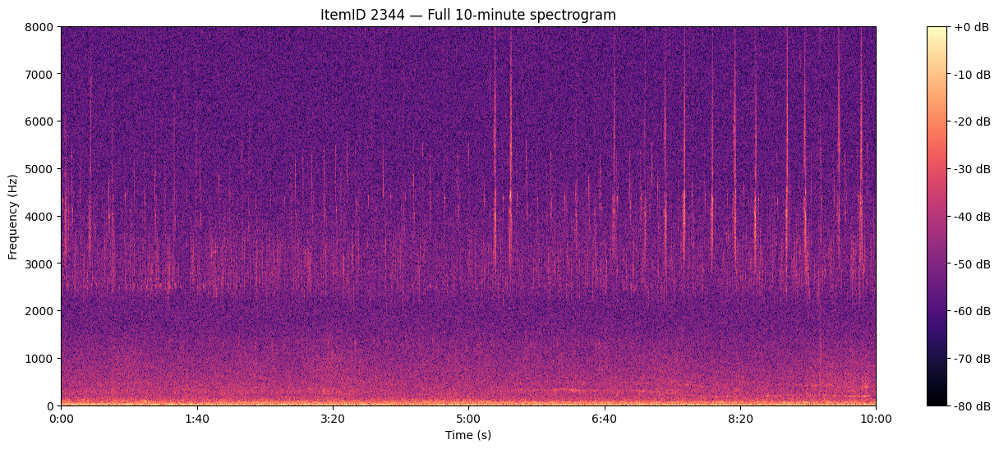

In [ ]:
# ============================================================
# Step 41 — Full-recording spectrogram for ItemID 2344
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

audio, sr = librosa.load(
    recording_2344,
    sr=None,
    mono=True
)

plt.figure(figsize=(16, 6))

librosa.display.specshow(
    librosa.amplitude_to_db(
        librosa.stft(audio, n_fft=2048, hop_length=512),
        ref=np.max
    ),
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="hz"
)

plt.ylim(0, 8000)
plt.colorbar(format="%+2.0f dB")
plt.title("ItemID 2344 — Full 10-minute spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()

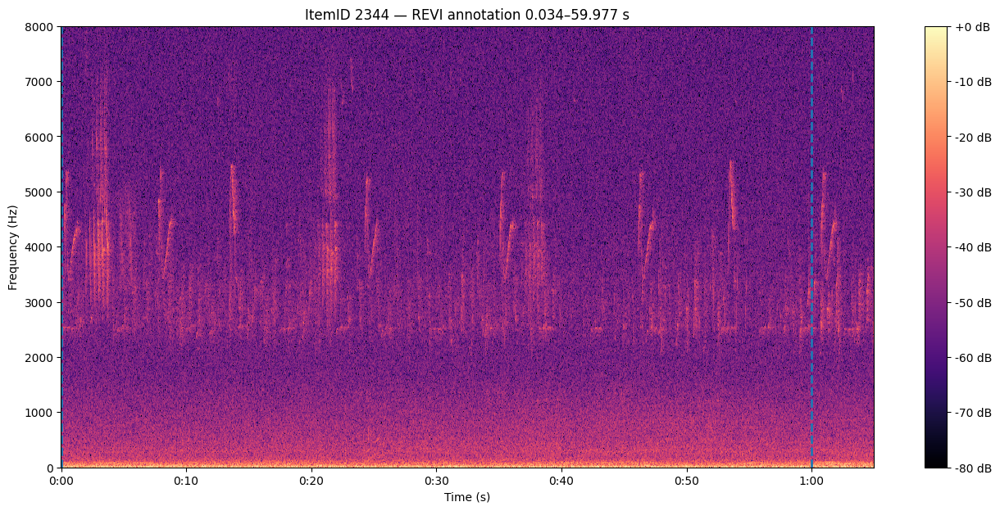

In [ ]:
# ============================================================
# Step 42 — Zoom into the first REVI annotation in ItemID 2344
# ============================================================

import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

start_s = 0.0
end_s = 65.0

audio_segment = audio[
    int(start_s * sr):int(end_s * sr)
]

S_segment = librosa.stft(
    audio_segment,
    n_fft=2048,
    hop_length=512
)

plt.figure(figsize=(16, 7))

librosa.display.specshow(
    librosa.amplitude_to_db(
        np.abs(S_segment),
        ref=np.max
    ),
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="hz"
)

plt.ylim(0, 8000)

# REVI annotation boundaries
plt.axvline(0.034, linestyle="--", linewidth=2)
plt.axvline(59.977, linestyle="--", linewidth=2)

plt.colorbar(format="%+2.0f dB")
plt.title("ItemID 2344 — REVI annotation 0.034–59.977 s")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()

In [ ]:
# ============================================================
# Step 43 — Listen to first 10 seconds of REVI annotation
# ============================================================

from IPython.display import Audio, display

start_s = 0
end_s = 10

audio_10s = audio[
    int(start_s * sr):int(end_s * sr)
]

display(Audio(audio_10s, rate=sr))

In [ ]:
# ============================================================
# Step 44 — Find a long BHVI annotation
# ============================================================

bhvi_long = (
    master_events[
        (master_events["species_code"] == "BHVI") &
        (master_events["duration_s"] > 30)
    ]
    .sort_values("duration_s", ascending=False)
)

display(
    bhvi_long[
        [
            "event_id",
            "itemID",
            "begin_time_s",
            "end_time_s",
            "duration_s",
            "selection"
        ]
    ].head(10)
)

,event_id,itemID,begin_time_s,end_time_s,duration_s,selection
30944,2481_E0002,2481,6.636423,599.798356,593.161933,28
14183,2286_E0001,2286,0.876256,494.373595,493.497339,88
32266,2494_E0013,2494,433.935002,596.831741,162.896739,11
19137,2365_E0034,2365,97.661273,226.705611,129.044337,9
21575,2383_E0117,2383,474.135876,597.635052,123.499176,114
20766,2376_E0002,2376,0.518216,122.160299,121.642083,30
17648,2347_E0097,2347,477.184949,597.432797,120.247848,27
8847,2234_E0095,2234,353.629145,470.167809,116.538663,91
17611,2347_E0060,2347,361.321516,471.559646,110.238130,22
16360,2332_E0026,2332,119.232028,198.414047,79.182019,38


In [ ]:
# ============================================================
# Step 45 — Locate BHVI ItemID 2481 recording
# ============================================================

recording_2481 = list(
    (RECORDINGS_DIR / "DatasetSIMR").rglob("*2481*.flac")
)

recording_2481

[PosixPath('/content/drive/MyDrive/Bioacoustics_Project/data/recordings/DatasetSIMR/DatasetSIMR_Recordings/2481.08.01x.HBEFV009_20230523_090001.flac')]

In [ ]:
# ============================================================
# Step 46 — Listen to first 20 seconds of BHVI annotation
# ============================================================

import soundfile as sf
from IPython.display import Audio, display

audio_bhvi, sr_bhvi = sf.read(recording_2481[0])

bhvi_20s = audio_bhvi[:int(20 * sr_bhvi)]

display(Audio(bhvi_20s, rate=sr_bhvi))

In [ ]:
# ============================================================
# Step 47 — Inspect annotations in ItemID 2481
# ============================================================

item_2481 = (
    master_events[
        master_events["itemID"].astype(str) == "2481"
    ]
    .sort_values("begin_time_s")
)

display(
    item_2481[
        [
            "event_id",
            "species_code",
            "begin_time_s",
            "end_time_s",
            "duration_s",
            "low_freq_hz",
            "high_freq_hz",
            "selection"
        ]
    ].to_string(index=False)
)

'  event_id species_code  begin_time_s  end_time_s  duration_s  low_freq_hz  high_freq_hz selection\n2481_E0001         BTNW      5.040981    5.958383    0.917402     3535.534      5568.466        34\n2481_E0002         BHVI      6.636423  599.798356  593.161933     2255.000      4939.600        28\n2481_E0003         BTNW     15.255351   16.399739    1.144388     3358.757      5126.524        35\n2481_E0004         BTNW     25.110327   26.037187    0.926860     2828.427      5745.243        36\n2481_E0005         BLJA     31.579429   33.357486    1.778057     1237.437      4154.252        38\n2481_E0006         BTNW     34.974761   36.100233    1.125472     2916.815      6010.408        37\n2481_E0007         BLJA     46.303681   48.119569    1.815888     1280.797      4162.591        32\n2481_E0008         BTNW     46.577956   48.337098    1.759142     2561.594      5763.587        33\n2481_E0009         BLJA     50.465091   52.167328    1.702236     2040.300      4832.200        29\

In [ ]:
# ============================================================
# Step 48 — Count overlapping annotation pairs
# ============================================================

events_2481 = (
    master_events[
        master_events["itemID"].astype(str) == "2481"
    ]
    .sort_values("begin_time_s")
    .reset_index(drop=True)
)

overlaps = []

for i in range(len(events_2481)):
    current = events_2481.iloc[i]

    for j in range(i + 1, len(events_2481)):
        other = events_2481.iloc[j]

        if other["begin_time_s"] >= current["end_time_s"]:
            break

        overlap_s = min(
            current["end_time_s"],
            other["end_time_s"]
        ) - max(
            current["begin_time_s"],
            other["begin_time_s"]
        )

        if overlap_s > 0:
            overlaps.append({
                "event_1": current["event_id"],
                "species_1": current["species_code"],
                "event_2": other["event_id"],
                "species_2": other["species_code"],
                "overlap_s": overlap_s
            })

overlap_df = pd.DataFrame(overlaps)

print(f"Total events: {len(events_2481)}")
print(f"Overlapping pairs: {len(overlap_df)}")

display(overlap_df.head(20))

Total events: 50
Overlapping pairs: 49


,event_1,species_1,event_2,species_2,overlap_s
0,2481_E0002,BHVI,2481_E0003,BTNW,1.144388
1,2481_E0002,BHVI,2481_E0004,BTNW,0.926860
2,2481_E0002,BHVI,2481_E0005,BLJA,1.778057
3,2481_E0002,BHVI,2481_E0006,BTNW,1.125472
4,2481_E0002,BHVI,2481_E0007,BLJA,1.815888
5,2481_E0002,BHVI,2481_E0008,BTNW,1.759142
6,2481_E0002,BHVI,2481_E0009,BLJA,1.702236
7,2481_E0002,BHVI,2481_E0010,BTNW,1.948924
8,2481_E0002,BHVI,2481_E0011,BLJA,0.870113
9,2481_E0002,BHVI,2481_E0012,BLJA,1.229508


In [ ]:
# ============================================================
# Step 49 — Do long annotations systematically overlap others?
# ============================================================

events = (
    master_events[
        ["event_id", "itemID", "species_code",
         "begin_time_s", "end_time_s", "duration_s"]
    ]
    .sort_values(["itemID", "begin_time_s"])
    .reset_index(drop=True)
)

overlap_counts = []

for item_id, group in events.groupby("itemID", sort=False):

    group = group.reset_index(drop=True)
    n_overlapping = np.zeros(len(group), dtype=int)

    for i in range(len(group)):
        for j in range(i + 1, len(group)):

            if group.loc[j, "begin_time_s"] >= group.loc[i, "end_time_s"]:
                break

            if (
                min(group.loc[i, "end_time_s"],
                    group.loc[j, "end_time_s"])
                >
                max(group.loc[i, "begin_time_s"],
                    group.loc[j, "begin_time_s"])
            ):
                n_overlapping[i] += 1
                n_overlapping[j] += 1

    temp = group[["event_id", "itemID", "species_code", "duration_s"]].copy()
    temp["n_overlapping_annotations"] = n_overlapping
    overlap_counts.append(temp)

overlap_counts = pd.concat(overlap_counts, ignore_index=True)

# Summarize by duration class
overlap_counts["duration_class"] = pd.cut(
    overlap_counts["duration_s"],
    bins=[-np.inf, 2, 5, 10, 30, 60, 300, np.inf],
    labels=[
        "0–2 s",
        "2–5 s",
        "5–10 s",
        "10–30 s",
        "30–60 s",
        "1–5 min",
        ">5 min"
    ]
)

summary = (
    overlap_counts
    .groupby("duration_class", observed=False)
    .agg(
        n_annotations=("event_id", "size"),
        n_with_overlap=(
            "n_overlapping_annotations",
            lambda x: (x > 0).sum()
        ),
        median_overlaps=(
            "n_overlapping_annotations",
            "median"
        ),
        max_overlaps=(
            "n_overlapping_annotations",
            "max"
        )
    )
)

summary["pct_with_overlap"] = (
    summary["n_with_overlap"]
    / summary["n_annotations"]
    * 100
)

display(summary)

,n_annotations,n_with_overlap,median_overlaps,max_overlaps,pct_with_overlap
duration_class,,,,,
0–2 s,130397,87329,1.0,7,66.971633
2–5 s,43254,32754,1.0,8,75.724788
5–10 s,3972,2997,2.0,13,75.453172
10–30 s,1886,1693,3.0,28,89.766702
30–60 s,4382,4231,13.0,62,96.554085
1–5 min,176,155,12.5,81,88.068182
>5 min,19,18,49.0,202,94.736842


In [ ]:
# ============================================================
# Step 50 — Recording-time coverage by annotation duration
# ============================================================

duration_bins = [
    (-np.inf, 2, "0–2 s"),
    (2, 5, "2–5 s"),
    (5, 10, "5–10 s"),
    (10, 30, "10–30 s"),
    (30, 60, "30–60 s"),
    (60, 300, "1–5 min"),
    (300, np.inf, ">5 min"),
]

coverage_rows = []

for dataset_id, group in master_events.groupby("dataset_ID"):

    total_recording_seconds = (
        master_recordings.loc[
            master_recordings["dataset_ID"] == dataset_id,
            "n_events"
        ].shape[0] * 600
    )

    for low, high, label in duration_bins:

        subset = group[
            (group["duration_s"] > low) &
            (group["duration_s"] <= high)
        ]

        coverage_rows.append({
            "dataset_ID": dataset_id,
            "duration_class": label,
            "n_annotations": len(subset),
            "total_annotated_seconds": subset["duration_s"].sum()
        })

coverage_df = pd.DataFrame(coverage_rows)

display(coverage_df)

,dataset_ID,duration_class,n_annotations,total_annotated_seconds
0,DatasetACAD,0–2 s,33732,40502.449166
1,DatasetACAD,2–5 s,6956,18776.679607
2,DatasetACAD,5–10 s,1227,8132.194654
3,DatasetACAD,10–30 s,401,6846.956260
4,DatasetACAD,30–60 s,651,34337.487150
5,DatasetACAD,1–5 min,3,274.986027
6,DatasetACAD,>5 min,0,0.000000
7,DatasetMABI,0–2 s,64327,84546.657314
8,DatasetMABI,2–5 s,25629,68174.273352
9,DatasetMABI,5–10 s,1533,10447.645574


In [ ]:
# ============================================================
# Step 51 — Long-annotation prevalence by species
# ============================================================

species_long = (
    master_events
    .groupby("species_code")
    .agg(
        n_annotations=("event_id", "size"),
        median_duration_s=("duration_s", "median"),
        n_over_10s=("duration_s", lambda x: (x > 10).sum()),
        n_over_30s=("duration_s", lambda x: (x > 30).sum()),
        n_over_60s=("duration_s", lambda x: (x > 60).sum()),
        max_duration_s=("duration_s", "max")
    )
)

species_long["pct_over_10s"] = (
    species_long["n_over_10s"]
    / species_long["n_annotations"]
    * 100
)

species_long["pct_over_30s"] = (
    species_long["n_over_30s"]
    / species_long["n_annotations"]
    * 100
)

species_long["pct_over_60s"] = (
    species_long["n_over_60s"]
    / species_long["n_annotations"]
    * 100
)

display(
    species_long
    .sort_values("pct_over_30s", ascending=False)
    .head(30)
)

,n_annotations,median_duration_s,n_over_10s,n_over_30s,n_over_60s,max_duration_s,pct_over_10s,pct_over_30s,pct_over_60s
species_code,,,,,,,,,
REVI,6724,50.610840,5117,4023,160,598.991835,76.100535,59.830458,2.379536
HERG,10,3.956596,3,2,0,59.905748,30.000000,20.000000,0.000000
EACH,313,3.448491,97,59,10,189.511240,30.990415,18.849840,3.194888
BHVI,1885,2.176506,610,313,12,593.161933,32.360743,16.604775,0.636605
UNMA,263,2.657034,74,42,2,112.826851,28.136882,15.969582,0.760456
CANG,22,2.931880,4,1,0,36.524256,18.181818,4.545455,0.000000
????,588,1.281534,59,20,4,121.349348,10.034014,3.401361,0.680272
RESQ,399,2.685300,32,11,2,197.710504,8.020050,2.756892,0.501253
CEDW,213,0.684855,4,3,1,96.121002,1.877934,1.408451,0.469484


In [ ]:
# ============================================================
# Step 52 — Duration patterns by species and dataset
# ============================================================

species_dataset_duration = (
    master_events
    .groupby(["species_code", "dataset_ID"])
    .agg(
        n_annotations=("event_id", "size"),
        median_duration_s=("duration_s", "median"),
        pct_over_10s=("duration_s", lambda x: (x > 10).mean() * 100),
        pct_over_30s=("duration_s", lambda x: (x > 30).mean() * 100),
        pct_over_60s=("duration_s", lambda x: (x > 60).mean() * 100),
        max_duration_s=("duration_s", "max")
    )
    .reset_index()
)

display(
    species_dataset_duration[
        species_dataset_duration["species_code"].isin(["REVI", "BHVI"])
    ]
    .sort_values(["species_code", "dataset_ID"])
)

,species_code,dataset_ID,n_annotations,median_duration_s,pct_over_10s,pct_over_30s,pct_over_60s,max_duration_s
28,BHVI,DatasetACAD,939,0.659547,23.748669,11.927583,0.000000,59.566552
29,BHVI,DatasetMABI,429,10.722325,51.048951,29.137529,0.233100,62.453281
30,BHVI,DatasetSIMR,517,1.625567,32.495164,14.700193,2.127660,593.161933
175,REVI,DatasetACAD,1070,25.006268,65.233645,47.196262,0.000000,59.971702
176,REVI,DatasetMABI,3546,57.208462,86.858432,75.211506,0.451213,118.442390
177,REVI,DatasetSIMR,2108,18.372309,63.519924,40.370019,6.831120,598.991835


In [ ]:
# ============================================================
# Step 53 — Select representative annotations for comparison
# ============================================================

# REVI: representative long annotation
revi_example = (
    master_events[
        (master_events["species_code"] == "REVI") &
        (master_events["duration_s"] >= 50) &
        (master_events["duration_s"] <= 65)
    ]
    .sort_values("duration_s")
    .iloc[0]
)

# BHVI: representative long annotation
bhvi_example = (
    master_events[
        (master_events["species_code"] == "BHVI") &
        (master_events["duration_s"] >= 50) &
        (master_events["duration_s"] <= 65)
    ]
    .sort_values("duration_s")
    .iloc[0]
)

# Typical short annotation:
# choose a common species with duration around 1–2 seconds
short_example = (
    master_events[
        (master_events["duration_s"] >= 1) &
        (master_events["duration_s"] <= 2) &
        (master_events["is_bird"] == "Yes")
    ]
    .sort_values("duration_s")
    .iloc[len(master_events) // 100]
)

comparison = pd.DataFrame([
    revi_example,
    bhvi_example,
    short_example
])[
    [
        "event_id",
        "itemID",
        "species_code",
        "begin_time_s",
        "end_time_s",
        "duration_s",
        "low_freq_hz",
        "high_freq_hz",
        "dataset_ID"
    ]
]

display(comparison)

,event_id,itemID,species_code,begin_time_s,end_time_s,duration_s,low_freq_hz,high_freq_hz,dataset_ID
147031,6527_E0036,6527,REVI,300.124369,350.136905,50.012537,1847.136,5656.854,DatasetACAD
17568,2347_E0017,2347,BHVI,182.774524,232.900601,50.126077,1944.544,6010.408,DatasetSIMR
175896,6799_E0116,6799,HAWO,516.464675,517.491684,1.027009,230.900,1731.700,DatasetACAD


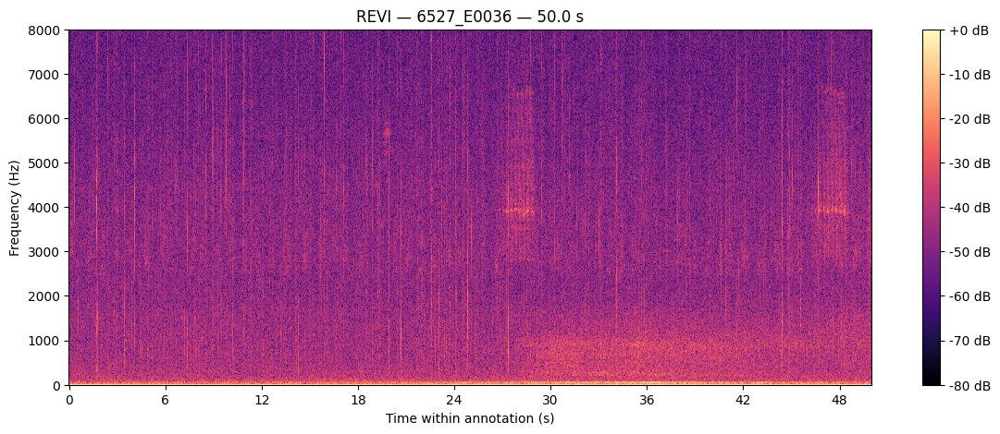

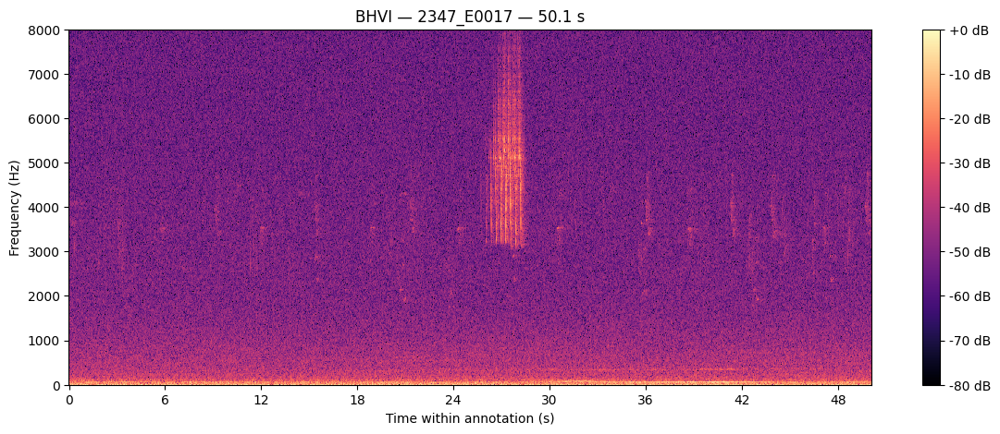

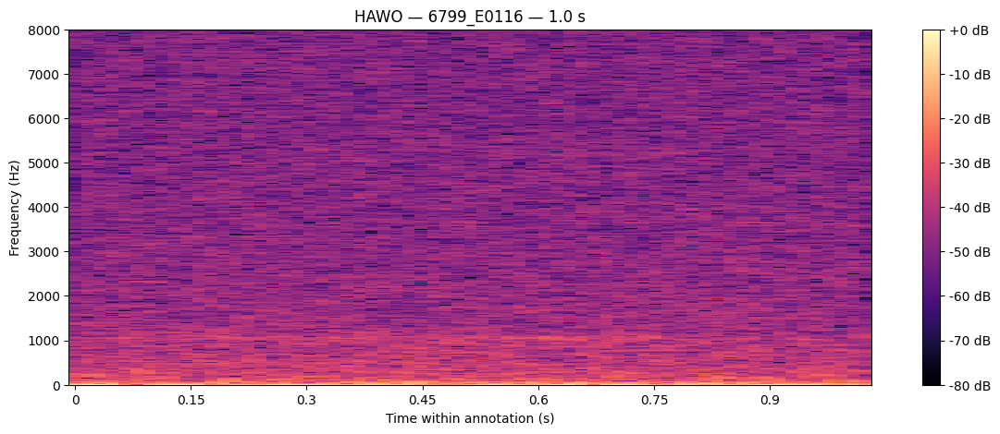

In [ ]:
# ============================================================
# Step 54 — Spectrograms of representative annotations
# ============================================================

import soundfile as sf
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

examples = [
    ("REVI", revi_example),
    ("BHVI", bhvi_example),
    ("HAWO", short_example),
]

for label, example in examples:

    # Locate recording
    recording_matches = list(
        (RECORDINGS_DIR / example["dataset_ID"]).rglob(
            f"*{example['itemID']}*.flac"
        )
    )

    recording_path = recording_matches[0]

    # Load only the relevant segment
    audio_seg, sr_seg = sf.read(
        recording_path,
        start=int(example["begin_time_s"] * 32000),
        stop=int(example["end_time_s"] * 32000)
    )

    # Handle stereo just in case
    if audio_seg.ndim > 1:
        audio_seg = audio_seg.mean(axis=1)

    S = librosa.stft(
        audio_seg,
        n_fft=2048,
        hop_length=512
    )

    plt.figure(figsize=(14, 5))

    librosa.display.specshow(
        librosa.amplitude_to_db(
            np.abs(S),
            ref=np.max
        ),
        sr=sr_seg,
        hop_length=512,
        x_axis="time",
        y_axis="hz"
    )

    plt.ylim(0, 8000)
    plt.colorbar(format="%+2.0f dB")
    plt.title(
        f"{label} — {example['event_id']} — "
        f"{example['duration_s']:.1f} s"
    )
    plt.xlabel("Time within annotation (s)")
    plt.ylabel("Frequency (Hz)")
    plt.show()

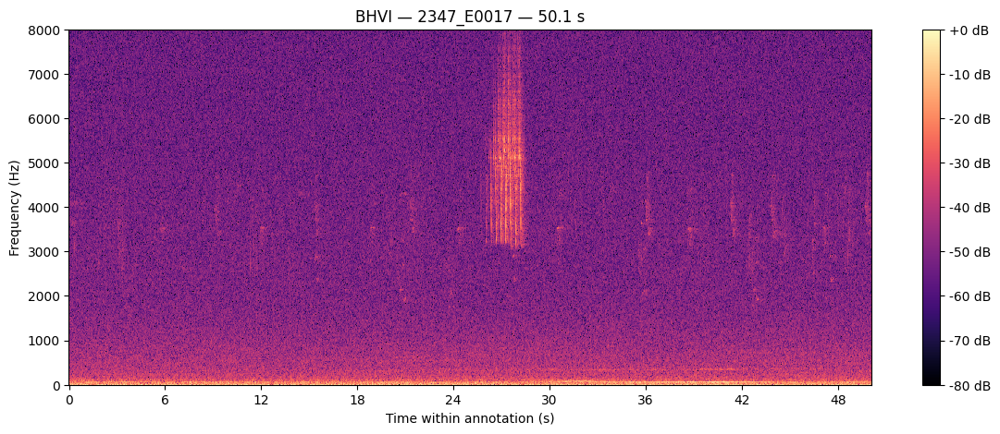

In [ ]:
# ============================================================
# Step 55 — BHVI representative long annotation
# ============================================================

bhvi = bhvi_example

recording_matches = list(
    (RECORDINGS_DIR / bhvi["dataset_ID"]).rglob(
        f"*{bhvi['itemID']}*.flac"
    )
)

recording_path = recording_matches[0]

audio_bhvi_seg, sr_bhvi_seg = sf.read(
    recording_path,
    start=int(bhvi["begin_time_s"] * 32000),
    stop=int(bhvi["end_time_s"] * 32000)
)

if audio_bhvi_seg.ndim > 1:
    audio_bhvi_seg = audio_bhvi_seg.mean(axis=1)

S_bhvi = librosa.stft(
    audio_bhvi_seg,
    n_fft=2048,
    hop_length=512
)

plt.figure(figsize=(14, 5))

librosa.display.specshow(
    librosa.amplitude_to_db(
        np.abs(S_bhvi),
        ref=np.max
    ),
    sr=sr_bhvi_seg,
    hop_length=512,
    x_axis="time",
    y_axis="hz"
)

plt.ylim(0, 8000)
plt.colorbar(format="%+2.0f dB")
plt.title(
    f"BHVI — {bhvi['event_id']} — "
    f"{bhvi['duration_s']:.1f} s"
)
plt.xlabel("Time within annotation (s)")
plt.ylabel("Frequency (Hz)")
plt.show()

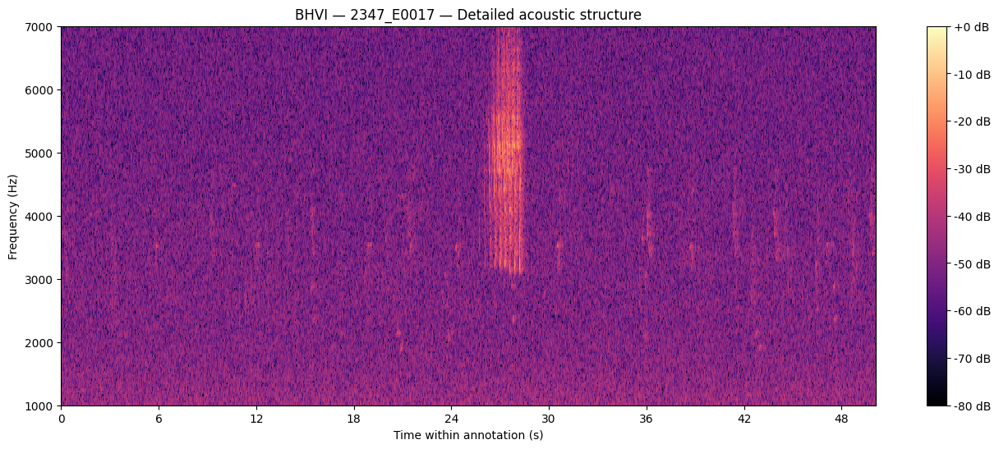

In [ ]:
# ============================================================
# Step 56 — Inspect BHVI at higher temporal resolution
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

y = audio_bhvi_seg
sr = sr_bhvi_seg

fig, ax = plt.subplots(figsize=(16, 6))

S = librosa.stft(
    y,
    n_fft=1024,
    hop_length=256
)

S_db = librosa.amplitude_to_db(
    np.abs(S),
    ref=np.max
)

img = librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=256,
    x_axis="time",
    y_axis="hz",
    ax=ax
)

ax.set_ylim(1000, 7000)

ax.set_title(
    "BHVI — 2347_E0017 — Detailed acoustic structure"
)

ax.set_xlabel("Time within annotation (s)")
ax.set_ylabel("Frequency (Hz)")

fig.colorbar(
    img,
    ax=ax,
    format="%+2.0f dB"
)

plt.show()

In [ ]:
# ============================================================
# Step 57 — Listen to the prominent BHVI bout
# ============================================================

from IPython.display import Audio, display

# 24–32 seconds within the BHVI annotation
start_s = 24
end_s = 32

bhvi_bout = audio_bhvi_seg[
    int(start_s * sr_bhvi_seg):
    int(end_s * sr_bhvi_seg)
]

display(Audio(bhvi_bout, rate=sr_bhvi_seg))

In [ ]:
# ============================================================
# Step 58 — Efficient temporal relationship check
# ============================================================

import numpy as np
import pandas as pd

events_sorted = (
    master_events[
        [
            "event_id",
            "itemID",
            "species_code",
            "begin_time_s",
            "end_time_s",
            "duration_s"
        ]
    ]
    .sort_values(["itemID", "begin_time_s", "end_time_s"])
    .reset_index(drop=True)
)

overlap_count = 0
gap_0_to_2s_count = 0
gap_over_2s_count = 0

for item_id, group in events_sorted.groupby("itemID", sort=False):

    starts = group["begin_time_s"].to_numpy()
    ends = group["end_time_s"].to_numpy()

    n = len(group)

    # For each annotation, only inspect subsequent annotations
    # whose start occurs before the current annotation ends + 2 s.
    for i in range(n - 1):

        cutoff = ends[i] + 2.0

        j = np.searchsorted(
            starts,
            cutoff,
            side="left",
            sorter=None
        )

        # Subsequent annotations are indices i+1 through j-1
        if j <= i + 1:
            continue

        subsequent_starts = starts[i + 1:j]

        # Overlap if the next annotation begins before
        # the current annotation ends.
        n_overlap = np.sum(
            subsequent_starts < ends[i]
        )

        overlap_count += int(n_overlap)

        # Non-overlapping annotations beginning within 2 s
        # of the current annotation's end.
        n_near = np.sum(
            (subsequent_starts >= ends[i]) &
            (subsequent_starts <= ends[i] + 2.0)
        )

        gap_0_to_2s_count += int(n_near)

        # Everything beyond the 2-second window is not
        # counted here because we don't need every distant pair.
        # We'll calculate the total relevant pairs separately.

# Summarize
relationship_summary = pd.DataFrame({
    "relationship": [
        "overlap",
        "gap_0_to_2s"
    ],
    "n_pairs": [
        overlap_count,
        gap_0_to_2s_count
    ]
})

display(relationship_summary)

,relationship,n_pairs
0,overlap,139153
1,gap_0_to_2s,128281


In [ ]:
# ============================================================
# Step 59 — Distribution of gaps between consecutive annotations
# ============================================================

events_sorted = (
    master_events[
        [
            "event_id",
            "itemID",
            "species_code",
            "begin_time_s",
            "end_time_s",
            "duration_s"
        ]
    ]
    .sort_values(["itemID", "begin_time_s", "end_time_s"])
    .reset_index(drop=True)
)

# Look at the next annotation within each recording
events_sorted["next_begin_s"] = (
    events_sorted
    .groupby("itemID")["begin_time_s"]
    .shift(-1)
)

events_sorted["gap_s"] = (
    events_sorted["next_begin_s"]
    - events_sorted["end_time_s"]
)

# Keep only genuinely non-overlapping consecutive annotations
gaps = events_sorted[
    events_sorted["gap_s"] >= 0
].copy()

print(f"Non-overlapping consecutive pairs: {len(gaps):,}")

print("\nGap summary:")
display(
    gaps["gap_s"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nSelected gap thresholds:")
for threshold in [0, 0.5, 1, 2, 3, 5, 10, 15, 20, 30]:
    pct = (gaps["gap_s"] <= threshold).mean() * 100
    print(f"≤ {threshold:>4} s: {pct:6.2f}%")

Non-overlapping consecutive pairs: 123,189

Gap summary:


,gap_s
count,123189.000000
mean,3.647937
std,8.119377
min,0.000000
25%,0.771900
50%,1.984703
75%,4.189369
90%,7.999589
95%,11.164552
99%,24.222690



Selected gap thresholds:
≤    0 s:   0.15%
≤  0.5 s:  17.35%
≤    1 s:  30.70%
≤    2 s:  50.26%
≤    3 s:  64.43%
≤    5 s:  79.71%
≤   10 s:  93.63%
≤   15 s:  97.30%
≤   20 s:  98.58%
≤   30 s:  99.30%


In [ ]:
# ============================================================
# Step 60 — Examine overlap duration between annotations
# ============================================================

events_sorted = (
    master_events[
        [
            "event_id",
            "itemID",
            "species_code",
            "begin_time_s",
            "end_time_s",
            "duration_s"
        ]
    ]
    .sort_values(["itemID", "begin_time_s", "end_time_s"])
    .reset_index(drop=True)
)

overlap_durations = []

for item_id, group in events_sorted.groupby("itemID", sort=False):

    starts = group["begin_time_s"].to_numpy()
    ends = group["end_time_s"].to_numpy()

    n = len(group)

    for i in range(n - 1):

        # Only inspect annotations that begin before
        # the current annotation ends.
        j = np.searchsorted(
            starts,
            ends[i],
            side="left"
        )

        if j <= i + 1:
            continue

        other_starts = starts[i + 1:j]
        other_ends = ends[i + 1:j]

        overlap = np.minimum(ends[i], other_ends) - np.maximum(
            starts[i], other_starts
        )

        overlap = overlap[overlap > 0]

        if len(overlap):
            overlap_durations.extend(overlap)

overlap_durations = np.asarray(overlap_durations)

print(f"Overlapping pairs: {len(overlap_durations):,}")

print("\nOverlap-duration summary:")
display(
    pd.Series(overlap_durations).describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nSelected overlap thresholds:")
for threshold in [0.1, 0.5, 1, 2, 5, 10]:
    pct = (overlap_durations <= threshold).mean() * 100
    print(f"≤ {threshold:>4} s: {pct:6.2f}%")

Overlapping pairs: 139,151

Overlap-duration summary:


,0
count,1.391510e+05
mean,1.338916e+00
std,2.357641e+00
min,3.200000e-08
25%,5.676176e-01
50%,1.158415e+00
75%,1.690908e+00
90%,2.317838e+00
95%,2.806929e+00
99%,5.256703e+00



Selected overlap thresholds:
≤  0.1 s:   4.51%
≤  0.5 s:  22.22%
≤    1 s:  43.13%
≤    2 s:  84.21%
≤    5 s:  98.90%
≤   10 s:  99.68%


In [ ]:
# ============================================================
# Step 61 — Examine temporal ordering of overlapping events
# ============================================================

events_sorted = (
    master_events[
        [
            "event_id",
            "itemID",
            "species_code",
            "begin_time_s",
            "end_time_s",
            "duration_s"
        ]
    ]
    .sort_values(["itemID", "begin_time_s", "end_time_s"])
    .reset_index(drop=True)
)

start_differences = []

for item_id, group in events_sorted.groupby("itemID", sort=False):

    starts = group["begin_time_s"].to_numpy()
    ends = group["end_time_s"].to_numpy()

    n = len(group)

    for i in range(n - 1):

        j = np.searchsorted(
            starts,
            ends[i],
            side="left"
        )

        if j <= i + 1:
            continue

        # How much later did the second annotation begin?
        start_diff = starts[i + 1:j] - starts[i]

        start_differences.extend(start_diff)

start_differences = np.asarray(start_differences)

print(f"Overlapping pairs: {len(start_differences):,}")

print("\nDifference between annotation start times:")
display(
    pd.Series(start_differences).describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nStart-time separation:")
for threshold in [0.1, 0.25, 0.5, 1, 2, 5]:
    pct = (start_differences <= threshold).mean() * 100
    print(f"≤ {threshold:>4} s: {pct:6.2f}%")

Overlapping pairs: 139,153

Difference between annotation start times:


,0
count,139153.000000
mean,16.728523
std,32.181176
min,0.000000
10%,0.457531
25%,1.069683
50%,4.011650
75%,26.583152
90%,45.340654
95%,52.436379



Start-time separation:
≤  0.1 s:   2.20%
≤ 0.25 s:   5.46%
≤  0.5 s:  11.01%
≤    1 s:  23.32%
≤    2 s:  41.01%
≤    5 s:  51.86%


In [ ]:
# ============================================================
# Step 62 — How many potential edges does each event create?
# ============================================================

MAX_GAP_S = 10.0

events_sorted = (
    master_events[
        [
            "event_id",
            "itemID",
            "species_code",
            "begin_time_s",
            "end_time_s",
            "duration_s"
        ]
    ]
    .sort_values(["itemID", "begin_time_s", "end_time_s", "event_id"])
    .reset_index(drop=True)
)

edge_counts = []

for item_id, group in events_sorted.groupby("itemID", sort=False):

    starts = group["begin_time_s"].to_numpy()
    ends = group["end_time_s"].to_numpy()
    event_ids = group["event_id"].to_numpy()
    species = group["species_code"].to_numpy()

    n = len(group)

    for i in range(n):

        # Candidate events beginning before the source
        # ends + maximum succession gap.
        j = np.searchsorted(
            starts,
            ends[i] + MAX_GAP_S,
            side="right"
        )

        # Only later events
        n_candidates = max(0, j - i - 1)

        edge_counts.append({
            "event_id": event_ids[i],
            "itemID": item_id,
            "species_code": species[i],
            "duration_s": ends[i] - starts[i],
            "potential_outgoing_edges": n_candidates
        })

edge_count_df = pd.DataFrame(edge_counts)

print("Number of events:", len(edge_count_df))

print("\nPotential outgoing-edge summary:")
display(
    edge_count_df["potential_outgoing_edges"].describe(
        percentiles=[0.50, 0.90, 0.95, 0.99, 0.999]
    )
)

print("\nEvents with the most potential outgoing edges:")
display(
    edge_count_df
    .sort_values("potential_outgoing_edges", ascending=False)
    .head(20)
)

print("\nPotential outgoing edges by species:")
display(
    edge_count_df
    .groupby("species_code")["potential_outgoing_edges"]
    .agg(
        n_events="size",
        median="median",
        mean="mean",
        maximum="max"
    )
    .sort_values("maximum", ascending=False)
    .head(20)
)

Number of events: 184086

Potential outgoing-edge summary:


,potential_outgoing_edges
count,184086.000000
mean,4.352477
std,3.932053
min,0.000000
50%,4.000000
90%,8.000000
95%,10.000000
99%,19.000000
99.9%,42.000000
max,202.000000



Events with the most potential outgoing edges:


,event_id,itemID,species_code,duration_s,potential_outgoing_edges
19637,2368_E0002,2368,REVI,596.955646,202
36167,2525_E0001,2525,REVI,598.991835,106
34648,2514_E0002,2514,REVI,597.876345,104
19281,2366_E0001,2366,REVI,404.826599,102
27138,2446_E0024,2446,REVI,474.640474,87
20423,2373_E0055,2373,REVI,506.310500,87
4119,1734_E0099,1734,REVI,163.063021,81
120476,5399_E0257,5399,????,121.349348,80
10265,2244_E0033,2244,EACH,181.231905,77
14183,2286_E0001,2286,BHVI,493.497339,76



Potential outgoing edges by species:


,n_events,median,mean,maximum
species_code,,,,
REVI,6724,9.0,13.034652,202
????,588,4.0,4.634354,80
EACH,313,5.0,6.613419,77
BHVI,1885,5.0,6.235013,76
AMCR,4837,4.0,4.433326,55
UNMA,263,4.0,7.057034,53
RBNU,1601,4.0,4.422236,38
HETH,18572,3.0,3.568329,37
BCCH,6398,5.0,5.592685,34


In [ ]:
# ============================================================
# Step 63 — Inspect candidate relationships for the
# longest/highest-connectivity annotation
# ============================================================

TEST_EVENT_ID = "2368_E0002"

source = master_events[
    master_events["event_id"] == TEST_EVENT_ID
].iloc[0]

same_recording = (
    master_events[
        master_events["itemID"] == source["itemID"]
    ]
    .copy()
    .sort_values(
        ["begin_time_s", "end_time_s", "event_id"]
    )
)

candidates = same_recording[
    same_recording["event_id"] != TEST_EVENT_ID
].copy()

# Keep only events that occur after the source annotation
# begins and before source end + MAX_GAP.
candidates = candidates[
    (candidates["begin_time_s"] > source["begin_time_s"]) &
    (candidates["begin_time_s"] <= source["end_time_s"] + MAX_GAP_S)
].copy()

# Determine relationship type
candidates["relationship_type"] = np.where(
    candidates["begin_time_s"] < source["end_time_s"],
    "overlap",
    "succession"
)

# Calculate temporal quantities
candidates["start_lag_s"] = (
    candidates["begin_time_s"] - source["begin_time_s"]
)

candidates["overlap_duration_s"] = np.where(
    candidates["relationship_type"] == "overlap",
    np.minimum(
        source["end_time_s"],
        candidates["end_time_s"]
    )
    - candidates["begin_time_s"],
    np.nan
)

candidates["gap_s"] = np.where(
    candidates["relationship_type"] == "succession",
    candidates["begin_time_s"] - source["end_time_s"],
    np.nan
)

print("SOURCE EVENT")
display(
    pd.DataFrame([{
        "event_id": source["event_id"],
        "itemID": source["itemID"],
        "species": source["species_code"],
        "begin_time_s": source["begin_time_s"],
        "end_time_s": source["end_time_s"],
        "duration_s": source["duration_s"]
    }])
)

print("\nCandidate relationships:")
display(
    candidates[
        [
            "event_id",
            "species_code",
            "begin_time_s",
            "end_time_s",
            "duration_s",
            "relationship_type",
            "start_lag_s",
            "overlap_duration_s",
            "gap_s"
        ]
    ]
    .head(50)
)

print("\nRelationship counts:")
display(
    candidates["relationship_type"]
    .value_counts()
    .rename_axis("relationship_type")
    .to_frame("n")
)

print("\nTarget species:")
display(
    candidates["species_code"]
    .value_counts()
    .head(20)
)

SOURCE EVENT


,event_id,itemID,species,begin_time_s,end_time_s,duration_s
0,2368_E0002,2368,REVI,2.03629,598.991936,596.955646



Candidate relationships:


,event_id,species_code,begin_time_s,end_time_s,duration_s,relationship_type,start_lag_s,overlap_duration_s,gap_s
19638,2368_E0003,RBGR,4.354838,7.721773,3.366935,overlap,2.318548,3.366935,NaN
19639,2368_E0004,BAWW,10.233286,12.389653,2.156367,overlap,8.196996,2.156367,NaN
19640,2368_E0005,OVEN,12.822578,14.758062,1.935484,overlap,10.786288,1.935484,NaN
19641,2368_E0006,BTBW,14.337638,15.807462,1.469824,overlap,12.301348,1.469824,NaN
19642,2368_E0007,RBGR,14.879030,17.661287,2.782258,overlap,12.842740,2.782258,NaN
19643,2368_E0008,OVEN,15.425591,17.515754,2.090163,overlap,13.389301,2.090163,NaN
19644,2368_E0009,RBGR,22.681448,26.088705,3.407257,overlap,20.645158,3.407257,NaN
19645,2368_E0010,EAWP,26.754028,28.145156,1.391129,overlap,24.717738,1.391129,NaN
19646,2368_E0011,OVEN,29.516124,31.290317,1.774193,overlap,27.479834,1.774193,NaN
19647,2368_E0012,RBGR,29.939511,32.439510,2.500000,overlap,27.903221,2.500000,NaN



Relationship counts:


,n
relationship_type,
overlap,202



Target species:


,count
species_code,
EAWP,54
OVEN,51
BAWW,38
BTBW,28
RBGR,10
CSWA,9
YBSA,6
WIWR,4
PIWA,2


In [ ]:
# ============================================================
# Step 64 — Test conservative overlap windows
# ============================================================

# We already calculated overlapping pairs in Step 61.
# Recalculate the start-time separation distribution
# by recording, using the same overlap definition.

start_lags = []

for item_id, group in events_sorted.groupby("itemID", sort=False):

    starts = group["begin_time_s"].to_numpy()
    ends = group["end_time_s"].to_numpy()

    n = len(group)

    for i in range(n):

        j = np.searchsorted(
            starts,
            ends[i],
            side="left"
        )

        if j <= i + 1:
            continue

        candidate_starts = starts[i + 1:j]

        # Start-time difference from the source
        lags = candidate_starts - starts[i]

        start_lags.extend(lags)

start_lags = np.asarray(start_lags)

print(f"Total overlapping pairs: {len(start_lags):,}")

print("\nOverlap relationships retained under different start-time windows:")

for window in [1, 2, 5, 10, 20, 30]:
    n = np.sum(start_lags <= window)
    pct = n / len(start_lags) * 100

    print(
        f"≤ {window:>2} s: "
        f"{n:>7,} pairs "
        f"({pct:6.2f}%)"
    )

Total overlapping pairs: 139,153

Overlap relationships retained under different start-time windows:
≤  1 s:  32,452 pairs ( 23.32%)
≤  2 s:  57,067 pairs ( 41.01%)
≤  5 s:  72,166 pairs ( 51.86%)
≤ 10 s:  81,718 pairs ( 58.73%)
≤ 20 s:  95,979 pairs ( 68.97%)
≤ 30 s: 108,395 pairs ( 77.90%)


In [ ]:
# ============================================================
# Step 65 — Count proposed local temporal relationships
# ============================================================

MAX_WINDOW_S = 10.0

local_overlap_count = 0
local_succession_count = 0

for item_id, group in events_sorted.groupby("itemID", sort=False):

    starts = group["begin_time_s"].to_numpy()
    ends = group["end_time_s"].to_numpy()

    n = len(group)

    for i in range(n):

        # Only later-starting events within 10 seconds
        # of the source start.
        j = np.searchsorted(
            starts,
            starts[i] + MAX_WINDOW_S,
            side="right"
        )

        if j <= i + 1:
            continue

        target_starts = starts[i + 1:j]

        # Overlap
        overlap_mask = target_starts < ends[i]

        local_overlap_count += int(
            np.sum(overlap_mask)
        )

        # Succession
        succession_mask = target_starts >= ends[i]

        # Must begin no more than 10 s after source ends
        succession_gaps = (
            target_starts[succession_mask] - ends[i]
        )

        local_succession_count += int(
            np.sum(succession_gaps <= MAX_WINDOW_S)
        )

print("Proposed local temporal relationships")
print("-------------------------------------")
print(f"Overlap edges:    {local_overlap_count:,}")
print(f"Succession edges: {local_succession_count:,}")
print(
    f"Total edges:      "
    f"{local_overlap_count + local_succession_count:,}"
)

Proposed local temporal relationships
-------------------------------------
Overlap edges:    81,718
Succession edges: 530,128
Total edges:      611,846


In [ ]:
# ============================================================
# Step 66 — Compare all local succession relationships
#           with immediate-next succession relationships
# ============================================================

MAX_WINDOW_S = 10.0

all_succession = 0
next_succession = 0

for item_id, group in events_sorted.groupby("itemID", sort=False):

    starts = group["begin_time_s"].to_numpy()
    ends = group["end_time_s"].to_numpy()

    n = len(group)

    for i in range(n - 1):

        # ----------------------------------------------------
        # All later events beginning within 10 s after source
        # ends
        # ----------------------------------------------------

        j = np.searchsorted(
            starts,
            ends[i] + MAX_WINDOW_S,
            side="right"
        )

        if j > i + 1:

            target_starts = starts[i + 1:j]

            gaps = target_starts - ends[i]

            all_succession += int(
                np.sum(gaps >= 0)
            )

        # ----------------------------------------------------
        # Immediate next annotation only
        # ----------------------------------------------------

        next_gap = starts[i + 1] - ends[i]

        if 0 <= next_gap <= MAX_WINDOW_S:
            next_succession += 1

print("Succession relationship comparison")
print("-----------------------------------")
print(f"All local succession edges:     {all_succession:,}")
print(f"Immediate-next succession:      {next_succession:,}")

print(
    f"\nAdditional non-immediate edges: "
    f"{all_succession - next_succession:,}"
)

print(
    f"Ratio (all / immediate): "
    f"{all_succession / next_succession:.2f}"
)

Succession relationship comparison
-----------------------------------
All local succession edges:     662,077
Immediate-next succession:      115,341

Additional non-immediate edges: 546,736
Ratio (all / immediate): 5.74


In [ ]:
# ============================================================
# Step 67 — Count edges under the revised initial network rule
# ============================================================

MAX_WINDOW_S = 10.0

overlap_edges = 0
succession_edges = 0

for item_id, group in events_sorted.groupby("itemID", sort=False):

    starts = group["begin_time_s"].to_numpy()
    ends = group["end_time_s"].to_numpy()

    n = len(group)

    for i in range(n):

        # ----------------------------------------------------
        # Overlap relationships:
        # all later-starting events that begin within 10 s
        # of the source start AND overlap the source.
        # ----------------------------------------------------

        j = np.searchsorted(
            starts,
            starts[i] + MAX_WINDOW_S,
            side="right"
        )

        if j > i + 1:

            target_starts = starts[i + 1:j]

            overlap_edges += int(
                np.sum(target_starts < ends[i])
            )

        # ----------------------------------------------------
        # Succession:
        # ONLY the immediate next annotation.
        # ----------------------------------------------------

        if i < n - 1:

            gap = starts[i + 1] - ends[i]

            if 0 <= gap <= MAX_WINDOW_S:
                succession_edges += 1

print("Revised initial network")
print("-----------------------")
print(f"Overlap edges:              {overlap_edges:,}")
print(f"Immediate succession edges: {succession_edges:,}")
print(
    f"Total edges:                "
    f"{overlap_edges + succession_edges:,}"
)

Revised initial network
-----------------------
Overlap edges:              81,718
Immediate succession edges: 115,341
Total edges:                197,059


In [ ]:
# ============================================================
# Step 68 — Build and inspect proposed edges on test recordings
# ============================================================

MAX_WINDOW_S = 10.0

TEST_ITEM_IDS = [2344, 2481, 6527]


def build_edges_for_recording(group, max_window_s=10.0):

    group = (
        group
        .sort_values(
            ["begin_time_s", "end_time_s", "event_id"]
        )
        .reset_index(drop=True)
    )

    starts = group["begin_time_s"].to_numpy()
    ends = group["end_time_s"].to_numpy()

    edges = []

    for i in range(len(group)):

        source = group.iloc[i]

        # ----------------------------------------------------
        # Overlap edges
        # ----------------------------------------------------

        j = np.searchsorted(
            starts,
            starts[i] + max_window_s,
            side="right"
        )

        if j > i + 1:

            for k in range(i + 1, j):

                target = group.iloc[k]

                if target["begin_time_s"] < source["end_time_s"]:

                    overlap_duration = (
                        min(
                            source["end_time_s"],
                            target["end_time_s"]
                        )
                        - target["begin_time_s"]
                    )

                    if overlap_duration > 0:

                        edges.append({
                            "source_event": source["event_id"],
                            "target_event": target["event_id"],
                            "source_species": source["species_code"],
                            "target_species": target["species_code"],
                            "relationship_type": "overlap",
                            "start_lag_s": (
                                target["begin_time_s"]
                                - source["begin_time_s"]
                            ),
                            "gap_s": np.nan,
                            "overlap_duration_s": overlap_duration
                        })

        # ----------------------------------------------------
        # Immediate succession edge
        # ----------------------------------------------------

        if i < len(group) - 1:

            target = group.iloc[i + 1]

            gap = (
                target["begin_time_s"]
                - source["end_time_s"]
            )

            if 0 <= gap <= max_window_s:

                edges.append({
                    "source_event": source["event_id"],
                    "target_event": target["event_id"],
                    "source_species": source["species_code"],
                    "target_species": target["species_code"],
                    "relationship_type": "succession",
                    "start_lag_s": (
                        target["begin_time_s"]
                        - source["begin_time_s"]
                    ),
                    "gap_s": gap,
                    "overlap_duration_s": np.nan
                })

    return pd.DataFrame(edges)


test_edge_tables = {}

for item_id in TEST_ITEM_IDS:

    recording_events = master_events[
        master_events["itemID"] == item_id
    ].copy()

    edge_table = build_edges_for_recording(
        recording_events,
        max_window_s=MAX_WINDOW_S
    )

    test_edge_tables[item_id] = edge_table

    print("\n" + "=" * 70)
    print(f"ItemID: {item_id}")
    print(f"Events: {len(recording_events):,}")
    print(f"Edges:  {len(edge_table):,}")

    print("\nRelationship counts:")
    display(
        edge_table["relationship_type"]
        .value_counts()
        .rename_axis("relationship_type")
        .to_frame("n_edges")
    )

    print("\nFirst 15 edges:")
    display(edge_table.head(15))


ItemID: 2344
Events: 189
Edges:  225

Relationship counts:


,n_edges
relationship_type,
succession,124
overlap,101



First 15 edges:


,source_event,target_event,source_species,target_species,relationship_type,start_lag_s,gap_s,overlap_duration_s
0,2344_E0001,2344_E0002,REVI,EAWP,overlap,0.136467,NaN,1.398787
1,2344_E0001,2344_E0003,REVI,OVEN,overlap,2.012888,NaN,1.944655
2,2344_E0001,2344_E0004,REVI,PIWA,overlap,4.128127,NaN,2.012888
3,2344_E0001,2344_E0005,REVI,EAWP,overlap,7.471568,NaN,1.739954
4,2344_E0002,2344_E0003,EAWP,OVEN,succession,1.876421,0.477634,NaN
5,2344_E0003,2344_E0004,OVEN,PIWA,succession,2.115238,0.170584,NaN
6,2344_E0004,2344_E0005,PIWA,EAWP,succession,3.343441,1.330553,NaN
7,2344_E0005,2344_E0006,EAWP,EAWP,succession,5.833964,4.094010,NaN
8,2344_E0006,2344_E0007,EAWP,OVEN,succession,6.755116,5.799847,NaN
9,2344_E0007,2344_E0008,OVEN,TUTI,overlap,1.639145,NaN,0.578443



ItemID: 2481
Events: 50
Edges:  43

Relationship counts:


...

,source_event,target_event,source_species,target_species,relationship_type,start_lag_s,gap_s,overlap_duration_s
0,2481_E0001,2481_E0002,BTNW,BHVI,succession,1.595442,0.678041,NaN
1,2481_E0002,2481_E0003,BHVI,BTNW,overlap,8.618928,NaN,1.144388
2,2481_E0003,2481_E0004,BTNW,BTNW,succession,9.854976,8.710588,NaN
3,2481_E0004,2481_E0005,BTNW,BLJA,succession,6.469101,5.542242,NaN
4,2481_E0005,2481_E0006,BLJA,BTNW,succession,3.395332,1.617275,NaN
5,2481_E0007,2481_E0008,BLJA,BTNW,overlap,0.274275,NaN,1.541613
6,2481_E0008,2481_E0009,BTNW,BLJA,succession,3.887135,2.127994,NaN
7,2481_E0009,2481_E0010,BLJA,BTNW,succession,6.507343,4.805107,NaN
8,2481_E0010,2481_E0011,BTNW,BLJA,succession,2.678763,0.729839,NaN
9,2481_E0011,2481_E0012,BLJA,BLJA,succession,6.119165,5.249051,NaN



ItemID: 6527
Events: 80
Edges:  71

Relationship counts:


,n_edges
relationship_type,
succession,58
overlap,13



First 15 edges:


,source_event,target_event,source_species,target_species,relationship_type,start_lag_s,gap_s,overlap_duration_s
0,6527_E0002,6527_E0003,BTNW,BTNW,succession,10.076752,9.016955,NaN
1,6527_E0004,6527_E0005,BTNW,BTNW,succession,8.061436,6.469424,NaN
2,6527_E0005,6527_E0006,BTNW,BTNW,succession,9.173724,7.711860,NaN
3,6527_E0006,6527_E0007,BTNW,BTNW,succession,7.622906,6.245788,NaN
4,6527_E0007,6527_E0008,BTNW,OVEN,overlap,1.429285,NaN,0.273241
5,6527_E0008,6527_E0009,OVEN,BTNW,succession,6.748676,4.385591,NaN
6,6527_E0009,6527_E0010,BTNW,OVEN,succession,3.697032,2.108050,NaN
7,6527_E0010,6527_E0011,OVEN,OVEN,succession,10.223030,7.723031,NaN
8,6527_E0011,6527_E0012,OVEN,OVEN,succession,10.899840,8.789289,NaN
9,6527_E0012,6527_E0013,OVEN,OVEN,succession,10.773299,8.152418,NaN


In [ ]:
# ============================================================
# Step 69 — Generate the full network edge table
# ============================================================

MAX_WINDOW_S = 10.0

all_edges = []

for item_id, group in events_sorted.groupby("itemID", sort=False):

    group = (
        group
        .sort_values(
            ["begin_time_s", "end_time_s", "event_id"]
        )
        .reset_index(drop=True)
    )

    starts = group["begin_time_s"].to_numpy()
    ends = group["end_time_s"].to_numpy()

    n = len(group)

    for i in range(n):

        source = group.iloc[i]

        # ----------------------------------------------------
        # OVERLAP EDGES
        # ----------------------------------------------------

        j = np.searchsorted(
            starts,
            starts[i] + MAX_WINDOW_S,
            side="right"
        )

        if j > i + 1:

            for k in range(i + 1, j):

                target = group.iloc[k]

                if target["begin_time_s"] < source["end_time_s"]:

                    overlap_duration = (
                        min(
                            source["end_time_s"],
                            target["end_time_s"]
                        )
                        - target["begin_time_s"]
                    )

                    if overlap_duration > 0:

                        all_edges.append({
                            "source_event": source["event_id"],
                            "target_event": target["event_id"],
                            "itemID": item_id,
                            "source_species": source["species_code"],
                            "target_species": target["species_code"],
                            "relationship_type": "overlap",
                            "start_lag_s": (
                                target["begin_time_s"]
                                - source["begin_time_s"]
                            ),
                            "gap_s": np.nan,
                            "overlap_duration_s": overlap_duration
                        })

        # ----------------------------------------------------
        # IMMEDIATE SUCCESSION EDGE
        # ----------------------------------------------------

        if i < n - 1:

            target = group.iloc[i + 1]

            gap = (
                target["begin_time_s"]
                - source["end_time_s"]
            )

            if 0 <= gap <= MAX_WINDOW_S:

                all_edges.append({
                    "source_event": source["event_id"],
                    "target_event": target["event_id"],
                    "itemID": item_id,
                    "source_species": source["species_code"],
                    "target_species": target["species_code"],
                    "relationship_type": "succession",
                    "start_lag_s": (
                        target["begin_time_s"]
                        - source["begin_time_s"]
                    ),
                    "gap_s": gap,
                    "overlap_duration_s": np.nan
                })


master_edges = pd.DataFrame(all_edges)

print("Full network generated")
print("----------------------")
print(f"Edges: {len(master_edges):,}")

print("\nRelationship counts:")
display(
    master_edges["relationship_type"]
    .value_counts()
    .rename_axis("relationship_type")
    .to_frame("n_edges")
)

print("\nUnique source events:")
print(master_edges["source_event"].nunique())

print("\nUnique target events:")
print(master_edges["target_event"].nunique())

print("\nFirst 10 edges:")
display(master_edges.head(10))

Full network generated
----------------------
Edges: 197,058

Relationship counts:


,n_edges
relationship_type,
succession,115341
overlap,81717



Unique source events:
174396

Unique target events:
174396

First 10 edges:


,source_event,target_event,itemID,source_species,target_species,relationship_type,start_lag_s,gap_s,overlap_duration_s
0,1701_E0002,1701_E0003,1701,OVEN,BTBW,succession,2.359078,0.285751,NaN
1,1701_E0003,1701_E0004,1701,BTBW,OVEN,succession,10.032219,8.773674,NaN
2,1701_E0004,1701_E0005,1701,OVEN,BTBW,succession,5.811314,2.832731,NaN
3,1701_E0005,1701_E0006,1701,BTBW,BTBW,succession,3.589184,2.470477,NaN
4,1701_E0006,1701_E0007,1701,BTBW,OVEN,succession,5.217175,3.967953,NaN
5,1701_E0009,1701_E0010,1701,BCCH,BTBW,overlap,0.857675,NaN,0.205096
6,1701_E0010,1701_E0011,1701,BTBW,OVEN,succession,1.570509,0.451802,NaN
7,1701_E0011,1701_E0012,1701,OVEN,BCCH,succession,6.735888,4.506817,NaN
8,1701_E0012,1701_E0013,1701,BCCH,BTBW,succession,4.307021,3.160346,NaN
9,1701_E0017,1701_E0018,1701,OVEN,BCCH,succession,5.315138,2.735645,NaN


In [ ]:
# Step 70: Network QA/QC

# ---------------------------------------------------------
# 1. Basic edge counts
# ---------------------------------------------------------

print("Total edges:", len(master_edges))

print("\nRelationship counts:")
print(master_edges["relationship_type"].value_counts())

# ---------------------------------------------------------
# 2. Check succession validity
# ---------------------------------------------------------

succ = master_edges[
    master_edges["relationship_type"] == "succession"
].copy()

succ_check = pd.DataFrame({
    "gap_nonnegative": succ["gap_s"].ge(0),
    "gap_le_10s": succ["gap_s"].le(10.0),
    "overlap_missing": succ["overlap_duration_s"].isna()
})

print("\nSuccession QA:")
print(succ_check.sum())
print("Invalid succession edges:", (~succ_check.all(axis=1)).sum())

# ---------------------------------------------------------
# 3. Check overlap validity
# ---------------------------------------------------------

ov = master_edges[
    master_edges["relationship_type"] == "overlap"
].copy()

ov_check = pd.DataFrame({
    "start_lag_nonnegative": ov["start_lag_s"].ge(0),
    "start_lag_le_10s": ov["start_lag_s"].le(10.0),
    "overlap_positive": ov["overlap_duration_s"].gt(0),
    "gap_missing": ov["gap_s"].isna()
})

print("\nOverlap QA:")
print(ov_check.sum())
print("Invalid overlap edges:", (~ov_check.all(axis=1)).sum())

# ---------------------------------------------------------
# 4. Every edge should be within one recording
# ---------------------------------------------------------

same_recording = (
    master_edges["source_event"].str.split("_E").str[0]
    ==
    master_edges["target_event"].str.split("_E").str[0]
)

print("\nCross-recording edges:", (~same_recording).sum())

# ---------------------------------------------------------
# 5. Events participating in the network
# ---------------------------------------------------------

all_events = set(master_events["event_id"])

source_events = set(master_edges["source_event"])
target_events = set(master_edges["target_event"])
network_events = source_events | target_events

isolated_events = all_events - network_events

print("\nEvent participation:")
print("Total events:", len(all_events))
print("Events in network:", len(network_events))
print("Isolated events:", len(isolated_events))
print("Percent isolated:",
      round(100 * len(isolated_events) / len(all_events), 2))

# ---------------------------------------------------------
# 6. Check for duplicate edges
# ---------------------------------------------------------

edge_key = [
    "source_event",
    "target_event",
    "relationship_type"
]

duplicate_edges = master_edges.duplicated(
    subset=edge_key,
    keep=False
)

print("\nDuplicate edge rows:", duplicate_edges.sum())

# ---------------------------------------------------------
# 7. Check for self-loops
# ---------------------------------------------------------

self_loops = (
    master_edges["source_event"]
    == master_edges["target_event"]
)

print("Self-loops:", self_loops.sum())

# ---------------------------------------------------------
# 8. Check for negative timing values
# ---------------------------------------------------------

print("\nNegative start lags:",
      (master_edges["start_lag_s"] < 0).sum())

print("Negative gaps:",
      (master_edges["gap_s"] < 0).sum())

print("Negative overlap durations:",
      (master_edges["overlap_duration_s"] < 0).sum())

Total edges: 197058

Relationship counts:
relationship_type
succession    115341
overlap        81717
Name: count, dtype: int64

Succession QA:
gap_nonnegative    115341
gap_le_10s         115341
overlap_missing    115341
dtype: int64
Invalid succession edges: 0

Overlap QA:
start_lag_nonnegative    81717
start_lag_le_10s         81717
overlap_positive         81717
gap_missing              81717
dtype: int64
Invalid overlap edges: 0

Cross-recording edges: 0

Event participation:
Total events: 184086
Events in network: 180569
Isolated events: 3517
Percent isolated: 1.91

Duplicate edge rows: 0
Self-loops: 0

Negative start lags: 0
Negative gaps: 0
Negative overlap durations: 0


In [ ]:
# Step 71: Network degree QA/QC

# ---------------------------------------------------------
# 1. Count outgoing and incoming edges per event
# ---------------------------------------------------------

out_degree = (
    master_edges
    .groupby("source_event")
    .size()
    .rename("out_degree")
)

in_degree = (
    master_edges
    .groupby("target_event")
    .size()
    .rename("in_degree")
)

degree_df = (
    master_events[["event_id", "itemID", "species_code", "duration_s"]]
    .drop_duplicates("event_id")
    .set_index("event_id")
    .join(out_degree)
    .join(in_degree)
    .fillna(0)
)

degree_df["total_degree"] = (
    degree_df["out_degree"] +
    degree_df["in_degree"]
)

# ---------------------------------------------------------
# 2. Overall degree distribution
# ---------------------------------------------------------

print("Degree summary:")
print(
    degree_df[
        ["out_degree", "in_degree", "total_degree"]
    ].describe()
)

# ---------------------------------------------------------
# 3. Highest-degree events
# ---------------------------------------------------------

print("\nTop 20 events by total degree:")

print(
    degree_df
    .sort_values("total_degree", ascending=False)
    .head(20)
)

# ---------------------------------------------------------
# 4. Highest-degree long annotations
# ---------------------------------------------------------

print("\nTop 20 events by total degree among annotations >30 s:")

print(
    degree_df[
        degree_df["duration_s"] > 30
    ]
    .sort_values("total_degree", ascending=False)
    .head(20)
)

# ---------------------------------------------------------
# 5. Relationship-specific degree
# ---------------------------------------------------------

overlap_edges = master_edges[
    master_edges["relationship_type"] == "overlap"
]

succession_edges = master_edges[
    master_edges["relationship_type"] == "succession"
]

overlap_degree = (
    pd.concat([
        overlap_edges["source_event"],
        overlap_edges["target_event"]
    ])
    .value_counts()
    .rename("overlap_degree")
)

succession_degree = (
    pd.concat([
        succession_edges["source_event"],
        succession_edges["target_event"]
    ])
    .value_counts()
    .rename("succession_degree")
)

degree_df = (
    degree_df
    .join(overlap_degree)
    .join(succession_degree)
    .fillna(0)
)

# ---------------------------------------------------------
# 6. Correlation between annotation duration and degree
# ---------------------------------------------------------

print("\nDuration vs total degree correlation:")
print(
    degree_df[["duration_s", "total_degree"]]
    .corr(method="spearman")
)

print("\nDuration vs overlap degree correlation:")
print(
    degree_df[["duration_s", "overlap_degree"]]
    .corr(method="spearman")
)

Degree summary:
          out_degree      in_degree   total_degree
count  184086.000000  184086.000000  184086.000000
mean        1.070467       1.070467       2.140934
std         0.604848       0.437207       0.783150
min         0.000000       0.000000       0.000000
25%         1.000000       1.000000       2.000000
50%         1.000000       1.000000       2.000000
75%         1.000000       1.000000       2.000000
max        14.000000       6.000000      15.000000

Top 20 events by total degree:
            itemID species_code  duration_s  out_degree  in_degree  \
event_id                                                             
5476_E0371    5476         REVI   56.400724        13.0        2.0   
5382_E0165    5382         REVI   21.633155        14.0        1.0   
5476_E0002    5476         REVI   59.199090        13.0        1.0   
5476_E0121    5476         REVI   58.869316        13.0        1.0   
5382_E0280    5382         REVI   56.900096        13.0        1.0   
541

In [ ]:
# Step 72: Examine what is producing overlap edges

overlap_edges = master_edges[
    master_edges["relationship_type"] == "overlap"
].copy()

# ---------------------------------------------------------
# 1. Overlap edges by source species
# ---------------------------------------------------------

print("Overlap edges by source species:")
print(
    overlap_edges["source_species"]
    .value_counts()
    .head(20)
)

# ---------------------------------------------------------
# 2. Overlap edges by target species
# ---------------------------------------------------------

print("\nOverlap edges by target species:")
print(
    overlap_edges["target_species"]
    .value_counts()
    .head(20)
)

# ---------------------------------------------------------
# 3. Species-pair composition
# ---------------------------------------------------------

species_pairs = (
    overlap_edges
    .groupby(["source_species", "target_species"])
    .size()
    .reset_index(name="n_edges")
    .sort_values("n_edges", ascending=False)
)

print("\nTop 20 overlap species pairs:")
print(species_pairs.head(20))

# ---------------------------------------------------------
# 4. What proportion of overlap edges involve REVI?
# ---------------------------------------------------------

revi_overlap = (
    (overlap_edges["source_species"] == "REVI") |
    (overlap_edges["target_species"] == "REVI")
)

print("\nOverlap edges involving REVI:")
print(revi_overlap.sum())
print(
    "Percent:",
    round(100 * revi_overlap.mean(), 2)
)

# ---------------------------------------------------------
# 5. What proportion involve annotations >30 s?
# ---------------------------------------------------------

duration_lookup = (
    master_events[
        ["event_id", "duration_s"]
    ]
    .drop_duplicates("event_id")
    .set_index("event_id")["duration_s"]
)

overlap_edges["source_duration_s"] = (
    overlap_edges["source_event"].map(duration_lookup)
)

overlap_edges["target_duration_s"] = (
    overlap_edges["target_event"].map(duration_lookup)
)

long_overlap = (
    (overlap_edges["source_duration_s"] > 30) |
    (overlap_edges["target_duration_s"] > 30)
)

print("\nOverlap edges involving an annotation >30 s:")
print(long_overlap.sum())
print(
    "Percent:",
    round(100 * long_overlap.mean(), 2)
)

# ---------------------------------------------------------
# 6. Overlap duration distribution
# ---------------------------------------------------------

print("\nOverlap duration summary:")
print(
    overlap_edges["overlap_duration_s"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Overlap edges by source species:
source_species
REVI    14656
OVEN    13585
BTNW     4055
EAWP     3613
HETH     3450
AMCR     3000
AMRO     2892
BTBW     2870
WOTH     2564
WIWR     2477
SCTA     2472
BCCH     2264
BAWW     2035
RBGR     1906
BLBW     1851
CSWA     1813
BHVI     1749
PIWA     1366
VEER     1184
BLJA     1168
Name: count, dtype: int64

Overlap edges by target species:
target_species
OVEN    14547
BTNW     6474
HETH     5634
WOTH     5191
EAWP     4680
BTBW     3929
BCCH     3181
CSWA     2881
AMCR     2728
AMRO     2656
BLBW     2616
SCTA     2361
REVI     2353
BAWW     2255
VEER     1832
PIWA     1758
BLJA     1586
RBGR     1335
WIWR     1060
YRWA      790
Name: count, dtype: int64

Top 20 overlap species pairs:
     source_species target_species  n_edges
1959           REVI           OVEN     2753
1600           OVEN           OVEN     1760
1621           OVEN           WOTH     1402
1924           REVI           BTNW     1350
1940           REVI           EAWP     1

In [ ]:
# Step 73: Compare overlap edges by annotation duration

# Reuse duration lookup from Step 72
duration_lookup = (
    master_events[
        ["event_id", "duration_s"]
    ]
    .drop_duplicates("event_id")
    .set_index("event_id")["duration_s"]
)

ov = master_edges[
    master_edges["relationship_type"] == "overlap"
].copy()

ov["source_duration_s"] = ov["source_event"].map(duration_lookup)
ov["target_duration_s"] = ov["target_event"].map(duration_lookup)

# ---------------------------------------------------------
# Classify overlap pairs
# ---------------------------------------------------------

ov["overlap_class"] = np.select(
    [
        (ov["source_duration_s"] <= 30) &
        (ov["target_duration_s"] <= 30),

        (ov["source_duration_s"] > 30) &
        (ov["target_duration_s"] <= 30),

        (ov["source_duration_s"] <= 30) &
        (ov["target_duration_s"] > 30),

        (ov["source_duration_s"] > 30) &
        (ov["target_duration_s"] > 30)
    ],
    [
        "short-short",
        "long-source / short-target",
        "short-source / long-target",
        "long-long"
    ],
    default="unknown"
)

# ---------------------------------------------------------
# Counts
# ---------------------------------------------------------

print("Overlap class counts:")
print(
    ov["overlap_class"]
    .value_counts()
)

print("\nOverlap class percentages:")
print(
    100 * ov["overlap_class"].value_counts(normalize=True)
)

# ---------------------------------------------------------
# Duration summaries by class
# ---------------------------------------------------------

print("\nOverlap-duration summary by class:")

print(
    ov.groupby("overlap_class")["overlap_duration_s"]
      .describe(
          percentiles=[0.50, 0.90, 0.95, 0.99]
      )
)

# ---------------------------------------------------------
# Species diversity by class
# ---------------------------------------------------------

for cls, group in ov.groupby("overlap_class"):

    print(f"\n{cls}")

    print("Unique source species:",
          group["source_species"].nunique())

    print("Unique target species:",
          group["target_species"].nunique())

    print("Number of edges:",
          len(group))

Overlap class counts:
overlap_class
short-short                   67923
long-source / short-target    12019
short-source / long-target     1641
long-long                       134
Name: count, dtype: int64

Overlap class percentages:
overlap_class
short-short                   83.119791
long-source / short-target    14.708078
short-source / long-target     2.008150
long-long                      0.163981
Name: proportion, dtype: float64

Overlap-duration summary by class:
                              count       mean        std           min  \
overlap_class                                                             
long-long                     134.0  53.415574  32.925789  2.505471e+01   
long-source / short-target  12019.0   1.796191   1.432198  9.422100e-02   
short-short                 67923.0   0.796023   0.729815  3.200000e-08   
short-source / long-target   1641.0   1.277868   2.459612  5.735000e-04   

                                  50%        90%        95%        99%  

In [ ]:
# Step 74: Quantify the succession-definition difference

events_sorted = (
    master_events
    .sort_values(["itemID", "begin_time_s", "end_time_s", "event_id"])
    .copy()
)

comparison_rows = []

for item_id, group in events_sorted.groupby("itemID", sort=False):

    group = group.reset_index(drop=True)

    for i in range(len(group) - 1):

        source = group.iloc[i]

        # Immediate next annotation
        immediate = group.iloc[i + 1]

        # If immediate next annotation overlaps source,
        # search for the first later event that begins
        # after source ends.
        later = group.iloc[i + 1:]

        nonoverlap_candidates = later[
            later["begin_time_s"] >= source["end_time_s"]
        ]

        if len(nonoverlap_candidates) == 0:
            continue

        next_nonoverlap = nonoverlap_candidates.iloc[0]

        immediate_overlaps = (
            immediate["begin_time_s"] < source["end_time_s"]
        )

        gap_to_next_nonoverlap = (
            next_nonoverlap["begin_time_s"]
            - source["end_time_s"]
        )

        comparison_rows.append({
            "source_event": source["event_id"],
            "immediate_event": immediate["event_id"],
            "immediate_overlaps": immediate_overlaps,
            "next_nonoverlap_event": next_nonoverlap["event_id"],
            "gap_to_next_nonoverlap_s": gap_to_next_nonoverlap,
            "within_10s": (
                0 <= gap_to_next_nonoverlap <= 10
            )
        })

comparison_df = pd.DataFrame(comparison_rows)

# Cases where the immediate event overlaps, but a later
# non-overlapping event is within 10 seconds.
affected = comparison_df[
    (comparison_df["immediate_overlaps"]) &
    (comparison_df["within_10s"])
]

print("Total source events examined:",
      len(comparison_df))

print(
    "\nSources where current rule and "
    "'next non-overlapping event' rule differ:"
)
print(len(affected))

print(
    "\nPercent of examined sources:"
)
print(
    round(100 * len(affected) / len(comparison_df), 3)
)

print(
    "\nGap to next non-overlapping event summary:"
)

print(
    affected["gap_to_next_nonoverlap_s"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nFirst 20 affected cases:")
print(
    affected.head(20)
)

Total source events examined: 182121

Sources where current rule and 'next non-overlapping event' rule differ:
57688

Percent of examined sources:
31.676

Gap to next non-overlapping event summary:
count    57688.000000
mean         2.158854
std          1.977950
min          0.000000
25%          0.697236
50%          1.572242
75%          2.980069
90%          4.932954
95%          6.471810
99%          8.882083
max          9.998002
Name: gap_to_next_nonoverlap_s, dtype: float64

First 20 affected cases:
    source_event immediate_event  immediate_overlaps next_nonoverlap_event  \
8     1701_E0009      1701_E0010                True            1701_E0011   
25    1701_E0026      1701_E0027                True            1701_E0028   
28    1701_E0029      1701_E0030                True            1701_E0031   
49    1701_E0050      1701_E0051                True            1701_E0052   
56    1701_E0057      1701_E0058                True            1701_E0059   
92    1702_E0027   

In [ ]:
# Step 75: Regenerate network with corrected succession definition

MAX_WINDOW_S = 10.0

edge_rows = []

for item_id, group in master_events.groupby("itemID", sort=False):

    group = (
        group
        .sort_values(
            ["begin_time_s", "end_time_s", "event_id"]
        )
        .reset_index(drop=True)
    )

    starts = group["begin_time_s"].to_numpy()
    ends = group["end_time_s"].to_numpy()

    for i in range(len(group)):

        source = group.iloc[i]

        # =================================================
        # OVERLAP EDGES
        # =================================================

        # Later-starting annotations whose starts occur
        # within 10 s of the source start.
        right = np.searchsorted(
            starts,
            starts[i] + MAX_WINDOW_S,
            side="right"
        )

        for j in range(i + 1, right):

            target = group.iloc[j]

            overlap_duration = (
                min(source["end_time_s"], target["end_time_s"])
                - target["begin_time_s"]
            )

            # Must actually overlap
            if overlap_duration > 0:

                start_lag = (
                    target["begin_time_s"]
                    - source["begin_time_s"]
                )

                edge_rows.append({
                    "source_event": source["event_id"],
                    "target_event": target["event_id"],
                    "itemID": item_id,
                    "source_species": source["species_code"],
                    "target_species": target["species_code"],
                    "relationship_type": "overlap",
                    "start_lag_s": start_lag,
                    "gap_s": np.nan,
                    "overlap_duration_s": overlap_duration
                })

        # =================================================
        # SUCCESSION EDGE
        # =================================================

        # Find the FIRST later annotation that begins
        # after the source annotation ends.
        next_candidates = np.where(
            starts[i + 1:] >= ends[i]
        )[0]

        if len(next_candidates) > 0:

            j = i + 1 + next_candidates[0]

            target = group.iloc[j]

            gap = (
                target["begin_time_s"]
                - source["end_time_s"]
            )

            if 0 <= gap <= MAX_WINDOW_S:

                start_lag = (
                    target["begin_time_s"]
                    - source["begin_time_s"]
                )

                edge_rows.append({
                    "source_event": source["event_id"],
                    "target_event": target["event_id"],
                    "itemID": item_id,
                    "source_species": source["species_code"],
                    "target_species": target["species_code"],
                    "relationship_type": "succession",
                    "start_lag_s": start_lag,
                    "gap_s": gap,
                    "overlap_duration_s": np.nan
                })

master_edges_corrected = pd.DataFrame(edge_rows)

print("Corrected network generated")
print("--------------------------------")

print("Total edges:", len(master_edges_corrected))

print("\nRelationship counts:")
print(
    master_edges_corrected["relationship_type"]
    .value_counts()
)

print("\nUnique source events:",
      master_edges_corrected["source_event"].nunique())

print("Unique target events:",
      master_edges_corrected["target_event"].nunique())

print("\nFirst 10 edges:")
display(
    master_edges_corrected.head(10)
)

Corrected network generated
--------------------------------
Total edges: 254746

Relationship counts:
relationship_type
succession    173029
overlap        81717
Name: count, dtype: int64

Unique source events: 174888
Unique target events: 175014

First 10 edges:


,source_event,target_event,itemID,source_species,target_species,relationship_type,start_lag_s,gap_s,overlap_duration_s
0,1701_E0002,1701_E0003,1701,OVEN,BTBW,succession,2.359078,0.285751,NaN
1,1701_E0003,1701_E0004,1701,BTBW,OVEN,succession,10.032219,8.773674,NaN
2,1701_E0004,1701_E0005,1701,OVEN,BTBW,succession,5.811314,2.832731,NaN
3,1701_E0005,1701_E0006,1701,BTBW,BTBW,succession,3.589184,2.470477,NaN
4,1701_E0006,1701_E0007,1701,BTBW,OVEN,succession,5.217175,3.967953,NaN
5,1701_E0009,1701_E0010,1701,BCCH,BTBW,overlap,0.857675,NaN,0.205096
6,1701_E0009,1701_E0011,1701,BCCH,OVEN,succession,2.428184,1.365413,NaN
7,1701_E0010,1701_E0011,1701,BTBW,OVEN,succession,1.570509,0.451802,NaN
8,1701_E0011,1701_E0012,1701,OVEN,BCCH,succession,6.735888,4.506817,NaN
9,1701_E0012,1701_E0013,1701,BCCH,BTBW,succession,4.307021,3.160346,NaN


In [ ]:
# Step 76: QA/QC corrected network

edges = master_edges_corrected

# ---------------------------------------------------------
# 1. Basic counts
# ---------------------------------------------------------

print("Total edges:", len(edges))

print("\nRelationship counts:")
print(
    edges["relationship_type"].value_counts()
)

# ---------------------------------------------------------
# 2. Succession validity
# ---------------------------------------------------------

succ = edges[
    edges["relationship_type"] == "succession"
].copy()

succ_check = pd.DataFrame({
    "gap_nonnegative": succ["gap_s"].ge(0),
    "gap_le_10s": succ["gap_s"].le(10.0),
    "overlap_missing": succ["overlap_duration_s"].isna()
})

print("\nSuccession QA:")
print(succ_check.sum())
print(
    "Invalid succession edges:",
    (~succ_check.all(axis=1)).sum()
)

# ---------------------------------------------------------
# 3. Overlap validity
# ---------------------------------------------------------

ov = edges[
    edges["relationship_type"] == "overlap"
].copy()

ov_check = pd.DataFrame({
    "start_lag_nonnegative": ov["start_lag_s"].ge(0),
    "start_lag_le_10s": ov["start_lag_s"].le(10.0),
    "overlap_positive": ov["overlap_duration_s"].gt(0),
    "gap_missing": ov["gap_s"].isna()
})

print("\nOverlap QA:")
print(ov_check.sum())
print(
    "Invalid overlap edges:",
    (~ov_check.all(axis=1)).sum()
)

# ---------------------------------------------------------
# 4. Recording integrity
# ---------------------------------------------------------

same_recording = (
    edges["source_event"].str.split("_E").str[0]
    ==
    edges["target_event"].str.split("_E").str[0]
)

print(
    "\nCross-recording edges:",
    (~same_recording).sum()
)

# ---------------------------------------------------------
# 5. Duplicate edges
# ---------------------------------------------------------

edge_key = [
    "source_event",
    "target_event",
    "relationship_type"
]

duplicate_edges = edges.duplicated(
    subset=edge_key,
    keep=False
)

print(
    "Duplicate edge rows:",
    duplicate_edges.sum()
)

# ---------------------------------------------------------
# 6. Self-loops
# ---------------------------------------------------------

self_loops = (
    edges["source_event"] ==
    edges["target_event"]
)

print(
    "Self-loops:",
    self_loops.sum()
)

# ---------------------------------------------------------
# 7. Negative timing values
# ---------------------------------------------------------

print(
    "Negative start lags:",
    (edges["start_lag_s"] < 0).sum()
)

print(
    "Negative gaps:",
    (edges["gap_s"] < 0).sum()
)

print(
    "Negative overlap durations:",
    (edges["overlap_duration_s"] < 0).sum()
)

# ---------------------------------------------------------
# 8. Event participation
# ---------------------------------------------------------

all_events = set(master_events["event_id"])

source_events = set(edges["source_event"])
target_events = set(edges["target_event"])

network_events = source_events | target_events

isolated_events = all_events - network_events

print("\nEvent participation:")
print("Total events:", len(all_events))
print("Events in network:", len(network_events))
print("Isolated events:", len(isolated_events))
print(
    "Percent isolated:",
    round(
        100 * len(isolated_events) / len(all_events),
        2
    )
)

Total edges: 254746

Relationship counts:
relationship_type
succession    173029
overlap        81717
Name: count, dtype: int64

Succession QA:
gap_nonnegative    173029
gap_le_10s         173029
overlap_missing    173029
dtype: int64
Invalid succession edges: 0

Overlap QA:
start_lag_nonnegative    81717
start_lag_le_10s         81717
overlap_positive         81717
gap_missing              81717
dtype: int64
Invalid overlap edges: 0

Cross-recording edges: 0
Duplicate edge rows: 0
Self-loops: 0
Negative start lags: 0
Negative gaps: 0
Negative overlap durations: 0

Event participation:
Total events: 184086
Events in network: 180715
Isolated events: 3371
Percent isolated: 1.83


In [ ]:
# Step 77: Save canonical network edge table

master_edges = master_edges_corrected.copy()

edge_path = DERIVED_DIR / "master_edges.csv"

master_edges.to_csv(
    edge_path,
    index=False
)

print("Saved:", edge_path)
print("Rows:", len(master_edges))
print("Columns:", len(master_edges.columns))

Saved: /content/drive/MyDrive/Bioacoustics_Project/data/derived/master_edges.csv
Rows: 254746
Columns: 9


In [ ]:
# Step 78: Network-level component structure

import networkx as nx

edges = master_edges

# ---------------------------------------------------------
# 1. Build an undirected graph for connectivity inspection
# ---------------------------------------------------------

G = nx.Graph()

G.add_nodes_from(master_events["event_id"])

G.add_edges_from(
    edges[["source_event", "target_event"]]
    .itertuples(index=False, name=None)
)

# ---------------------------------------------------------
# 2. Connected components
# ---------------------------------------------------------

components = list(nx.connected_components(G))

component_sizes = np.array(
    [len(c) for c in components]
)

print("Number of connected components:", len(components))

print("\nComponent size summary:")
print(
    pd.Series(component_sizes).describe(
        percentiles=[
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99
        ]
    )
)

print("\nLargest 20 component sizes:")
print(
    sorted(component_sizes, reverse=True)[:20]
)

# ---------------------------------------------------------
# 3. Check whether components cross recordings
# ---------------------------------------------------------

event_to_item = (
    master_events[
        ["event_id", "itemID"]
    ]
    .drop_duplicates("event_id")
    .set_index("event_id")["itemID"]
)

cross_recording_components = 0

for component in components:

    item_ids = {
        event_to_item.loc[event]
        for event in component
    }

    if len(item_ids) > 1:
        cross_recording_components += 1

print(
    "\nComponents spanning multiple recordings:",
    cross_recording_components
)

# ---------------------------------------------------------
# 4. Component size distribution among recordings
# ---------------------------------------------------------

recording_component_rows = []

for component in components:

    item_ids = {
        event_to_item.loc[event]
        for event in component
    }

    if len(item_ids) == 1:

        item_id = next(iter(item_ids))

        recording_component_rows.append({
            "itemID": item_id,
            "component_size": len(component)
        })

recording_components = pd.DataFrame(
    recording_component_rows
)

print(
    "\nRecording-local component summary:"
)

print(
    recording_components[
        "component_size"
    ].describe(
        percentiles=[
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99
        ]
    )
)

Number of connected components: 8012

Component size summary:
count    8012.000000
mean       22.976286
std        60.757932
min         1.000000
25%         1.000000
50%         2.000000
75%         8.000000
90%        61.900000
95%       164.000000
99%       306.890000
max       538.000000
dtype: float64

Largest 20 component sizes:
[np.int64(538), np.int64(535), np.int64(531), np.int64(519), np.int64(512), np.int64(485), np.int64(481), np.int64(474), np.int64(469), np.int64(468), np.int64(466), np.int64(460), np.int64(456), np.int64(448), np.int64(440), np.int64(438), np.int64(437), np.int64(421), np.int64(421), np.int64(415)]

Components spanning multiple recordings: 0

Recording-local component summary:
count    8012.000000
mean       22.976286
std        60.757932
min         1.000000
25%         1.000000
50%         2.000000
75%         8.000000
90%        61.900000
95%       164.000000
99%       306.890000
max       538.000000
Name: component_size, dtype: float64


In [ ]:
# Step 79: Component structure by recording

# ---------------------------------------------------------
# Number of components and largest component per recording
# ---------------------------------------------------------

recording_component_summary = (
    recording_components
    .groupby("itemID")
    .agg(
        n_components=("component_size", "size"),
        largest_component=("component_size", "max"),
        median_component=("component_size", "median"),
        total_component_events=("component_size", "sum")
    )
    .reset_index()
)

# Add total event count from master_events
recording_event_counts = (
    master_events
    .groupby("itemID")
    .size()
    .rename("n_events")
    .reset_index()
)

recording_component_summary = (
    recording_component_summary
    .merge(
        recording_event_counts,
        on="itemID",
        how="left"
    )
)

# ---------------------------------------------------------
# Fraction of events in the largest component
# ---------------------------------------------------------

recording_component_summary["largest_component_fraction"] = (
    recording_component_summary["largest_component"]
    / recording_component_summary["n_events"]
)

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

print("Recording-level component summary:")
print(
    recording_component_summary[
        [
            "n_events",
            "n_components",
            "largest_component",
            "median_component",
            "largest_component_fraction"
        ]
    ].describe(
        percentiles=[
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99
        ]
    )
)

# ---------------------------------------------------------
# Most fragmented recordings
# ---------------------------------------------------------

print("\nTop 20 recordings by number of components:")

print(
    recording_component_summary
    .sort_values("n_components", ascending=False)
    .head(20)
)

# ---------------------------------------------------------
# Recordings with largest components
# ---------------------------------------------------------

print("\nTop 20 recordings by largest component:")

print(
    recording_component_summary
    .sort_values("largest_component", ascending=False)
    .head(20)
)

# ---------------------------------------------------------
# How many recordings have one dominant component?
# ---------------------------------------------------------

for threshold in [0.25, 0.50, 0.75, 0.90]:

    n = (
        recording_component_summary[
            recording_component_summary["largest_component_fraction"]
            >= threshold
        ]
        .shape[0]
    )

    print(
        f"\nRecordings with >= {threshold:.0%} "
        f"of events in largest component: {n}"
    )

Recording-level component summary:
          n_events  n_components  largest_component  median_component  \
count  1295.000000   1295.000000        1295.000000       1295.000000   
mean    142.151351      6.186873         120.274903         85.972201   
std      95.549846      6.009574         105.959924        117.865917   
min       1.000000      1.000000           1.000000          1.000000   
25%      70.000000      1.000000          31.000000          2.000000   
50%     127.000000      4.000000          92.000000          7.000000   
75%     196.000000     10.000000         187.500000        171.500000   
90%     270.000000     15.000000         270.000000        268.000000   
95%     324.000000     19.000000         324.000000        321.900000   
99%     448.480000     25.000000         448.480000        448.480000   
max     538.000000     36.000000         538.000000        538.000000   

       largest_component_fraction  
count                 1295.000000  
mean            

In [ ]:
# Step 80: Degree distribution of canonical network

edges = master_edges

# ---------------------------------------------------------
# 1. Degree counts
# ---------------------------------------------------------

out_degree = (
    edges
    .groupby("source_event")
    .size()
    .rename("out_degree")
)

in_degree = (
    edges
    .groupby("target_event")
    .size()
    .rename("in_degree")
)

degree_df = (
    master_events[
        [
            "event_id",
            "itemID",
            "species_code",
            "duration_s"
        ]
    ]
    .drop_duplicates("event_id")
    .set_index("event_id")
    .join(out_degree)
    .join(in_degree)
    .fillna(0)
)

degree_df["total_degree"] = (
    degree_df["out_degree"] +
    degree_df["in_degree"]
)

# ---------------------------------------------------------
# 2. Overall degree distribution
# ---------------------------------------------------------

print("Degree summary:")
print(
    degree_df[
        [
            "out_degree",
            "in_degree",
            "total_degree"
        ]
    ].describe(
        percentiles=[
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99
        ]
    )
)

# ---------------------------------------------------------
# 3. Highest-degree events
# ---------------------------------------------------------

print("\nTop 20 events by total degree:")

print(
    degree_df
    .sort_values(
        "total_degree",
        ascending=False
    )
    .head(20)
)

# ---------------------------------------------------------
# 4. Degree > 10
# ---------------------------------------------------------

print(
    "\nEvents with total degree > 10:",
    (degree_df["total_degree"] > 10).sum()
)

print(
    "Events with total degree > 20:",
    (degree_df["total_degree"] > 20).sum()
)

print(
    "Events with total degree > 50:",
    (degree_df["total_degree"] > 50).sum()
)

# ---------------------------------------------------------
# 5. Duration vs degree
# ---------------------------------------------------------

print(
    "\nSpearman correlation: duration vs total degree"
)

print(
    degree_df[
        ["duration_s", "total_degree"]
    ].corr(method="spearman")
)

Degree summary:
          out_degree      in_degree   total_degree
count  184086.000000  184086.000000  184086.000000
mean        1.383842       1.383842       2.767685
std         0.877602       0.701930       1.239456
min         0.000000       0.000000       0.000000
25%         1.000000       1.000000       2.000000
50%         1.000000       1.000000       3.000000
75%         2.000000       2.000000       3.000000
90%         2.000000       2.000000       4.000000
95%         3.000000       3.000000       5.000000
99%         5.000000       3.000000       7.000000
max        15.000000       7.000000      18.000000

Top 20 events by total degree:
            itemID species_code  duration_s  out_degree  in_degree  \
event_id                                                             
5476_E0371    5476         REVI   56.400724        14.0        4.0   
5382_E0280    5382         REVI   56.900096        14.0        4.0   
5382_E0165    5382         REVI   21.633155        15.0     

In [ ]:
# Step 81: Validate succession-layer structure

succ = master_edges[
    master_edges["relationship_type"] == "succession"
].copy()

# ---------------------------------------------------------
# Outgoing succession edges per source
# ---------------------------------------------------------

succ_out = (
    succ
    .groupby("source_event")
    .size()
)

# ---------------------------------------------------------
# Incoming succession edges per target
# ---------------------------------------------------------

succ_in = (
    succ
    .groupby("target_event")
    .size()
)

print("Maximum outgoing succession edges per event:",
      succ_out.max())

print("Maximum incoming succession edges per event:",
      succ_in.max())

print(
    "\nEvents with >1 outgoing succession edge:",
    (succ_out > 1).sum()
)

print(
    "Events with >1 incoming succession edge:",
    (succ_in > 1).sum()
)

# ---------------------------------------------------------
# Show any violations
# ---------------------------------------------------------

if (succ_out > 1).any():

    print("\nOutgoing succession violations:")
    print(
        succ_out[
            succ_out > 1
        ].sort_values(ascending=False).head(20)
    )

if (succ_in > 1).any():

    print("\nIncoming succession violations:")
    print(
        succ_in[
            succ_in > 1
        ].sort_values(ascending=False).head(20)
    )

# ---------------------------------------------------------
# Basic succession timing
# ---------------------------------------------------------

print("\nSuccession gap summary:")
print(
    succ["gap_s"].describe(
        percentiles=[
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99
        ]
    )
)

Maximum outgoing succession edges per event: 1
Maximum incoming succession edges per event: 5

Events with >1 outgoing succession edge: 0
Events with >1 incoming succession edge: 36774

Incoming succession violations:
target_event
5416_E0139    5
5416_E0120    5
5084_E0033    5
5476_E0176    5
5201_E0097    5
5200_E0301    5
5423_E0359    5
5464_E0136    5
5018_E0023    5
2349_E0024    5
5125_E0406    5
5382_E0135    5
5400_E0280    5
5205_E0186    5
5199_E0248    5
5452_E0143    5
5464_E0264    5
5473_E0128    5
5013_E0033    4
2486_E0162    4
dtype: int64

Succession gap summary:
count    173029.000000
mean          2.387688
std           2.205640
min           0.000000
25%           0.705742
50%           1.708140
75%           3.352562
90%           5.730281
95%           7.291126
99%           9.270839
max           9.999995
Name: gap_s, dtype: float64


In [ ]:
# Step 82: Inspect high in-degree succession examples

succ = master_edges[
    master_edges["relationship_type"] == "succession"
].copy()

succ_in = (
    succ
    .groupby("target_event")
    .size()
    .sort_values(ascending=False)
)

# ---------------------------------------------------------
# Select targets with >=4 incoming succession edges
# ---------------------------------------------------------

high_in_targets = succ_in[
    succ_in >= 4
].head(10)

print("Targets with >=4 incoming succession edges:")
print(high_in_targets)

# ---------------------------------------------------------
# Display the actual edges
# ---------------------------------------------------------

for target_event in high_in_targets.index:

    print("\n" + "=" * 70)
    print("TARGET:", target_event)

    target_edges = succ[
        succ["target_event"] == target_event
    ].copy()

    print(
        target_edges[
            [
                "source_event",
                "target_event",
                "itemID",
                "source_species",
                "target_species",
                "start_lag_s",
                "gap_s"
            ]
        ].to_string(index=False)
    )

    # -----------------------------------------------------
    # Show source annotation intervals
    # -----------------------------------------------------

    source_ids = target_edges["source_event"].tolist()

    source_events = (
        master_events[
            master_events["event_id"].isin(source_ids)
        ][
            [
                "event_id",
                "species_code",
                "begin_time_s",
                "end_time_s",
                "duration_s"
            ]
        ]
        .sort_values("begin_time_s")
    )

    target_row = (
        master_events[
            master_events["event_id"] == target_event
        ][
            [
                "event_id",
                "species_code",
                "begin_time_s",
                "end_time_s",
                "duration_s"
            ]
        ]
    )

    print("\nSource intervals:")
    display(source_events)

    print("\nTarget interval:")
    display(target_row)

Targets with >=4 incoming succession edges:
target_event
5416_E0120    5
5125_E0406    5
5382_E0135    5
5423_E0359    5
5476_E0176    5
5200_E0301    5
2349_E0024    5
5205_E0186    5
5400_E0280    5
5084_E0033    5
dtype: int64

TARGET: 5416_E0120
source_event target_event  itemID source_species target_species  start_lag_s    gap_s
  5416_E0115   5416_E0120    5416           BAWW           OVEN     4.499998 2.108910
  5416_E0116   5416_E0120    5416           BLPW           OVEN     3.201520 1.731671
  5416_E0117   5416_E0120    5416           OVEN           OVEN     3.041344 0.770616
  5416_E0118   5416_E0120    5416           OVEN           OVEN     2.862324 0.911948
  5416_E0119   5416_E0120    5416           TEWA           OVEN     2.683304 0.421998

Source intervals:


,event_id,species_code,begin_time_s,end_time_s,duration_s
124108,5416_E0115,BAWW,198.157414,200.548502,2.391088
124109,5416_E0116,BLPW,199.455893,200.925741,1.469848
124110,5416_E0117,OVEN,199.616068,201.886796,2.270727
124111,5416_E0118,OVEN,199.795088,201.745464,1.950376
124112,5416_E0119,TEWA,199.974108,202.235414,2.261305



Target interval:


,event_id,species_code,begin_time_s,end_time_s,duration_s
124113,5416_E0120,OVEN,202.657412,205.881769,3.224356



TARGET: 5125_E0406
source_event target_event  itemID source_species target_species  start_lag_s    gap_s
  5125_E0401   5125_E0406    5125           OVEN           VEER     4.607349 2.732350
  5125_E0402   5125_E0406    5125           PIWA           VEER     4.268153 2.807727
  5125_E0403   5125_E0406    5125           SCTA           VEER     4.107977 1.281346
  5125_E0404   5125_E0406    5125           VEER           VEER     3.636933 3.109295
  5125_E0405   5125_E0406    5125           CSWA           VEER     3.118656 2.072802

Source intervals:


...

,event_id,species_code,begin_time_s,end_time_s,duration_s
120836,5400_E0280,RBGR,493.964686,496.829006,2.86432



TARGET: 5084_E0033
source_event target_event  itemID source_species target_species  start_lag_s    gap_s
  5084_E0001   5084_E0033    5084           REVI           REVI    59.977763 0.448900
  5084_E0006   5084_E0033    5084           BHVI           REVI    50.357793 3.171888
  5084_E0030   5084_E0033    5084           BTNW           REVI     7.515479 6.865354
  5084_E0031   5084_E0033    5084           BLBW           REVI     7.392992 5.546259
  5084_E0032   5084_E0033    5084           EAWP           REVI     6.912464 5.367239

Source intervals:


,event_id,species_code,begin_time_s,end_time_s,duration_s
61570,5084_E0001,REVI,0.150754,59.679617,59.528863
61575,5084_E0006,BHVI,9.770724,56.956629,47.185905
61599,5084_E0030,BTNW,52.613038,53.263163,0.650125
61600,5084_E0031,BLBW,52.735525,54.582258,1.846733
61601,5084_E0032,EAWP,53.216053,54.761278,1.545225



Target interval:


,event_id,species_code,begin_time_s,end_time_s,duration_s
61602,5084_E0033,REVI,60.128517,118.093311,57.964794


In [ ]:
# Step 83: Succession-edge composition by annotation duration

succ = master_edges[
    master_edges["relationship_type"] == "succession"
].copy()

duration_lookup = (
    master_events[
        ["event_id", "duration_s"]
    ]
    .drop_duplicates("event_id")
    .set_index("event_id")["duration_s"]
)

succ["source_duration_s"] = (
    succ["source_event"].map(duration_lookup)
)

succ["target_duration_s"] = (
    succ["target_event"].map(duration_lookup)
)

# ---------------------------------------------------------
# Classify succession pairs
# ---------------------------------------------------------

succ["succession_class"] = np.select(
    [
        (succ["source_duration_s"] <= 30) &
        (succ["target_duration_s"] <= 30),

        (succ["source_duration_s"] > 30) &
        (succ["target_duration_s"] <= 30),

        (succ["source_duration_s"] <= 30) &
        (succ["target_duration_s"] > 30),

        (succ["source_duration_s"] > 30) &
        (succ["target_duration_s"] > 30)
    ],
    [
        "short-short",
        "long-source / short-target",
        "short-source / long-target",
        "long-long"
    ],
    default="unknown"
)

print("Succession class counts:")
print(
    succ["succession_class"]
    .value_counts()
)

print("\nSuccession class percentages:")
print(
    100 * succ["succession_class"]
    .value_counts(normalize=True)
)

print("\nSuccession gap summary by class:")

print(
    succ.groupby("succession_class")["gap_s"]
        .describe(
            percentiles=[0.50, 0.90, 0.95, 0.99]
        )
)

Succession class counts:
succession_class
short-short                   164876
short-source / long-target      3743
long-source / short-target      2232
long-long                       2178
Name: count, dtype: int64

Succession class percentages:
succession_class
short-short                   95.288073
short-source / long-target     2.163221
long-source / short-target     1.289957
long-long                      1.258749
Name: proportion, dtype: float64

Succession gap summary by class:
                               count      mean       std  min       50%  \
succession_class                                                          
long-long                     2178.0  0.773468  0.881640  0.0  0.552543   
long-source / short-target    2232.0  1.324784  1.641824  0.0  0.704977   
short-short                 164876.0  2.428107  2.212760  0.0  1.760390   
short-source / long-target    3743.0  2.180384  2.201941  0.0  1.392873   

                                 90%       95%       99%  

In [ ]:
# Step 84: Network structure by dataset

# ---------------------------------------------------------
# Add dataset information to edges through itemID
# ---------------------------------------------------------

item_to_dataset = (
    master_events[
        ["itemID", "dataset_ID"]
    ]
    .drop_duplicates("itemID")
    .set_index("itemID")["dataset_ID"]
)

edges_dataset = master_edges.copy()

edges_dataset["dataset_ID"] = (
    edges_dataset["itemID"].map(item_to_dataset)
)

# ---------------------------------------------------------
# Edge counts
# ---------------------------------------------------------

print("Edges by dataset:")
print(
    edges_dataset["dataset_ID"]
    .value_counts()
)

print("\nRelationship type by dataset:")
print(
    pd.crosstab(
        edges_dataset["dataset_ID"],
        edges_dataset["relationship_type"]
    )
)

# ---------------------------------------------------------
# Recording-level event and edge counts
# ---------------------------------------------------------

recording_events = (
    master_events
    .groupby(["dataset_ID", "itemID"])
    .size()
    .rename("n_events")
    .reset_index()
)

recording_edges = (
    edges_dataset
    .groupby(["dataset_ID", "itemID"])
    .size()
    .rename("n_edges")
    .reset_index()
)

recording_summary = (
    recording_events
    .merge(
        recording_edges,
        on=["dataset_ID", "itemID"],
        how="left"
    )
    .fillna({"n_edges": 0})
)

recording_summary["edges_per_event"] = (
    recording_summary["n_edges"]
    / recording_summary["n_events"]
)

print("\nRecording-level network summary by dataset:")

print(
    recording_summary
    .groupby("dataset_ID")[
        [
            "n_events",
            "n_edges",
            "edges_per_event"
        ]
    ]
    .describe()
)

Edges by dataset:
dataset_ID
DatasetMABI    147558
DatasetSIMR     56765
DatasetACAD     50423
Name: count, dtype: int64

Relationship type by dataset:
relationship_type  overlap  succession
dataset_ID                            
DatasetACAD          11572       38851
DatasetMABI          55351       92207
DatasetSIMR          14794       41971

Recording-level network summary by dataset:
            n_events                                                          \
               count        mean        std  min    25%    50%    75%    max   
dataset_ID                                                                     
DatasetACAD    395.0  108.784810  74.134853  2.0   52.0   94.0  146.5  421.0   
DatasetMABI    477.0  199.591195  97.794731  8.0  127.0  188.0  252.0  538.0   
DatasetSIMR    423.0  108.536643  78.562668  1.0   46.5   96.0  152.0  412.0   

            n_edges              ...                edges_per_event            \
              count        mean  ...    75%   

In [ ]:
# Step 85: Recording-level relationship between event count and edge count

# ---------------------------------------------------------
# Add dataset labels
# ---------------------------------------------------------

recording_summary = recording_summary.merge(
    (
        master_events[
            ["itemID", "park_ID"]
        ]
        .drop_duplicates("itemID")
    ),
    on="itemID",
    how="left"
)

# ---------------------------------------------------------
# Correlation
# ---------------------------------------------------------

print("Overall Spearman correlation:")
print(
    recording_summary[
        ["n_events", "n_edges"]
    ].corr(method="spearman")
)

# ---------------------------------------------------------
# Dataset-specific correlations
# ---------------------------------------------------------

print("\nSpearman correlation by dataset:")

for dataset, group in recording_summary.groupby("dataset_ID"):

    rho = (
        group[
            ["n_events", "n_edges"]
        ]
        .corr(method="spearman")
        .loc["n_events", "n_edges"]
    )

    print(
        f"{dataset}: rho = {rho:.3f}"
    )

# ---------------------------------------------------------
# Edge/event relationship by event-count bins
# ---------------------------------------------------------

recording_summary["event_bin"] = pd.cut(
    recording_summary["n_events"],
    bins=[0, 50, 100, 150, 200, 300, 500, np.inf],
    right=True
)

print("\nMean edges/event by event-count bin and dataset:")

print(
    recording_summary
    .groupby(
        ["event_bin", "dataset_ID"],
        observed=True
    )["edges_per_event"]
    .agg(["count", "mean", "median"])
)

Overall Spearman correlation:
          n_events   n_edges
n_events  1.000000  0.994002
n_edges   0.994002  1.000000

Spearman correlation by dataset:
DatasetACAD: rho = 0.992
DatasetMABI: rho = 0.992
DatasetSIMR: rho = 0.994

Mean edges/event by event-count bin and dataset:
                            count      mean    median
event_bin      dataset_ID                            
(0.0, 50.0]    DatasetACAD     94  0.579064  0.634910
               DatasetMABI     11  0.634291  0.666667
               DatasetSIMR    114  0.533689  0.583801
(50.0, 100.0]  DatasetACAD    119  0.930857  0.934426
               DatasetMABI     56  1.036286  1.031593
               DatasetSIMR    108  0.920382  0.919905
(100.0, 150.0] DatasetACAD     89  1.142454  1.136364
               DatasetMABI     96  1.264845  1.263387
               DatasetSIMR     90  1.194530  1.188517
(150.0, 200.0] DatasetACAD     39  1.267685  1.253807
               DatasetMABI    113  1.418903  1.412121
               Dataset

In [ ]:
# Step 86: Recording-level density of succession vs overlap edges

# ---------------------------------------------------------
# Count each edge type per recording
# ---------------------------------------------------------

edge_type_counts = (
    master_edges
    .groupby(["itemID", "relationship_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Make sure both edge types exist
for col in ["succession", "overlap"]:
    if col not in edge_type_counts.columns:
        edge_type_counts[col] = 0

# ---------------------------------------------------------
# Start from recording_summary created in Step 85
# This already contains:
#   itemID
#   dataset_ID
#   n_events
#   n_edges
# ---------------------------------------------------------

network_density = (
    recording_summary[
        ["itemID", "dataset_ID", "n_events"]
    ]
    .merge(
        edge_type_counts[
            ["itemID", "succession", "overlap"]
        ],
        on="itemID",
        how="left"
    )
    .fillna({
        "succession": 0,
        "overlap": 0
    })
)

# ---------------------------------------------------------
# Calculate per-event densities
# ---------------------------------------------------------

network_density["succession_per_event"] = (
    network_density["succession"]
    / network_density["n_events"]
)

network_density["overlap_per_event"] = (
    network_density["overlap"]
    / network_density["n_events"]
)

network_density["total_edges_per_event"] = (
    network_density["succession_per_event"]
    + network_density["overlap_per_event"]
)

# ---------------------------------------------------------
# Summarize by dataset
# ---------------------------------------------------------

print("Mean recording-level edge density by dataset:")

print(
    network_density
    .groupby("dataset_ID")[
        [
            "succession_per_event",
            "overlap_per_event",
            "total_edges_per_event"
        ]
    ]
    .agg(["mean", "median", "std"])
)

# ---------------------------------------------------------
# Total edge counts by dataset and relationship type
# ---------------------------------------------------------

print("\nTotal edge counts by dataset and relationship type:")

print(
    network_density
    .groupby("dataset_ID")[
        ["succession", "overlap"]
    ]
    .sum()
)

# ---------------------------------------------------------
# Percentage of each dataset's edges that are overlap
# ---------------------------------------------------------

dataset_edge_totals = (
    network_density
    .groupby("dataset_ID")[
        ["succession", "overlap"]
    ]
    .sum()
)

dataset_edge_totals["overlap_percent"] = (
    100
    * dataset_edge_totals["overlap"]
    / (
        dataset_edge_totals["succession"]
        + dataset_edge_totals["overlap"]
    )
)

print("\nOverlap percentage of total edges:")
print(
    dataset_edge_totals["overlap_percent"]
)

Mean recording-level edge density by dataset:
            succession_per_event                     overlap_per_event  \
                            mean    median       std              mean   
dataset_ID                                                               
DatasetACAD             0.798151  0.877049  0.223128          0.192674   
DatasetMABI             0.938969  0.978495  0.101095          0.483924   
DatasetSIMR             0.786032  0.885417  0.245580          0.214057   

                                total_edges_per_event                      
               median       std                  mean    median       std  
dataset_ID                                                                 
DatasetACAD  0.163934  0.152132              0.990825  1.029126  0.331949  
DatasetMABI  0.450450  0.228777              1.422893  1.427419  0.295725  
DatasetSIMR  0.176471  0.180753              1.000089  1.054054  0.384293  

Total edge counts by dataset and relationship type:


In [ ]:
# Step 87: Event density vs overlap/succession density

# ---------------------------------------------------------
# Spearman correlations
# ---------------------------------------------------------

print("Overall correlations:")

print(
    network_density[
        [
            "n_events",
            "succession_per_event",
            "overlap_per_event"
        ]
    ].corr(method="spearman")
)

# ---------------------------------------------------------
# Dataset-specific correlations
# ---------------------------------------------------------

print("\nDataset-specific correlations:")

for dataset, group in network_density.groupby("dataset_ID"):

    corr = group[
        [
            "n_events",
            "succession_per_event",
            "overlap_per_event"
        ]
    ].corr(method="spearman")

    print(f"\n{dataset}")
    print(corr)

# ---------------------------------------------------------
# Compare overlap density across event-count bins
# ---------------------------------------------------------

print("\nMean overlap density by event-count bin:")

print(
    network_density
    .assign(
        event_bin=pd.cut(
            network_density["n_events"],
            bins=[0, 50, 100, 150, 200, 300, 500, np.inf]
        )
    )
    .groupby(
        ["event_bin", "dataset_ID"],
        observed=True
    )[
        [
            "overlap_per_event",
            "succession_per_event"
        ]
    ]
    .agg(["count", "mean", "median"])
)

Overall correlations:
                      n_events  succession_per_event  overlap_per_event
n_events              1.000000              0.947075           0.849995
succession_per_event  0.947075              1.000000           0.772287
overlap_per_event     0.849995              0.772287           1.000000

Dataset-specific correlations:

DatasetACAD
                      n_events  succession_per_event  overlap_per_event
n_events              1.000000              0.922257           0.735836
succession_per_event  0.922257              1.000000           0.664392
overlap_per_event     0.735836              0.664392           1.000000

DatasetMABI
                      n_events  succession_per_event  overlap_per_event
n_events              1.000000              0.924110           0.839156
succession_per_event  0.924110              1.000000           0.726273
overlap_per_event     0.839156              0.726273           1.000000

DatasetSIMR
                      n_events  succession_

In [ ]:
# Step 88: Long-annotation prevalence vs network density

# ---------------------------------------------------------
# Calculate long-annotation prevalence per recording
# ---------------------------------------------------------

long_annotation_summary = (
    master_events
    .groupby("itemID")
    .agg(
        n_events=("event_id", "size"),
        n_long_events=("duration_s", lambda x: (x > 30).sum()),
        total_annotation_time_s=("duration_s", "sum")
    )
    .reset_index()
)

long_annotation_summary["long_event_fraction"] = (
    long_annotation_summary["n_long_events"]
    / long_annotation_summary["n_events"]
)

# ---------------------------------------------------------
# Merge with network density
# ---------------------------------------------------------

step88 = network_density.merge(
    long_annotation_summary[
        [
            "itemID",
            "n_long_events",
            "long_event_fraction"
        ]
    ],
    on="itemID",
    how="left"
)

# ---------------------------------------------------------
# Correlations
# ---------------------------------------------------------

print("Overall correlations:")

print(
    step88[
        [
            "long_event_fraction",
            "overlap_per_event",
            "succession_per_event"
        ]
    ].corr(method="spearman")
)

# ---------------------------------------------------------
# Dataset-specific correlations
# ---------------------------------------------------------

print("\nDataset-specific correlations:")

for dataset, group in step88.groupby("dataset_ID"):

    print(f"\n{dataset}")

    print(
        group[
            [
                "long_event_fraction",
                "overlap_per_event",
                "succession_per_event"
            ]
        ].corr(method="spearman")
    )

# ---------------------------------------------------------
# Summary by long-event prevalence
# ---------------------------------------------------------

step88["long_event_bin"] = pd.cut(
    step88["long_event_fraction"],
    bins=[-0.001, 0, 0.01, 0.05, 0.10, 0.25, 1.0],
    labels=[
        "0%",
        "0–1%",
        "1–5%",
        "5–10%",
        "10–25%",
        ">25%"
    ]
)

print("\nNetwork density by long-annotation prevalence:")

print(
    step88
    .groupby(
        ["long_event_bin", "dataset_ID"],
        observed=True
    )[
        [
            "n_events",
            "overlap_per_event",
            "succession_per_event"
        ]
    ]
    .agg(["count", "mean", "median"])
)

Overall correlations:
                      long_event_fraction  overlap_per_event  \
long_event_fraction              1.000000           0.354431   
overlap_per_event                0.354431           1.000000   
succession_per_event             0.007648           0.772287   

                      succession_per_event  
long_event_fraction               0.007648  
overlap_per_event                 0.772287  
succession_per_event              1.000000  

Dataset-specific correlations:

DatasetACAD
                      long_event_fraction  overlap_per_event  \
long_event_fraction              1.000000           0.331786   
overlap_per_event                0.331786           1.000000   
succession_per_event            -0.052611           0.664392   

                      succession_per_event  
long_event_fraction              -0.052611  
overlap_per_event                 0.664392  
succession_per_event              1.000000  

DatasetMABI
                      long_event_fraction  ove

In [ ]:
# Step 89: Overlap-duration structure by dataset

# ---------------------------------------------------------
# Select overlap edges
# ---------------------------------------------------------

overlap_edges = master_edges[
    master_edges["relationship_type"] == "overlap"
].copy()

# ---------------------------------------------------------
# Recording-level overlap statistics
# ---------------------------------------------------------

overlap_recording = (
    overlap_edges
    .groupby("itemID")
    .agg(
        n_overlap_edges=("source_event", "size"),
        mean_overlap_duration_s=("overlap_duration_s", "mean"),
        median_overlap_duration_s=("overlap_duration_s", "median"),
        total_overlap_duration_s=("overlap_duration_s", "sum")
    )
    .reset_index()
)

# ---------------------------------------------------------
# Add recording event counts and dataset
# ---------------------------------------------------------

step89 = (
    recording_events[
        ["itemID", "dataset_ID", "n_events"]
    ]
    .merge(
        overlap_recording,
        on="itemID",
        how="left"
    )
    .fillna({
        "n_overlap_edges": 0,
        "mean_overlap_duration_s": 0,
        "median_overlap_duration_s": 0,
        "total_overlap_duration_s": 0
    })
)

# ---------------------------------------------------------
# Overlap edges per event
# ---------------------------------------------------------

step89["overlap_edges_per_event"] = (
    step89["n_overlap_edges"]
    / step89["n_events"]
)

# ---------------------------------------------------------
# Summarize by dataset
# ---------------------------------------------------------

print("Overlap structure by dataset:")

print(
    step89
    .groupby("dataset_ID")[
        [
            "n_overlap_edges",
            "overlap_edges_per_event",
            "mean_overlap_duration_s",
            "median_overlap_duration_s",
            "total_overlap_duration_s"
        ]
    ]
    .agg(["mean", "median", "std"])
)

Overlap structure by dataset:
            n_overlap_edges                    overlap_edges_per_event  \
                       mean median         std                    mean   
dataset_ID                                                               
DatasetACAD       29.296203   15.0   39.631050                0.192674   
DatasetMABI      116.039832   83.0  111.078917                0.483924   
DatasetSIMR       34.973995   16.0   48.916088                0.214057   

                                mean_overlap_duration_s                       \
               median       std                    mean    median        std   
dataset_ID                                                                     
DatasetACAD  0.163934  0.152132                0.780428  0.721192   0.674117   
DatasetMABI  0.450450  0.228777                1.179600  1.016666   0.785552   
DatasetSIMR  0.176471  0.180753                1.893092  0.842725  19.983803   

            median_overlap_duration_s       

In [ ]:
# Step 90: Inspect extreme overlap durations

# ---------------------------------------------------------
# Sort overlap edges by overlap duration
# ---------------------------------------------------------

extreme_overlaps = (
    master_edges[
        master_edges["relationship_type"] == "overlap"
    ]
    .sort_values(
        "overlap_duration_s",
        ascending=False
    )
    .head(30)
    .copy()
)

# ---------------------------------------------------------
# Add source and target durations
# ---------------------------------------------------------

duration_lookup = (
    master_events[
        ["event_id", "duration_s"]
    ]
    .drop_duplicates("event_id")
    .set_index("event_id")["duration_s"]
)

extreme_overlaps["source_duration_s"] = (
    extreme_overlaps["source_event"]
    .map(duration_lookup)
)

extreme_overlaps["target_duration_s"] = (
    extreme_overlaps["target_event"]
    .map(duration_lookup)
)

# ---------------------------------------------------------
# Display
# ---------------------------------------------------------

print(
    extreme_overlaps[
        [
            "itemID",
            "source_event",
            "target_event",
            "source_species",
            "target_species",
            "source_duration_s",
            "target_duration_s",
            "start_lag_s",
            "overlap_duration_s"
        ]
    ].to_string(index=False)
)

 itemID source_event target_event source_species target_species  source_duration_s  target_duration_s  start_lag_s  overlap_duration_s
   2352   2352_E0001   2352_E0002           REVI           RBNU         412.225788         571.068553     0.604839          411.620950
   2369   2369_E0078   2369_E0079           AMCR           REVI         116.733847         178.652557     1.394489          115.339358
   5148   5148_E0001   5148_E0003           REVI           UNMA          59.839793          59.434642     0.179020           59.434642
   5081   5081_E0001   5081_E0002           REVI           UNMA          59.707883          59.444065     0.452261           59.255622
   6579   6579_E0001   6579_E0002           EACH           REVI          59.792682          59.170823     0.508794           59.170823
   2376   2376_E0001   2376_E0002           BHVI           BHVI          59.564912         121.642083     0.508758           59.056154
   5285   5285_E0001   5285_E0002           REVI       

In [ ]:
# Step 91: Influence of long annotations on overlap duration

overlap_qc = master_edges[
    master_edges["relationship_type"] == "overlap"
].copy()

# ---------------------------------------------------------
# Add source and target durations
# ---------------------------------------------------------

duration_lookup = (
    master_events[
        ["event_id", "duration_s"]
    ]
    .drop_duplicates("event_id")
    .set_index("event_id")["duration_s"]
)

overlap_qc["source_duration_s"] = (
    overlap_qc["source_event"].map(duration_lookup)
)

overlap_qc["target_duration_s"] = (
    overlap_qc["target_event"].map(duration_lookup)
)

overlap_qc["involves_long_annotation"] = (
    (overlap_qc["source_duration_s"] > 30)
    |
    (overlap_qc["target_duration_s"] > 30)
)

overlap_qc["long_overlap_duration"] = (
    overlap_qc["overlap_duration_s"] > 30
)

# ---------------------------------------------------------
# Edge-count contribution
# ---------------------------------------------------------

print("Overlap edge counts:")

print(
    overlap_qc[
        "involves_long_annotation"
    ]
    .value_counts()
)

print("\nPercentage of overlap edges involving a >30 s annotation:")

print(
    100
    * overlap_qc[
        "involves_long_annotation"
    ].mean()
)

# ---------------------------------------------------------
# Duration contribution
# ---------------------------------------------------------

total_overlap_duration = (
    overlap_qc["overlap_duration_s"].sum()
)

long_annotation_overlap_duration = (
    overlap_qc.loc[
        overlap_qc["involves_long_annotation"],
        "overlap_duration_s"
    ].sum()
)

long_overlap_duration = (
    overlap_qc.loc[
        overlap_qc["long_overlap_duration"],
        "overlap_duration_s"
    ].sum()
)

print("\nTotal overlap duration:")
print(total_overlap_duration)

print("\nOverlap duration involving >30 s annotations:")
print(long_annotation_overlap_duration)

print("\nPercent of total overlap duration involving >30 s annotations:")
print(
    100
    * long_annotation_overlap_duration
    / total_overlap_duration
)

print("\nPercent of total overlap duration from overlaps >30 s:")
print(
    100
    * long_overlap_duration
    / total_overlap_duration
)

# ---------------------------------------------------------
# Dataset-specific version
# ---------------------------------------------------------

print("\nDataset-specific percentage of overlap duration")
print("involving >30 s annotations:")

dataset_duration_summary = (
    overlap_qc
    .groupby("itemID")
    .apply(
        lambda g: pd.Series({
            "total_overlap_duration_s":
                g["overlap_duration_s"].sum(),
            "long_annotation_overlap_duration_s":
                g.loc[
                    g["involves_long_annotation"],
                    "overlap_duration_s"
                ].sum()
        }),
        include_groups=False
    )
    .reset_index()
)

dataset_duration_summary = (
    dataset_duration_summary
    .merge(
        master_events[
            ["itemID", "dataset_ID"]
        ].drop_duplicates("itemID"),
        on="itemID",
        how="left"
    )
)

dataset_duration_summary["long_annotation_duration_percent"] = (
    100
    * dataset_duration_summary[
        "long_annotation_overlap_duration_s"
    ]
    / dataset_duration_summary[
        "total_overlap_duration_s"
    ]
)

print(
    dataset_duration_summary
    .groupby("dataset_ID")[
        "long_annotation_duration_percent"
    ]
    .agg(["count", "mean", "median"])
)

Overlap edge counts:
involves_long_annotation
False    67923
True     13794
Name: count, dtype: int64

Percentage of overlap edges involving a >30 s annotation:
16.880208524542017

Total overlap duration:
84911.367395392

Overlap duration involving >30 s annotations:
30843.083755281004

Percent of total overlap duration involving >30 s annotations:
36.32385710108681

Percent of total overlap duration from overlaps >30 s:
8.3340785949256

Dataset-specific percentage of overlap duration
involving >30 s annotations:
             count       mean     median
dataset_ID                              
DatasetACAD    355  15.113503   0.000000
DatasetMABI    473  37.541837  38.905528
DatasetSIMR    367  22.444367   8.105810


In [ ]:
# Step 92: Final canonical edge integrity check

# ---------------------------------------------------------
# Event lookup
# ---------------------------------------------------------

event_lookup = (
    master_events[
        [
            "event_id",
            "itemID",
            "begin_time_s",
            "end_time_s"
        ]
    ]
    .drop_duplicates("event_id")
    .set_index("event_id")
)

qa = master_edges.copy()

qa["source_exists"] = qa["source_event"].isin(event_lookup.index)
qa["target_exists"] = qa["target_event"].isin(event_lookup.index)

qa["source_itemID"] = qa["source_event"].map(
    event_lookup["itemID"]
)

qa["target_itemID"] = qa["target_event"].map(
    event_lookup["itemID"]
)

qa["same_recording"] = (
    qa["source_itemID"]
    == qa["target_itemID"]
)

qa["self_loop"] = (
    qa["source_event"]
    == qa["target_event"]
)

qa["source_end"] = qa["source_event"].map(
    event_lookup["end_time_s"]
)

qa["target_begin"] = qa["target_event"].map(
    event_lookup["begin_time_s"]
)

qa["source_begin"] = qa["source_event"].map(
    event_lookup["begin_time_s"]
)

# ---------------------------------------------------------
# Succession checks
# ---------------------------------------------------------

succ = qa[
    qa["relationship_type"] == "succession"
].copy()

succ["valid_gap"] = (
    (succ["gap_s"] >= 0)
    &
    (succ["gap_s"] <= 10)
)

succ["target_after_source_end"] = (
    succ["target_begin"] >= succ["source_end"]
)

# ---------------------------------------------------------
# Overlap checks
# ---------------------------------------------------------

overlap = qa[
    qa["relationship_type"] == "overlap"
].copy()

overlap["valid_start_lag"] = (
    (overlap["start_lag_s"] >= 0)
    &
    (overlap["start_lag_s"] <= 10)
)

overlap["valid_overlap"] = (
    overlap["overlap_duration_s"] > 0
)

# ---------------------------------------------------------
# Missing values
# ---------------------------------------------------------

required_columns = [
    "source_event",
    "target_event",
    "itemID",
    "source_species",
    "target_species",
    "relationship_type",
    "start_lag_s",
    "gap_s",
    "overlap_duration_s"
]

missing_edge_attributes = (
    qa[required_columns]
    .isna()
    .sum()
)

# ---------------------------------------------------------
# Duplicate rows
# ---------------------------------------------------------

duplicate_rows = (
    qa.duplicated(
        subset=[
            "source_event",
            "target_event",
            "relationship_type"
        ]
    )
    .sum()
)

# ---------------------------------------------------------
# Final report
# ---------------------------------------------------------

print("FINAL EDGE INTEGRITY REPORT")
print("=" * 50)

print(f"Total edges: {len(qa):,}")
print(f"Succession edges: {len(succ):,}")
print(f"Overlap edges: {len(overlap):,}")

print("\nExistence checks:")
print(
    f"Missing source events: "
    f"{(~qa['source_exists']).sum():,}"
)

print(
    f"Missing target events: "
    f"{(~qa['target_exists']).sum():,}"
)

print("\nRecording checks:")
print(
    f"Cross-recording edges: "
    f"{(~qa['same_recording']).sum():,}"
)

print(
    f"Self-loops: "
    f"{qa['self_loop'].sum():,}"
)

print("\nSuccession checks:")
print(
    f"Invalid gaps: "
    f"{(~succ['valid_gap']).sum():,}"
)

print(
    f"Targets beginning before source ends: "
    f"{(~succ['target_after_source_end']).sum():,}"
)

print("\nOverlap checks:")
print(
    f"Invalid start lags: "
    f"{(~overlap['valid_start_lag']).sum():,}"
)

print(
    f"Non-positive overlap durations: "
    f"{(~overlap['valid_overlap']).sum():,}"
)

print("\nDuplicate edge rows:")
print(
    f"{duplicate_rows:,}"
)

print("\nMissing edge attributes:")
print(
    missing_edge_attributes
)

print("\nTotal isolated events:")
print(
    len(
        set(master_events["event_id"])
        - set(master_edges["source_event"])
        - set(master_edges["target_event"])
    )
)

FINAL EDGE INTEGRITY REPORT
Total edges: 254,746
Succession edges: 173,029
Overlap edges: 81,717

Existence checks:
Missing source events: 0
Missing target events: 0

Recording checks:
Cross-recording edges: 0
Self-loops: 0

Succession checks:
Invalid gaps: 0
Targets beginning before source ends: 0

Overlap checks:
Invalid start lags: 0
Non-positive overlap durations: 0

Duplicate edge rows:
0

Missing edge attributes:
source_event               0
target_event               0
itemID                     0
source_species             0
target_species             0
relationship_type          0
start_lag_s                0
gap_s                  81717
overlap_duration_s    173029
dtype: int64

Total isolated events:
3371


In [ ]:
# Step 93: Save canonical network QA summary

qa_summary = pd.DataFrame([
    ["n_events", len(master_events)],
    ["n_edges", len(master_edges)],
    ["n_succession_edges", (master_edges["relationship_type"] == "succession").sum()],
    ["n_overlap_edges", (master_edges["relationship_type"] == "overlap").sum()],
    ["n_isolated_events", 3371],
    ["n_recordings", master_events["itemID"].nunique()],
    ["cross_recording_edges", 0],
    ["self_loops", 0],
    ["duplicate_edges", 0],
    ["missing_source_events", 0],
    ["missing_target_events", 0],
    ["invalid_succession_gaps", 0],
    ["invalid_succession_target_order", 0],
    ["invalid_overlap_start_lags", 0],
    ["invalid_overlap_durations", 0],
], columns=["metric", "value"])

qa_path = DERIVED_DIR / "network_QA_summary.csv"

qa_summary.to_csv(
    qa_path,
    index=False
)

print(f"Saved: {qa_path}")
print("\nNetwork QA summary:")
display(qa_summary)

Saved: /content/drive/MyDrive/Bioacoustics_Project/data/derived/network_QA_summary.csv

Network QA summary:


,metric,value
0,n_events,184086
1,n_edges,254746
2,n_succession_edges,173029
3,n_overlap_edges,81717
4,n_isolated_events,3371
5,n_recordings,1295
6,cross_recording_edges,0
7,self_loops,0
8,duplicate_edges,0
9,missing_source_events,0


In [ ]:
# Step 94: Inspect canonical edge table

print("Shape:")
print(master_edges.shape)

print("\nColumns:")
print(master_edges.columns.tolist())

print("\nFirst 10 rows:")
display(master_edges.head(10))

print("\nData types:")
display(master_edges.dtypes)

print("\nRelationship counts:")
print(
    master_edges["relationship_type"]
    .value_counts()
)

print("\nUnique recordings:")
print(
    master_edges["itemID"].nunique()
)

print("\nUnique source events:")
print(
    master_edges["source_event"].nunique()
)

print("\nUnique target events:")
print(
    master_edges["target_event"].nunique()
)

Shape:
(254746, 9)

Columns:
['source_event', 'target_event', 'itemID', 'source_species', 'target_species', 'relationship_type', 'start_lag_s', 'gap_s', 'overlap_duration_s']

First 10 rows:


,source_event,target_event,itemID,source_species,target_species,relationship_type,start_lag_s,gap_s,overlap_duration_s
0,1701_E0002,1701_E0003,1701,OVEN,BTBW,succession,2.359078,0.285751,NaN
1,1701_E0003,1701_E0004,1701,BTBW,OVEN,succession,10.032219,8.773674,NaN
2,1701_E0004,1701_E0005,1701,OVEN,BTBW,succession,5.811314,2.832731,NaN
3,1701_E0005,1701_E0006,1701,BTBW,BTBW,succession,3.589184,2.470477,NaN
4,1701_E0006,1701_E0007,1701,BTBW,OVEN,succession,5.217175,3.967953,NaN
5,1701_E0009,1701_E0010,1701,BCCH,BTBW,overlap,0.857675,NaN,0.205096
6,1701_E0009,1701_E0011,1701,BCCH,OVEN,succession,2.428184,1.365413,NaN
7,1701_E0010,1701_E0011,1701,BTBW,OVEN,succession,1.570509,0.451802,NaN
8,1701_E0011,1701_E0012,1701,OVEN,BCCH,succession,6.735888,4.506817,NaN
9,1701_E0012,1701_E0013,1701,BCCH,BTBW,succession,4.307021,3.160346,NaN



Data types:


,0
source_event,object
target_event,object
itemID,int64
source_species,object
target_species,object
relationship_type,object
start_lag_s,float64
gap_s,float64
overlap_duration_s,float64



Relationship counts:
relationship_type
succession    173029
overlap        81717
Name: count, dtype: int64

Unique recordings:
1273

Unique source events:
174888

Unique target events:
175014


In [ ]:
# Step 95: Verify event-to-node mapping

# ---------------------------------------------------------
# Check event IDs are unique in the canonical event table
# ---------------------------------------------------------

print("Total master events:")
print(len(master_events))

print("\nUnique event IDs:")
print(master_events["event_id"].nunique())

print("\nDuplicate event IDs:")
print(
    master_events["event_id"].duplicated().sum()
)

# ---------------------------------------------------------
# Build the set of events referenced by edges
# ---------------------------------------------------------

edge_event_ids = set(
    master_edges["source_event"]
).union(
    set(master_edges["target_event"])
)

print("\nUnique events referenced by edges:")
print(len(edge_event_ids))

# ---------------------------------------------------------
# Check that every referenced event exists
# ---------------------------------------------------------

master_event_ids = set(
    master_events["event_id"]
)

missing_from_master = (
    edge_event_ids
    - master_event_ids
)

print("\nEdge-referenced events missing from master_events:")
print(len(missing_from_master))

# ---------------------------------------------------------
# Check event metadata uniqueness
# ---------------------------------------------------------

node_check = (
    master_events[
        [
            "event_id",
            "itemID",
            "dataset_ID",
            "park_ID",
            "siteID",
            "species_code",
            "begin_time_s",
            "end_time_s",
            "duration_s"
        ]
    ]
    .copy()
)

metadata_duplicates = (
    node_check
    .groupby("event_id")
    .size()
)

print("\nEvent IDs mapping to >1 master_events row:")
print(
    (metadata_duplicates > 1).sum()
)

# ---------------------------------------------------------
# Events with no edges
# ---------------------------------------------------------

isolated_event_ids = (
    master_event_ids
    - edge_event_ids
)

print("\nIsolated events:")
print(len(isolated_event_ids))

Total master events:
184086

Unique event IDs:
184086

Duplicate event IDs:
0

Unique events referenced by edges:
180715

Edge-referenced events missing from master_events:
0

Event IDs mapping to >1 master_events row:
0

Isolated events:
3371


In [ ]:
# Step 96: Build canonical node table

node_columns = [
    "event_id",
    "event_number",
    "itemID",
    "dataset_ID",
    "park_ID",
    "siteID",
    "year",
    "date",
    "recording_time",
    "species_code",
    "common_name",
    "scientific_name",
    "family",
    "is_bird",
    "begin_time_s",
    "end_time_s",
    "duration_s",
    "low_freq_hz",
    "high_freq_hz",
    "bandwidth_hz",
    "channel",
    "background"
]

node_table = (
    master_events[node_columns]
    .copy()
)

# ---------------------------------------------------------
# Verify one row per event
# ---------------------------------------------------------

print("Node table shape:")
print(node_table.shape)

print("\nUnique event IDs:")
print(node_table["event_id"].nunique())

print("\nDuplicate event IDs:")
print(
    node_table["event_id"].duplicated().sum()
)

# ---------------------------------------------------------
# Check missing values
# ---------------------------------------------------------

print("\nMissing values:")
print(
    node_table.isna().sum()
)

# ---------------------------------------------------------
# Basic categorical summaries
# ---------------------------------------------------------

print("\nDatasets:")
print(
    node_table["dataset_ID"].value_counts()
)

print("\nParks:")
print(
    node_table["park_ID"].value_counts()
)

print("\nUnique species codes:")
print(
    node_table["species_code"].nunique()
)

print("\nTop species:")
print(
    node_table["species_code"]
    .value_counts()
    .head(20)
)

# ---------------------------------------------------------
# Preview
# ---------------------------------------------------------

print("\nFirst 10 nodes:")
display(node_table.head(10))

Node table shape:
(184086, 22)

Unique event IDs:
184086

Duplicate event IDs:
0

Missing values:
event_id                0
event_number            0
itemID                  0
dataset_ID              0
park_ID                 0
siteID                  0
year                    0
date                    0
recording_time          0
species_code            0
common_name             0
scientific_name       866
family               1585
is_bird                 0
begin_time_s            0
end_time_s              0
duration_s              0
low_freq_hz             0
high_freq_hz            0
bandwidth_hz            0
channel                 0
background         178197
dtype: int64

Datasets:
dataset_ID
DatasetMABI    95205
DatasetSIMR    45911
DatasetACAD    42970
Name: count, dtype: int64

Parks:
park_ID
MABI    113073
ACAD     52731
HBEF     10032
KAWW      8250
Name: count, dtype: int64

Unique species codes:
101

Top species:
species_code
OVEN    31138
HETH    18572
BTNW    18322
EAWP    

,event_id,event_number,itemID,dataset_ID,park_ID,siteID,year,date,recording_time,species_code,...,family,is_bird,begin_time_s,end_time_s,duration_s,low_freq_hz,high_freq_hz,bandwidth_hz,channel,background
0,1701_E0001,1,1701,DatasetSIMR,HBEF,HBEFV180,2022,20220523,515,OVEN,...,Parulidae,Yes,25.473705,27.391290,1.917585,1847.100,6465.000,4617.900,1,NaN
1,1701_E0002,2,1701,DatasetSIMR,HBEF,HBEFV180,2022,20220523,515,OVEN,...,Parulidae,Yes,38.371168,40.444495,2.073328,2193.500,6580.400,4386.900,1,NaN
2,1701_E0003,3,1701,DatasetSIMR,HBEF,HBEFV180,2022,20220523,515,BTBW,...,Parulidae,Yes,40.730246,41.988791,1.258545,2655.258,8196.666,5541.408,1,NaN
3,1701_E0004,4,1701,DatasetSIMR,HBEF,HBEFV180,2022,20220523,515,OVEN,...,Parulidae,Yes,50.762465,53.741049,2.978584,2308.900,6580.400,4271.500,1,NaN
4,1701_E0005,5,1701,DatasetSIMR,HBEF,HBEFV180,2022,20220523,515,BTBW,...,Parulidae,Yes,56.573780,57.692487,1.118707,3117.042,6349.530,3232.488,1,NaN
5,1701_E0006,6,1701,DatasetSIMR,HBEF,HBEFV180,2022,20220523,515,BTBW,...,Parulidae,Yes,60.162964,61.412186,1.249222,3232.488,7042.206,3809.718,1,NaN
6,1701_E0007,7,1701,DatasetSIMR,HBEF,HBEFV180,2022,20220523,515,OVEN,...,Parulidae,Yes,65.380139,67.823357,2.443217,2078.000,5887.700,3809.700,1,NaN
7,1701_E0008,8,1701,DatasetSIMR,HBEF,HBEFV180,2022,20220523,515,OVEN,...,Parulidae,Yes,80.467737,82.404790,1.937053,2193.500,6118.600,3925.100,1,NaN
8,1701_E0009,9,1701,DatasetSIMR,HBEF,HBEFV180,2022,20220523,515,BCCH,...,Paridae,Yes,93.974003,95.036774,1.062771,2539.812,6003.192,3463.380,1,NaN
9,1701_E0010,10,1701,DatasetSIMR,HBEF,HBEFV180,2022,20220523,515,BTBW,...,Parulidae,Yes,94.831678,95.950385,1.118707,2770.704,7042.206,4271.502,1,NaN


In [ ]:
# Step 97: Investigate missing taxonomy metadata

taxonomy_missing = (
    node_table[
        node_table["scientific_name"].isna()
        | node_table["family"].isna()
    ]
    [
        [
            "species_code",
            "common_name",
            "scientific_name",
            "family",
            "is_bird"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["is_bird", "species_code"]
    )
)

print(
    f"Unique species codes with missing taxonomy: "
    f"{len(taxonomy_missing)}"
)

display(taxonomy_missing)

print("\nCounts by bird-status:")
display(
    node_table[
        node_table["scientific_name"].isna()
        | node_table["family"].isna()
    ]["is_bird"]
    .value_counts(dropna=False)
)

print("\nEvent counts for affected species:")
display(
    node_table[
        node_table["scientific_name"].isna()
        | node_table["family"].isna()
    ]
    ["species_code"]
    .value_counts()
)

Unique species codes with missing taxonomy: 6


,species_code,common_name,scientific_name,family,is_bird
888,????,Unknown,NaN,NaN,Maybe
281,EACH,Eastern Chipmunk,Tamias striatus,NaN,No
530,RESQ,Red Squirrel,Tamiasciurus hudsonicus,NaN,No
16277,UNMA,Unknown Mammal,NaN,NaN,No
93343,WTDE,White-tailed Deer,Odocoileus virginianus,NaN,No
22290,UNWO,Unknown Woodpecker,NaN,NaN,Yes



Counts by bird-status:


,count
is_bird,
No,982
Maybe,588
Yes,15



Event counts for affected species:


,count
species_code,
????,588
RESQ,399
EACH,313
UNMA,263
UNWO,15
WTDE,7


In [ ]:
# Step 98: Bird-status composition of the canonical node table

print("Overall bird-status counts:")
print(
    node_table["is_bird"]
    .value_counts(dropna=False)
)

print("\nOverall bird-status percentages:")
print(
    100
    * node_table["is_bird"]
      .value_counts(normalize=True, dropna=False)
)

print("\nBird status by dataset:")
display(
    pd.crosstab(
        node_table["dataset_ID"],
        node_table["is_bird"],
        margins=True
    )
)

print("\nBird status percentages by dataset:")
display(
    pd.crosstab(
        node_table["dataset_ID"],
        node_table["is_bird"],
        normalize="index"
    )
)

print("\nBird status by park:")
display(
    pd.crosstab(
        node_table["park_ID"],
        node_table["is_bird"],
        margins=True
    )
)

print("\nBird status percentages by park:")
display(
    pd.crosstab(
        node_table["park_ID"],
        node_table["is_bird"],
        normalize="index"
    )
)

Overall bird-status counts:
is_bird
Yes      182516
No          982
Maybe       588
Name: count, dtype: int64

Overall bird-status percentages:
is_bird
Yes      99.147138
No        0.533446
Maybe     0.319416
Name: proportion, dtype: float64

Bird status by dataset:


is_bird,Maybe,No,Yes,All
dataset_ID,,,,
DatasetACAD,99,97,42774,42970
DatasetMABI,325,562,94318,95205
DatasetSIMR,164,323,45424,45911
All,588,982,182516,184086



Bird status percentages by dataset:


is_bird,Maybe,No,Yes
dataset_ID,,,
DatasetACAD,0.002304,0.002257,0.995439
DatasetMABI,0.003414,0.005903,0.990683
DatasetSIMR,0.003572,0.007035,0.989393



Bird status by park:


is_bird,Maybe,No,Yes,All
park_ID,,,,
ACAD,119,111,52501,52731
HBEF,36,74,9922,10032
KAWW,28,176,8046,8250
MABI,405,621,112047,113073
All,588,982,182516,184086



Bird status percentages by park:


is_bird,Maybe,No,Yes
park_ID,,,
ACAD,0.002257,0.002105,0.995638
HBEF,0.003589,0.007376,0.989035
KAWW,0.003394,0.021333,0.975273
MABI,0.003582,0.005492,0.990926


In [ ]:
# Step 99: Continuous node-feature QA

# ---------------------------------------------------------
# Create derived temporal feature
# ---------------------------------------------------------

node_table["midpoint_time_s"] = (
    node_table["begin_time_s"]
    + node_table["end_time_s"]
) / 2

node_table["relative_midpoint_s"] = (
    node_table["midpoint_time_s"] / 600.0
)

# ---------------------------------------------------------
# Continuous feature summary
# ---------------------------------------------------------

continuous_features = [
    "begin_time_s",
    "end_time_s",
    "midpoint_time_s",
    "relative_midpoint_s",
    "duration_s",
    "low_freq_hz",
    "high_freq_hz",
    "bandwidth_hz"
]

print("Continuous feature summary:")

display(
    node_table[continuous_features]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
)

# ---------------------------------------------------------
# Boundary / validity checks
# ---------------------------------------------------------

print("\nTemporal validity checks:")

print(
    "Begin time < 0:",
    (node_table["begin_time_s"] < 0).sum()
)

print(
    "End time > 600:",
    (node_table["end_time_s"] > 600).sum()
)

print(
    "End before begin:",
    (
        node_table["end_time_s"]
        < node_table["begin_time_s"]
    ).sum()
)

print(
    "Duration <= 0:",
    (node_table["duration_s"] <= 0).sum()
)

print("\nFrequency validity checks:")

print(
    "Low frequency < 0:",
    (node_table["low_freq_hz"] < 0).sum()
)

print(
    "High frequency > 16000:",
    (node_table["high_freq_hz"] > 16000).sum()
)

print(
    "High frequency < low frequency:",
    (
        node_table["high_freq_hz"]
        < node_table["low_freq_hz"]
    ).sum()
)

print(
    "Bandwidth <= 0:",
    (node_table["bandwidth_hz"] <= 0).sum()
)

Continuous feature summary:


,begin_time_s,end_time_s,midpoint_time_s,relative_midpoint_s,duration_s,low_freq_hz,high_freq_hz,bandwidth_hz
count,184086.000000,184086.000000,184086.000000,184086.000000,184086.000000,184086.000000,184086.000000,184086.000000
mean,295.632747,298.932031,297.282389,0.495471,3.299284,2124.545271,6591.109118,4466.563848
std,173.980577,174.008144,173.916726,0.289861,10.394237,1391.807297,2020.949157,1781.500089
min,0.000000,0.207286,0.103643,0.000173,0.000000,0.000000,230.892000,0.000000
1%,3.437655,6.727198,5.850857,0.009751,0.320352,0.000000,1962.582000,1385.352000
5%,27.226981,30.668464,29.462924,0.049105,0.586381,0.000000,3347.934000,2040.177000
25%,143.970003,147.363598,146.247912,0.243747,1.149497,1190.900000,5195.070000,3232.488000
50%,294.715619,296.911160,295.804288,0.493007,1.563275,1962.582000,6556.800000,4178.937000
75%,445.944244,449.423209,447.147783,0.745246,2.138818,2789.000000,8000.000000,5451.398750
95%,569.186218,572.783343,570.301111,0.950502,5.791980,5096.265000,9894.700000,7747.300000



Temporal validity checks:
Begin time < 0: 0
End time > 600: 0
End before begin: 0
Duration <= 0: 1

Frequency validity checks:
Low frequency < 0: 0
High frequency > 16000: 0
High frequency < low frequency: 0
Bandwidth <= 0: 3


In [ ]:
# Step 100: Inspect zero-duration and zero-bandwidth events

anomalous_events = node_table[
    (node_table["duration_s"] <= 0)
    | (node_table["bandwidth_hz"] <= 0)
].copy()

print(f"Number of anomalous events: {len(anomalous_events)}")

display(
    anomalous_events[
        [
            "event_id",
            "itemID",
            "dataset_ID",
            "park_ID",
            "siteID",
            "species_code",
            "common_name",
            "is_bird",
            "begin_time_s",
            "end_time_s",
            "duration_s",
            "low_freq_hz",
            "high_freq_hz",
            "bandwidth_hz"
        ]
    ].sort_values(
        ["duration_s", "bandwidth_hz", "event_id"]
    )
)

Number of anomalous events: 3


,event_id,itemID,dataset_ID,park_ID,siteID,species_code,common_name,is_bird,begin_time_s,end_time_s,duration_s,low_freq_hz,high_freq_hz,bandwidth_hz
155685,6603_E0012,6603,DatasetACAD,ACAD,ACAD4103,HETH,Hermit Thrush,Yes,40.089066,40.089066,0.000000,14842.1,14842.1,0.0
28336,2460_E0043,2460,DatasetSIMR,KAWW,KAWW5210,DOWO,Downy Woodpecker,Yes,88.464404,88.481205,0.016801,1610.7,1610.7,0.0
85864,5211_E0094,5211,DatasetMABI,MABI,MABI1201,EAWP,Eastern Wood pewee,Yes,190.090902,190.118175,0.027273,1762.7,1762.7,0.0


In [ ]:
# Step 101: Categorical feature QA

categorical_features = [
    "species_code",
    "is_bird",
    "dataset_ID",
    "park_ID",
    "year",
    "channel",
    "background"
]

for col in categorical_features:
    print(f"\n{'=' * 60}")
    print(f"{col}")
    print(f"{'=' * 60}")
    print(f"Unique values: {node_table[col].nunique(dropna=False)}")
    print(node_table[col].value_counts(dropna=False).head(20))


species_code
Unique values: 101
species_code
OVEN    31138
HETH    18572
BTNW    18322
EAWP    11122
WOTH     8594
BTBW     7987
REVI     6724
BCCH     6398
AMRO     5353
BLBW     4936
AMCR     4837
CSWA     4612
SCTA     4249
BLJA     3771
BAWW     3494
WIWR     3470
PIWA     3267
VEER     3057
DEJU     2586
YRWA     2346
Name: count, dtype: int64

is_bird
Unique values: 3
is_bird
Yes      182516
No          982
Maybe       588
Name: count, dtype: int64

dataset_ID
Unique values: 3
dataset_ID
DatasetMABI    95205
DatasetSIMR    45911
DatasetACAD    42970
Name: count, dtype: int64

park_ID
Unique values: 4
park_ID
MABI    113073
ACAD     52731
HBEF     10032
KAWW      8250
Name: count, dtype: int64

year
Unique values: 2
year
2022    120268
2023     63818
Name: count, dtype: int64

channel
Unique values: 1
channel
1    184086
Name: count, dtype: int64

background
Unique values: 33
background
NaN      178197
CALL       3772
1.0        1116
DRUM        743
1           130
REVI         3

In [ ]:
# Step 102: Species frequency distribution

species_counts = (
    node_table["species_code"]
    .value_counts()
    .rename_axis("species_code")
    .reset_index(name="n_events")
)

print("Number of species:", len(species_counts))

print("\nSpecies count summary:")
display(
    species_counts["n_events"].describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nLeast frequent species:")
display(species_counts.tail(20))

print("\nMost frequent species:")
display(species_counts.head(20))

Number of species: 101

Species count summary:


,n_events
count,101.000000
mean,1822.633663
std,4337.014108
min,1.000000
1%,1.000000
5%,1.000000
10%,5.000000
25%,21.000000
50%,271.000000
75%,1601.000000



Least frequent species:


,species_code,n_events
81,UNWO,15
82,EVGR,13
83,ALFL,12
84,CARW,12
85,HERG,10
86,FISP,9
87,GRCA,8
88,WTDE,7
89,YBCU,6
90,COGR,5



Most frequent species:


,species_code,n_events
0,OVEN,31138
1,HETH,18572
2,BTNW,18322
3,EAWP,11122
4,WOTH,8594
5,BTBW,7987
6,REVI,6724
7,BCCH,6398
8,AMRO,5353
9,BLBW,4936


In [ ]:
# Step 103: Species distribution across datasets

species_dataset = pd.crosstab(
    node_table["species_code"],
    node_table["dataset_ID"]
)

species_dataset["total"] = species_dataset.sum(axis=1)

print("Species × dataset table:")
display(species_dataset.sort_values("total"))

print("\nNumber of datasets represented by each species:")
species_dataset["n_datasets"] = (
    species_dataset[["DatasetACAD", "DatasetMABI", "DatasetSIMR"]] > 0
).sum(axis=1)

display(
    species_dataset["n_datasets"]
    .value_counts()
    .sort_index()
)

Species × dataset table:


dataset_ID,DatasetACAD,DatasetMABI,DatasetSIMR,total
species_code,,,,
BEKI,0,0,1,1
BOCH,0,0,1,1
EATO,0,1,0,1
COME,0,1,0,1
HOWR,0,0,1,1
...,...,...,...,...
WOTH,107,7892,595,8594
EAWP,970,8093,2059,11122
BTNW,6860,6133,5329,18322



Number of datasets represented by each species:


,count
n_datasets,
1,25
2,20
3,56


In [ ]:
# Step 104: Species distribution across parks

species_park = pd.crosstab(
    node_table["species_code"],
    node_table["park_ID"]
)

species_park["total"] = species_park.sum(axis=1)

print("Species × park table:")
display(species_park.sort_values("total"))

print("\nNumber of parks represented by each species:")
species_park["n_parks"] = (
    species_park[["ACAD", "HBEF", "KAWW", "MABI"]] > 0
).sum(axis=1)

display(
    species_park["n_parks"]
    .value_counts()
    .sort_index()
)

Species × park table:


park_ID,ACAD,HBEF,KAWW,MABI,total
species_code,,,,,
BEKI,0,0,1,0,1
BOCH,0,1,0,0,1
EATO,0,0,0,1,1
COME,0,0,0,1,1
HOWR,0,0,0,1,1
...,...,...,...,...,...
WOTH,107,0,0,8487,8594
EAWP,1278,40,23,9781,11122
BTNW,8907,1707,548,7160,18322



Number of parks represented by each species:


,count
n_parks,
1,35
2,16
3,13
4,37


In [ ]:
# Step 105: Species distribution across years

species_year = pd.crosstab(
    node_table["species_code"],
    node_table["year"]
)

species_year["total"] = species_year.sum(axis=1)

print("Species × year table:")
display(species_year.sort_values("total"))

print("\nNumber of years represented by each species:")
species_year["n_years"] = (
    species_year[[2022, 2023]] > 0
).sum(axis=1)

display(
    species_year["n_years"]
    .value_counts()
    .sort_index()
)

Species × year table:


year,2022,2023,total
species_code,,,
BEKI,0,1,1
BOCH,0,1,1
EATO,1,0,1
COME,1,0,1
HOWR,1,0,1
...,...,...,...
WOTH,8323,271,8594
EAWP,9163,1959,11122
BTNW,9316,9006,18322



Number of years represented by each species:


,count
n_years,
1,32
2,69


In [ ]:
# Step 106: Recording and site context QA

context_features = [
    "itemID",
    "siteID",
    "park_ID",
    "dataset_ID",
    "year",
    "date",
    "recording_time"
]

print("Unique values:")
for col in context_features:
    print(f"{col}: {node_table[col].nunique(dropna=True)}")

print("\nMissing values:")
display(node_table[context_features].isna().sum())

print("\nRecordings per site:")
recordings_per_site = (
    node_table[["itemID", "siteID"]]
    .drop_duplicates()
    .groupby("siteID")["itemID"]
    .nunique()
)

display(recordings_per_site.describe())

print("\nDates per recording:")
dates_per_recording = (
    node_table[["itemID", "date"]]
    .drop_duplicates()
    .groupby("itemID")["date"]
    .nunique()
)

display(dates_per_recording.value_counts().sort_index())

print("\nSites per recording:")
sites_per_recording = (
    node_table[["itemID", "siteID"]]
    .drop_duplicates()
    .groupby("itemID")["siteID"]
    .nunique()
)

display(sites_per_recording.value_counts().sort_index())

Unique values:
itemID: 1295
siteID: 104
park_ID: 4
dataset_ID: 3
year: 2
date: 93
recording_time: 218

Missing values:


,0
itemID,0
siteID,0
park_ID,0
dataset_ID,0
year,0
date,0
recording_time,0



Recordings per site:


,itemID
count,104.000000
mean,12.451923
std,9.724236
min,1.000000
25%,3.000000
50%,6.000000
75%,22.000000
max,28.000000



Dates per recording:


,count
date,
1,1295



Sites per recording:


,count
siteID,
1,1295


In [ ]:
# Step 107: Define canonical node-feature groups

node_feature_groups = {
    "identity": [
        "species_code",
        "is_bird",
    ],

    "temporal": [
        "begin_time_s",
        "end_time_s",
        "duration_s",
    ],

    "acoustic": [
        "low_freq_hz",
        "high_freq_hz",
        "bandwidth_hz",
    ],

    "context": [
        "park_ID",
        "dataset_ID",
        "year",
    ],

    "grouping_only": [
        "event_id",
        "itemID",
        "siteID",
        "date",
        "recording_time",
        "event_number",
    ],

    "exclude_for_now": [
        "channel",
        "background",
        "common_name",
        "scientific_name",
        "family",
    ],
}

for group, columns in node_feature_groups.items():
    print(f"\n{group}:")
    for col in columns:
        print(f"  - {col}")


identity:
  - species_code
  - is_bird

temporal:
  - begin_time_s
  - end_time_s
  - duration_s

acoustic:
  - low_freq_hz
  - high_freq_hz
  - bandwidth_hz

context:
  - park_ID
  - dataset_ID
  - year

grouping_only:
  - event_id
  - itemID
  - siteID
  - date
  - recording_time
  - event_number

exclude_for_now:
  - channel
  - background
  - common_name
  - scientific_name
  - family


## Temporal Network Construction and Node Representation

The temporal network and canonical node representation were finalized and subjected to quality-control checks. The network contains **184,086 annotated event nodes** and **254,746 directed edges**. Two temporal relationship types were retained: **succession**, connecting an event to the first later annotation that begins at or after the source event ends when the gap is ≤10 seconds; and **overlap**, connecting a later-starting event that begins before the source event ends when its start occurs within 10 seconds of the source start. Network validation identified no cross-recording edges, self-loops, duplicate edges, missing endpoints, or invalid temporal relationships. Node-level QA characterized temporal, acoustic, taxonomic, dataset, park, and year variables, and recording-level checks confirmed `itemID` as a consistent recording-level grouping variable. Canonical node-feature groups were established for subsequent GNN feature engineering.

| Metric | Value |
|---|---:|
| Annotated event nodes | **184,086** |
| Succession edges | **173,029** |
| Overlap edges | **81,717** |
| Total directed edges | **254,746** |
| Isolated events | **3,371 (1.83%)** |
| Recordings with events | **1,295** |
| Sites | **104** |
| Parks | **4** |
| Species codes | **101** |
| Median event duration | **1.56 s** |
| 99th percentile event duration | **58.11 s** |
| Maximum event duration | **598.99 s** |
| Cross-recording edges | **0** |
| Self-loops | **0** |
| Duplicate edge rows | **0** |
| Invalid temporal edges | **0** |